# **1 - Problem Statement**

## Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## Objective

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.

# **2 - Initiall Preparation**

## Importing the necessary libraries

In [ ]:
import pandas as pd
import numpy as np
import random
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight

import warnings
warnings.filterwarnings("ignore")

## Setting Constant Values

Setting the folder and the filenames of the 2 data files provided as constants. In case the files need to be loaded again it is more convenient to use the contant variables. 

Setting the random state to 1 ensures reproducibility.

In [2]:
# Folder where the data is stored
FOLDER = "data/"

# File names for Train and Test Data
TRAIN_FILE = "Train.csv"
TEST_FILE = "Test.csv"

# Fix Random State 
RS = 1

## Loading the Dataset

Loading the train data and test data. Afterward a copy is made in case the original data is required. 

In [3]:
# Load Train and Test Data
data_train = pd.read_csv(FOLDER + TRAIN_FILE)
data_test = pd.read_csv(FOLDER + TEST_FILE)

# Make copies of the data
df_train = data_train.copy()
df_test = data_test.copy()

# **3 - Data Overview**

### Shape of Train and Test Data

In [4]:
# Review the shape of train and test data, look for its percentage. 
print(f"The train data has {df_train.shape[0]} rows, and {df_train.shape[1]} columns")
print(f"The train data represents {(df_train.shape[0] / (df_train.shape[0] + df_test.shape[0]) * 100)}%")
print(f"The test data has {df_test.shape[0]} rows, and {df_test.shape[1]} columns")
print(f"The test data represents {(df_test.shape[0] / (df_train.shape[0] + df_test.shape[0]) * 100)}%")
print(f"The total number of rows is: {df_train.shape[0] + df_test.shape[0]}")

The train data has 20000 rows, and 41 columns
The train data represents 80.0%
The test data has 5000 rows, and 41 columns
The test data represents 20.0%
The total number of rows is: 25000


Both data files gives us a total of 25,000 rows of data and 41 columns. The train data contains 20,000 rows and the test data has 5,000 rows.  

### View the first 5 rows of the Train and Test Data

In [5]:
# Explore first 5 rows of Train Data
df_train.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


In [6]:
# Explore the first 5 rows of the tes data
df_test.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.613489,-3.819640,2.202302,1.300420,-1.184929,-4.495964,-1.835817,4.722989,1.206140,-0.341909,...,2.291204,-5.411388,0.870073,0.574479,4.157191,1.428093,-10.511342,0.454664,-1.448363,0
1,0.389608,-0.512341,0.527053,-2.576776,-1.016766,2.235112,-0.441301,-4.405744,-0.332869,1.966794,...,-2.474936,2.493582,0.315165,2.059288,0.683859,-0.485452,5.128350,1.720744,-1.488235,0
2,-0.874861,-0.640632,4.084202,-1.590454,0.525855,-1.957592,-0.695367,1.347309,-1.732348,0.466500,...,-1.318888,-2.997464,0.459664,0.619774,5.631504,1.323512,-1.752154,1.808302,1.675748,0
3,0.238384,1.458607,4.014528,2.534478,1.196987,-3.117330,-0.924035,0.269493,1.322436,0.702345,...,3.517918,-3.074085,-0.284220,0.954576,3.029331,-1.367198,-3.412140,0.906000,-2.450889,0
4,5.828225,2.768260,-1.234530,2.809264,-1.641648,-1.406698,0.568643,0.965043,1.918379,-2.774855,...,1.773841,-1.501573,-2.226702,4.776830,-6.559698,-0.805551,-0.276007,-3.858207,-0.537694,0


### Datatypes

In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

#### Observation:

* All the features are of type float. 
* V1 and V2 have some missing values.
* The Target variable is of type int.  

In [8]:
# Conver Target to Float
df_train["Target"] = df_train["Target"].astype(float)
df_test["Target"] = df_test["Target"].astype(float)

### Check for Duplicates

In [9]:
print(f"Train duplicates: {df_train.duplicated().sum()}")
print(f"Test duplicates: {df_test.duplicated().sum()}")

Train duplicates: 0
Test duplicates: 0


#### Observation:
- Train and Test Data have no duplicates.

### Missing Values

In [10]:
missing = df_train.isnull().sum()
missing_table = pd.DataFrame({
    "Missing Values": missing[missing > 0],
    "% Missing": (missing[missing > 0] / len(df_train)) * 100
})

missing_table

,Missing Values,% Missing
V1,18,0.09
V2,18,0.09


In [11]:
df_train[df_train["V1"].isnull() | df_train["V2"].isnull()]

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
89,NaN,-3.961403,2.787804,-4.712526,-3.007329,-1.541245,-0.881148,1.476656,0.574700,-1.100884,...,-8.326069,-5.140552,1.121314,-0.305907,5.315007,3.750044,-5.631174,2.372485,2.195956,0.0
613,-2.048681,NaN,-1.623885,-3.324224,0.152256,0.600157,-1.812802,0.852194,-1.522600,0.211071,...,3.264218,2.379064,-2.457084,1.719365,2.537010,1.701780,-1.434535,0.597365,0.739238,0.0
2236,-3.760658,NaN,0.194954,-1.637958,1.261479,-1.573947,-3.685700,1.575651,-0.309823,-0.137656,...,7.620821,1.695061,-3.956354,2.707644,4.657387,1.619307,-5.537285,1.246650,-1.162793,0.0
2508,-1.430888,NaN,0.659576,-2.876402,1.150137,-0.785760,-1.560174,2.898635,-2.346989,-0.217607,...,6.279266,3.323914,-4.047760,3.119220,3.336260,0.603524,-3.781725,-0.157478,1.503298,0.0
4653,5.465769,NaN,4.540947,-2.916550,0.399752,2.798925,0.029477,-7.334071,1.122874,1.695269,...,-1.535753,4.596212,-4.103525,4.295524,0.152672,-3.726700,6.562692,0.706452,-0.461696,0.0
5941,NaN,1.008391,1.227702,5.397082,0.064230,-2.706919,-2.028368,0.534046,3.006797,-2.362238,...,1.869502,-3.115298,-0.550197,1.713781,-2.256960,0.410992,-3.434400,-1.299388,-1.768734,0.0
6317,NaN,-5.205346,1.997652,-3.707913,-1.042200,-1.593126,-2.653309,0.852280,-1.310489,2.406924,...,3.074149,-0.067649,-0.277521,3.196840,7.016205,1.302334,-4.580096,2.956254,-2.363150,0.0
6464,NaN,2.146202,5.004415,4.192063,1.427887,-6.438263,-0.931339,3.794120,-0.683032,-0.738941,...,5.231472,-5.113312,1.745687,2.587189,3.990777,0.610716,-4.273457,1.864568,-3.599079,0.0
6810,-2.631454,NaN,2.330188,1.090080,0.603973,-1.139383,-0.690121,-1.358935,0.355568,-1.189176,...,-0.950215,0.209717,0.448728,1.046063,0.536937,0.763187,1.728621,1.885821,-1.701774,0.0
7073,NaN,2.534010,2.762821,-1.673718,-1.942214,-0.029961,0.911323,-3.199743,2.948610,-0.413229,...,-4.887077,-2.611526,-1.500807,2.036186,-0.828979,-1.369591,0.572366,-0.132183,-0.322007,0.0


#### Observation: 
Predictors V1 and V2 each have 18 missing values, but these missing values do not overlap in the same rows. This means that a total of 36 rows have missing values in either V1 or V2.
To avoid data leakage, these missing values will be handled after splitting the data into training and validation sets.

### Satistical Summary

In [12]:
data_train.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,19982.0,-0.271996,3.441625,-11.876451,-2.737146,-0.747917,1.840112,15.493002
V2,19982.0,0.440430,3.150784,-12.319951,-1.640674,0.471536,2.543967,13.089269
V3,20000.0,2.484699,3.388963,-10.708139,0.206860,2.255786,4.566165,17.090919
V4,20000.0,-0.083152,3.431595,-15.082052,-2.347660,-0.135241,2.130615,13.236381
V5,20000.0,-0.053752,2.104801,-8.603361,-1.535607,-0.101952,1.340480,8.133797
V6,20000.0,-0.995443,2.040970,-10.227147,-2.347238,-1.000515,0.380330,6.975847
V7,20000.0,-0.879325,1.761626,-7.949681,-2.030926,-0.917179,0.223695,8.006091
V8,20000.0,-0.548195,3.295756,-15.657561,-2.642665,-0.389085,1.722965,11.679495
V9,20000.0,-0.016808,2.160568,-8.596313,-1.494973,-0.067597,1.409203,8.137580
V10,20000.0,-0.012998,2.193201,-9.853957,-1.411212,0.100973,1.477045,8.108472


#### Observation:
* V32 has the biggest standar deviation with 5.5
* V7, V14, V22 and V39 have standar deviations bellow 2 and have tighter ranges. 
* V16, V21, V32, V34 are likely to have outliers. 
* V5, V9, V10 and V25 have medians around zero. Suggesting neutral distributions. 

More detail on distributions and outliers will be done in the Exploratory Data Analysis. 

# **4 - Exploratory Data Analysis**

#### Utility Functions

In [13]:
def plot_numerical_distributions(data, numerical_features, hue=None, figsize=(16, 12), dpi=100, bins=30, palette="viridis", plot_style="whitegrid", show_median=True):
    
    # Set style and palette
    sns.set_style(plot_style)
    sns.set_palette(palette)
    
    # Calculate grid dimensions
    n_cols = 2
    n_rows = (len(numerical_features) // n_cols) + (1 if len(numerical_features) % n_cols else 0)
    
    # Create figure
    fig = plt.figure(figsize=figsize, dpi=dpi)
    fig.suptitle('Distribution Analysis', y=1.02, fontsize=16, fontweight='bold')
    
    for i, feature in enumerate(numerical_features, 1):
        ax = plt.subplot(n_rows, n_cols, i)
        
        # Plot histogram with KDE
        sns.histplot(data=data, x=feature, hue=hue, kde=True, bins=bins, edgecolor='white', linewidth=0.5, stat='count', alpha=0.7)
        
        # Add median line
        if show_median:
            median = data[feature].median()
            ax.axvline(median, color='red', linestyle='--', linewidth=1.5)
            x_offset = 0.02 * (ax.get_xlim()[1] - ax.get_xlim()[0])  # 2% of x-axis range
            ax.text(median + x_offset, ax.get_ylim()[1]*0.9, f'Median: {median:.1f}', color='red', va='top')
        
        # Formatting
        ax.set_title(f'{feature} Distribution', pad=10)
        ax.set_xlabel('')
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_numerical_boxplots(data, numerical_features, figsize=(16, 12), palette="viridis", plot_style="whitegrid", showfliers=True, notch=False, orient="v", hue=None):

    # Set visual style
    sns.set_style(plot_style)
    plt.rcParams['font.size'] = 12
    
    # Calculate grid dimensions
    n_cols = 2
    n_rows = (len(numerical_features) // n_cols) + (1 if len(numerical_features) % n_cols else 0)
    
    # Initialize figure
    fig = plt.figure(figsize=figsize, dpi=100, layout="constrained")
    fig.suptitle('Numerical Features Distribution Analysis (Boxplots)', fontsize=18, fontweight='bold', y=1.02)
    
    # Create subplots
    for idx, feature in enumerate(numerical_features, start=1):
        ax = fig.add_subplot(n_rows, n_cols, idx)
        
        # Plot boxplot with enhanced aesthetics
        sns.boxplot(
            data=data,
            x=feature if orient == "v" else None,
            y=None if orient == "v" else feature,
            hue=hue,
            palette=palette,
            width=0.6,
            showfliers=showfliers,
            notch=notch,
            linewidth=1.5,
            fliersize=3,
            saturation=0.8
        )
        
        # Add mean marker
        mean_val = data[feature].mean()
        if orient == "v":
            ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.2, label=f'Mean: {mean_val:.1f}')
        else:
            ax.axhline(mean_val, color='red', linestyle='--', linewidth=1.2, label=f'Mean: {mean_val:.1f}')
        ax.legend(loc='upper right')
        
        # Format subplot
        ax.set_title(f'{feature} Distribution', pad=12, fontweight='semibold')
        if orient == "v":
            ax.set_ylabel('Value', fontsize=12)
        else:
            ax.set_xlabel('Value', fontsize=12)
        ax.grid(visible=True, alpha=0.2, axis='y' if orient == "v" else 'x')
        
        # Remove top/right spines
        sns.despine(ax=ax, top=True, right=True)
    
    # Add figure caption
    caption = "Note: Red dashed line shows mean value. Box shows IQR (25th-75th percentile)"
    if showfliers:
        caption += ". Points show outliers."
    if hue:
        caption += f" Grouped by {hue}."
    fig.text(
        0.5, 0.01,
        caption,
        ha='center',
        fontsize=12,
        color='dimgray'
    )
    
    return fig

## Univariate analysis

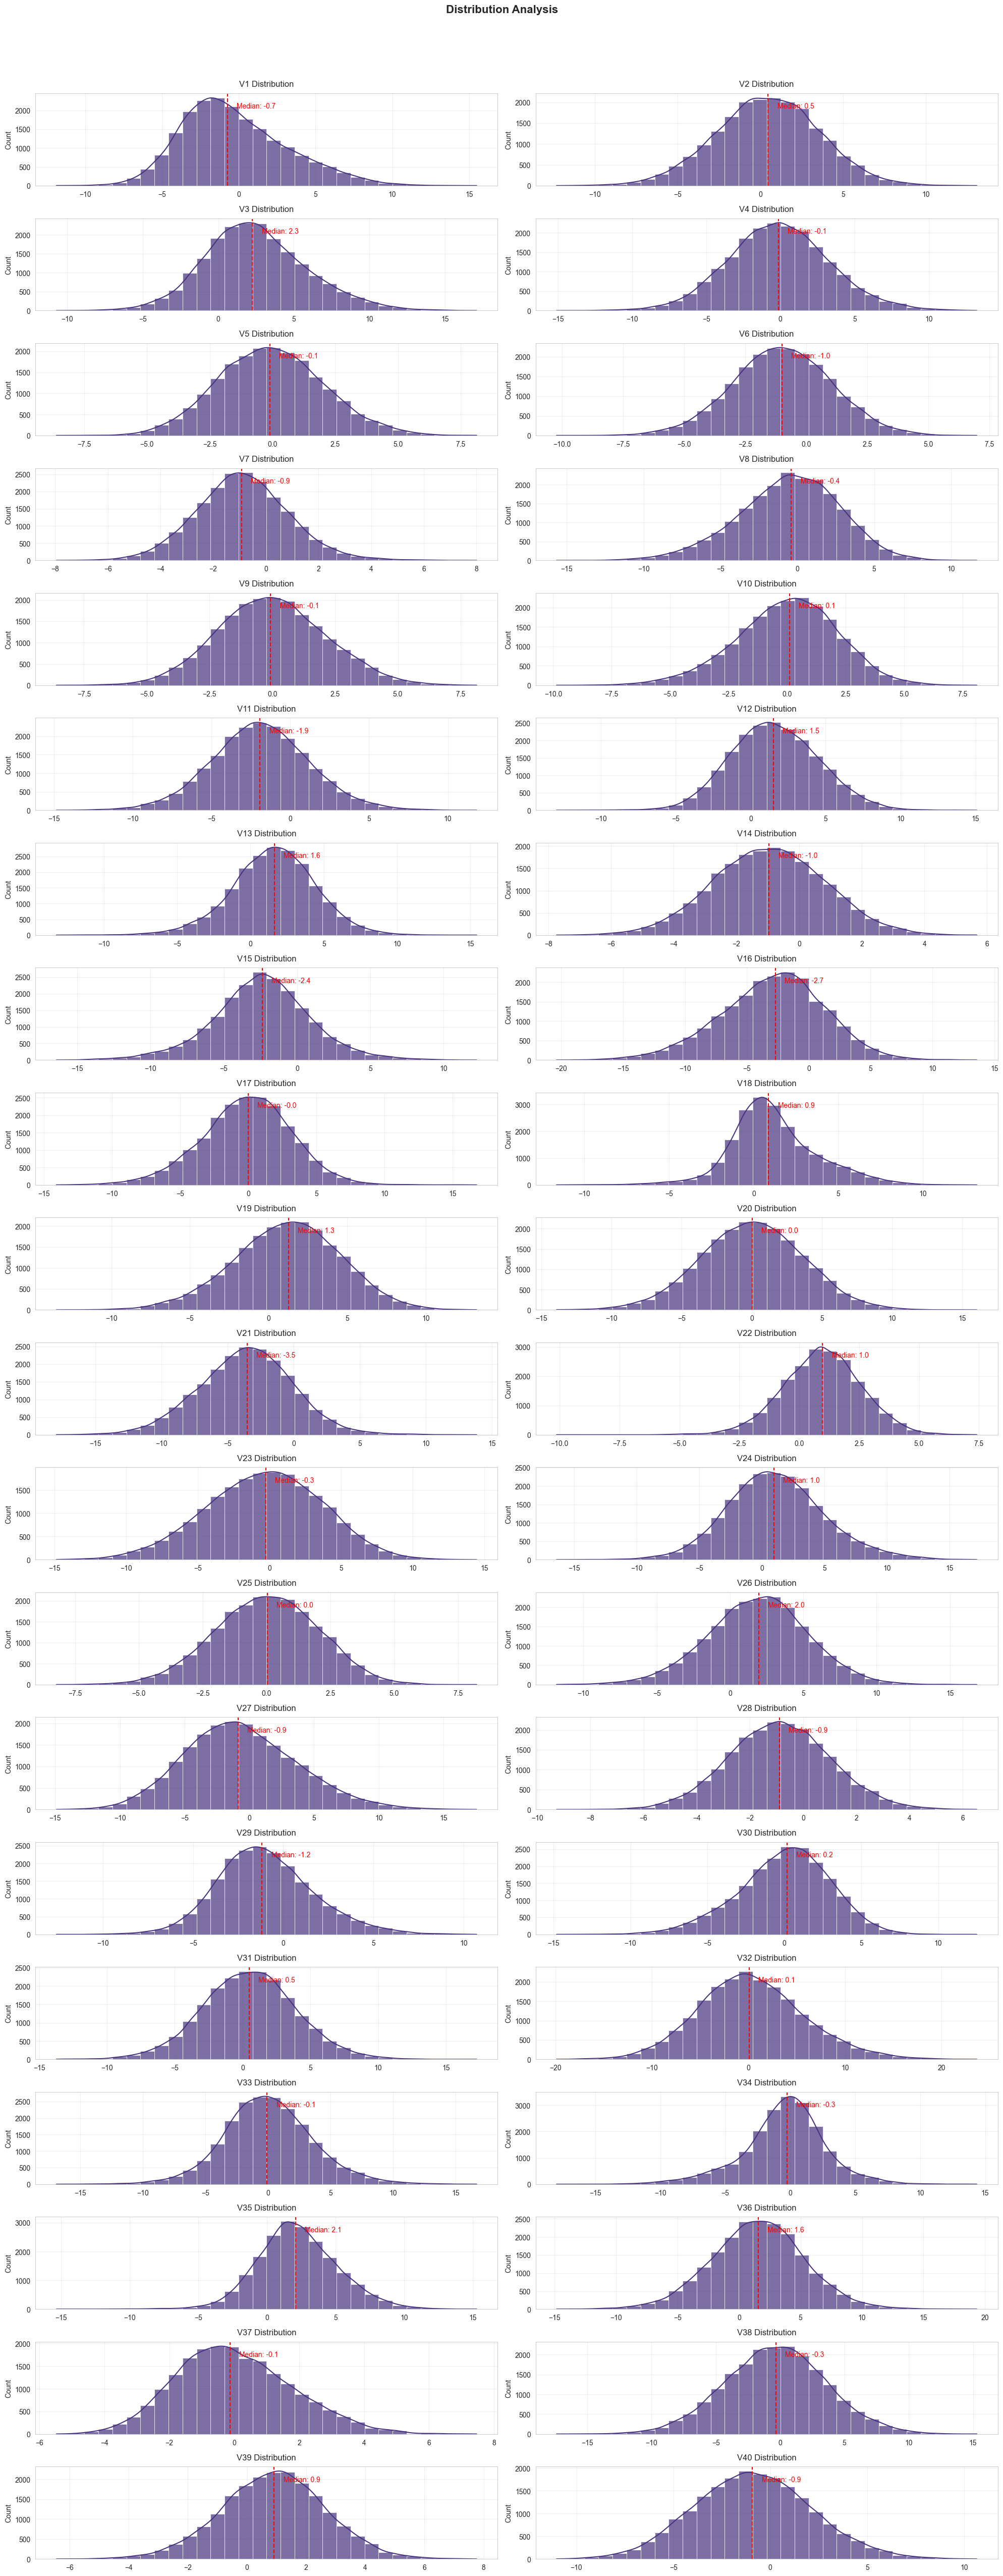

In [14]:
plot_numerical_distributions(df_train, df_train.columns[0:40],figsize=(20,50))

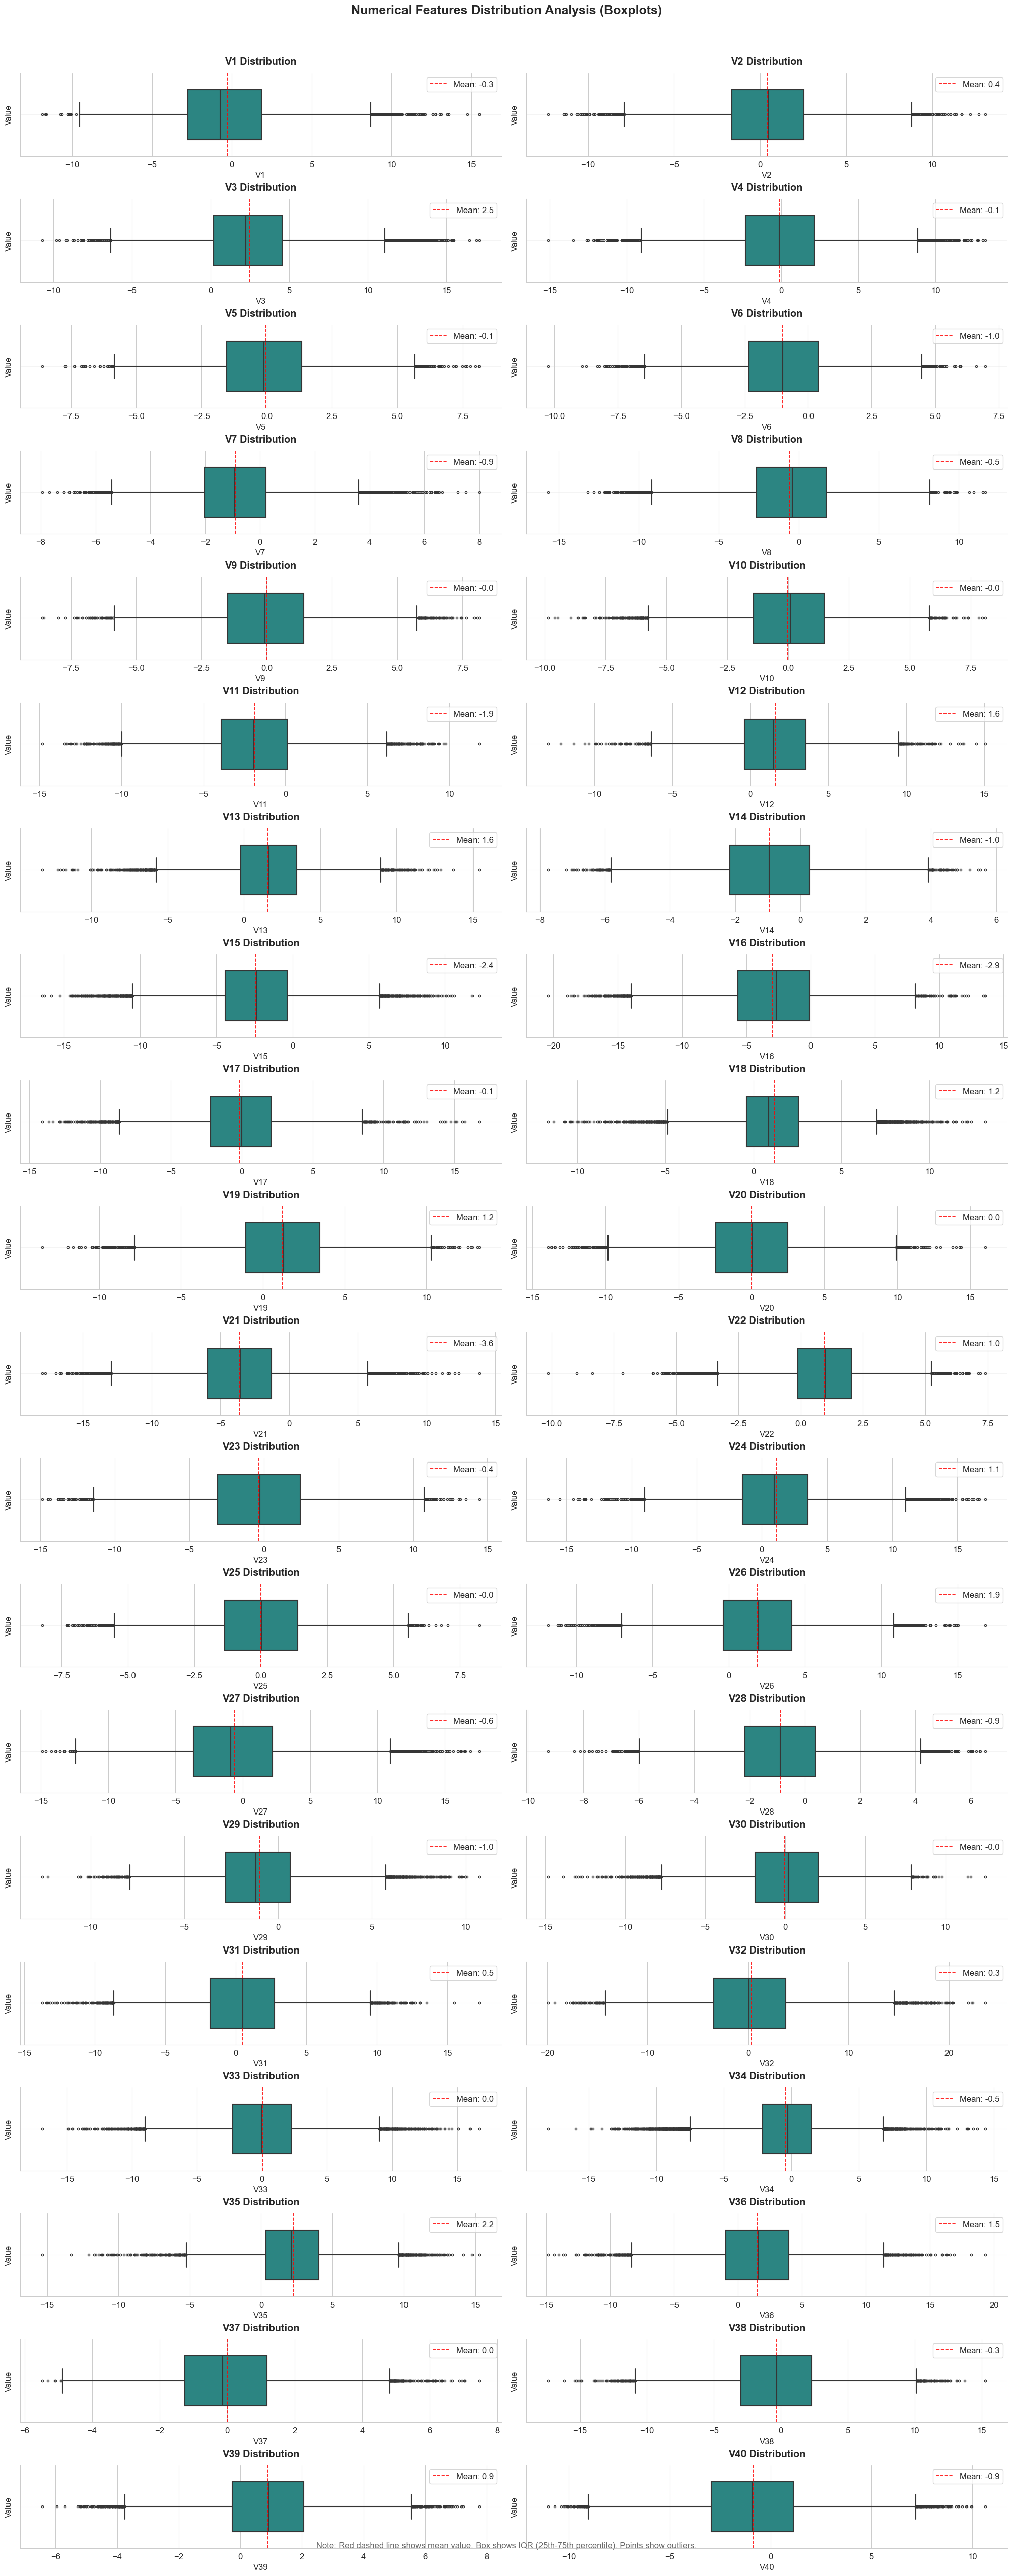

In [15]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    plot_numerical_boxplots(df_train, df_train.columns[0:40],figsize=(20,50))

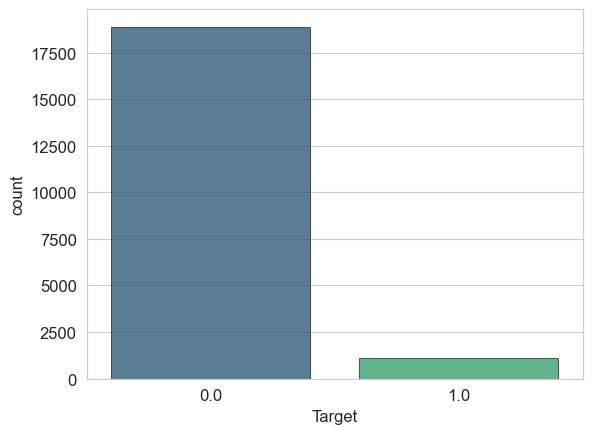

In [16]:
# Plot the target variable distribution
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sns.countplot(data=df_train, x="Target", palette="viridis", edgecolor='black', linewidth=0.5, alpha=0.85)

In [17]:
df_train["Target"].value_counts(normalize=True)

Target
0.0    0.9445
1.0    0.0555
Name: proportion, dtype: float64

### Univariate Analysis Observations
---
#### Features Distribution
- Eleven features have Right Skewness. These are V3, V4, V7, V9, V10, V14, V20, V26, V31, V36, and V38. These features have a peak on the left side and stretch towar higher values on the right. 
- Two features have left skewness. These are V19 and V27. 
- All the rest of features are fairly symmetric. Meaning that these features are more balanced. 

#### Data Ranges
Several features show different ranges and magnitudes:
- V1, has a wide distribution.
- V3, has high values in the far right.
- V9, has a large range.
- V14, has a long tail.
- V31 has a high numeric spread.
- V36 and V38 have a disproportionate tail length and outliers.  

#### Outliers
- From the Boxplots all the features present left and right outliers, they show long whiskers and numerous datapoints beyond the lower and uper quartile. 
- V3, V5, V16, V22, V33 and V36 are the features present extreme outliers. 

#### Target Variable
The countplot shows that the target variable is highly imbalanced. 
- Class 0 dominates with over 18,890 samples. (94%)
- Class 1 is rare with around 1,110 samples. (5.6%)

## Bivariate Analysis

### Features vs Target

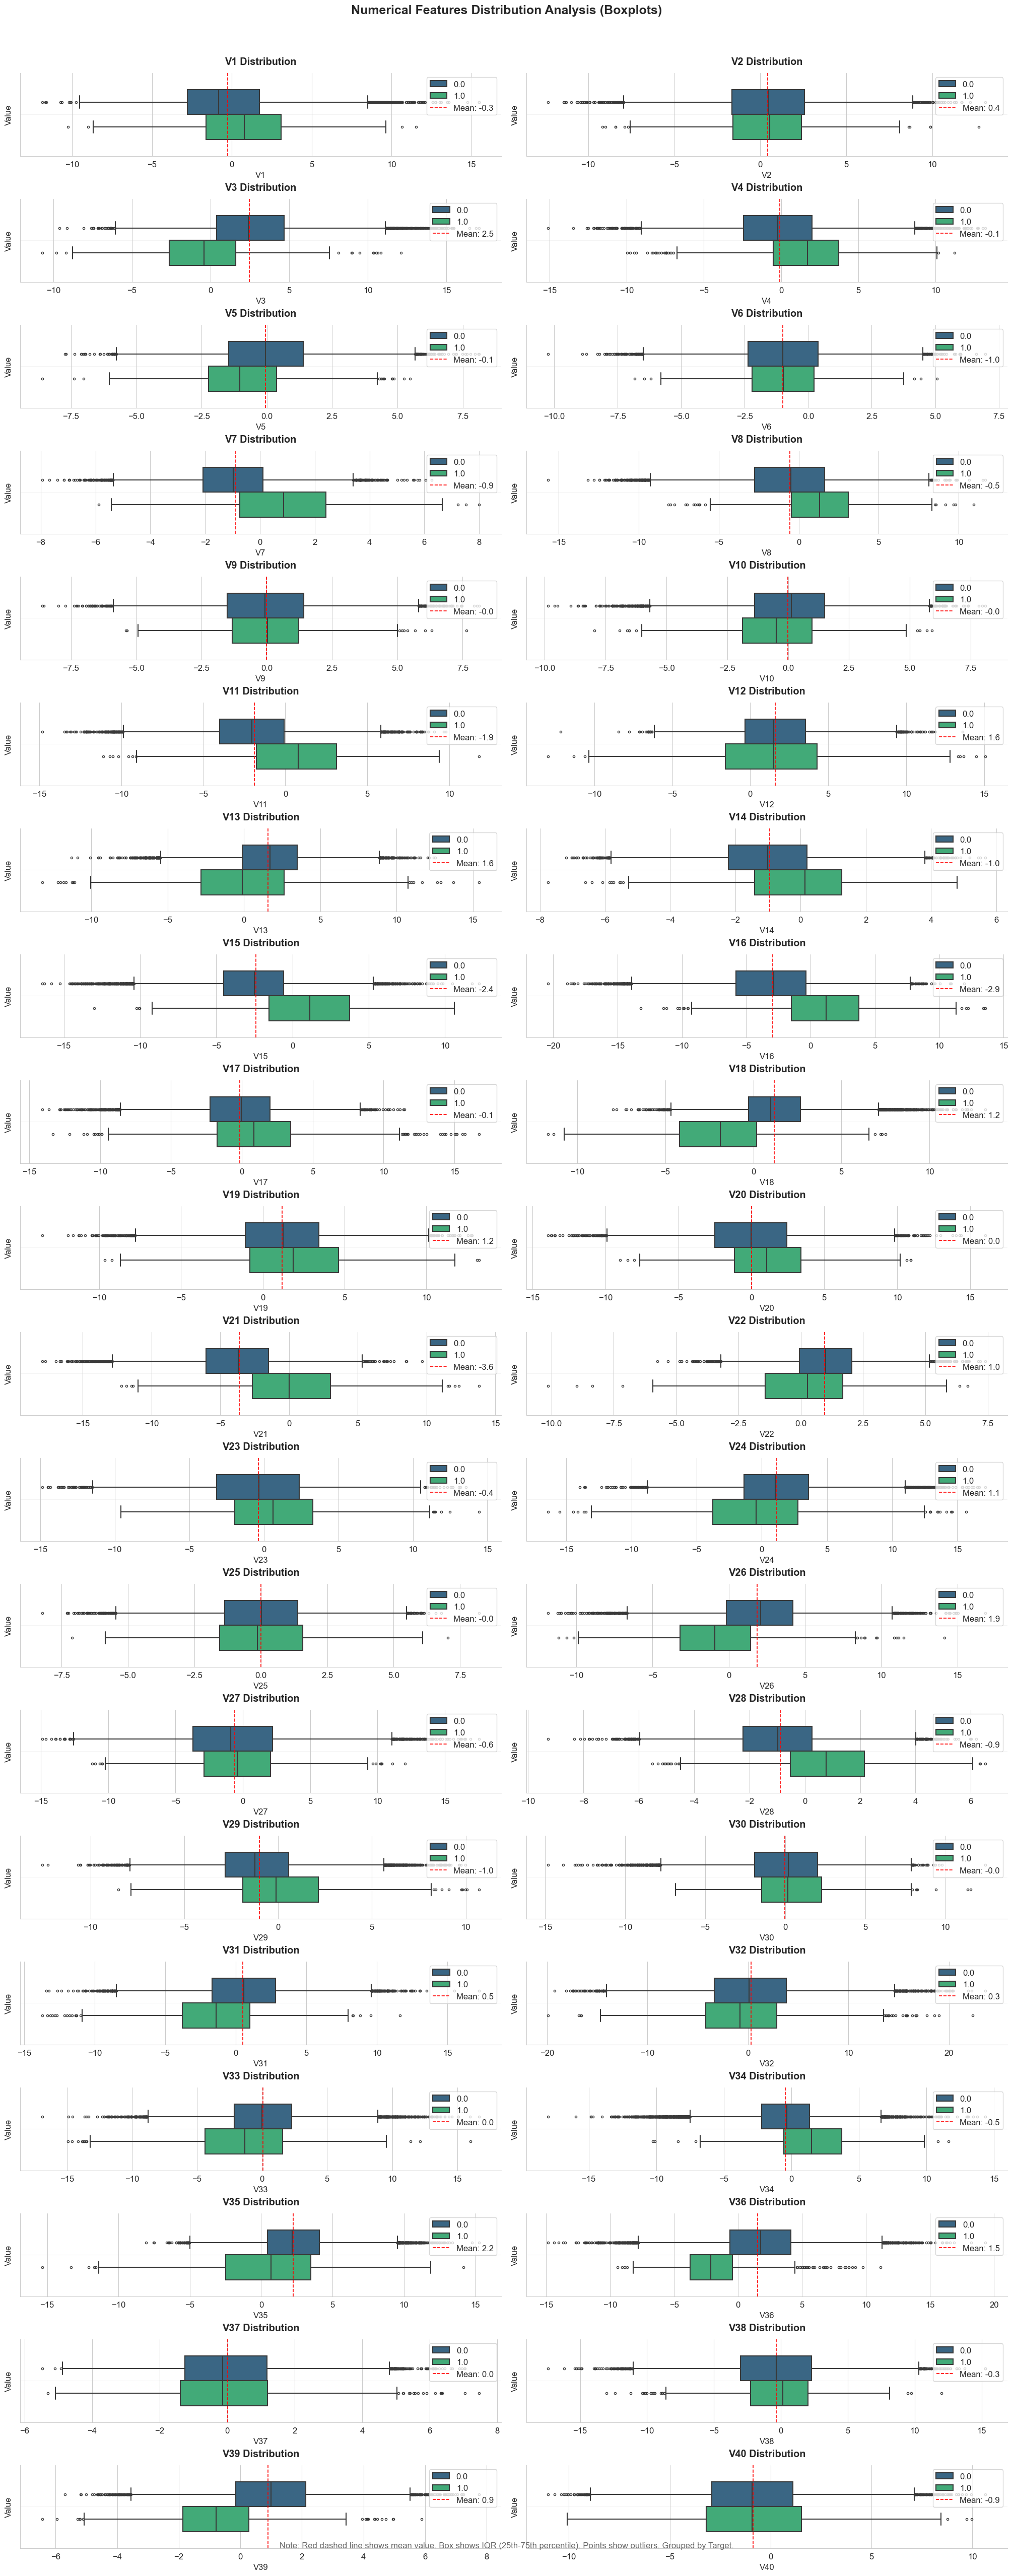

In [18]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    plot_numerical_boxplots(df_train, df_train.columns[0:40],figsize=(20,50), hue="Target")

### Bivariate Analysis Observations
---
#### Distribution Separation Between Target Classes
* Some features show a clear shift in their distributions between target classes. 
* This is notable in features: V3, V4, V5, V9, V13, V18, V26, V28, V35.
* This features suggest a predictive value for the models. 

#### Overlap but change in Skew
* Features V12, V14, V20 and V25 have overlapping medians but the tails differ with longer tails in failures. 

#### No distribution change between classes
* V1, V2, V6, V11 and V33 have minimal vhange between classes as the overal shape, median and IQR is very similiar. 
* This features might be irrelevant for prediction. 

### Correlation

In [19]:
# Generate the correlation Matrix
features = df_train.drop("Target", axis=1)
corr_matrix = features.corr(numeric_only=True)
corr_matrix

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40
V1,1.000000,0.313593,0.388855,-0.294832,-0.516085,0.175518,0.480694,-0.361016,0.398778,-0.022043,...,0.084862,-0.633279,-0.289917,-0.019433,0.142695,-0.124949,-0.350610,0.148316,-0.120898,0.212632
V2,0.313593,1.000000,0.095185,0.290202,0.383785,0.233949,0.455632,-0.383237,0.280601,-0.483879,...,-0.042449,-0.115820,0.203387,-0.281097,-0.054777,-0.580675,-0.437349,0.655368,-0.350539,0.155617
V3,0.388855,0.095185,1.000000,-0.028828,-0.359628,-0.291644,-0.156267,-0.412009,0.233626,0.446161,...,0.463729,-0.367431,-0.219509,0.225753,0.501409,0.438341,-0.502482,-0.073865,0.527742,-0.306190
V4,-0.294832,0.290202,-0.028828,1.000000,0.084185,-0.470199,-0.196909,0.034906,0.265154,-0.107058,...,-0.368177,0.383456,-0.052216,0.297496,0.340764,-0.557958,-0.356650,0.090986,-0.389080,-0.665310
V5,-0.516085,0.383785,-0.359628,0.084185,1.000000,0.156161,-0.078436,0.168267,-0.297635,-0.343741,...,0.301930,0.619779,0.458888,-0.607112,-0.341275,-0.045510,0.064515,0.171836,-0.217778,0.335332
V6,0.175518,0.233949,-0.291644,-0.470199,0.156161,1.000000,0.210914,-0.559084,0.084554,-0.116887,...,-0.115764,-0.292468,0.587371,-0.401306,-0.317068,-0.247402,-0.067280,0.628722,-0.025458,0.423882
V7,0.480694,0.455632,-0.156267,-0.196909,-0.078436,0.210914,1.000000,0.092713,-0.244421,-0.176849,...,-0.034001,-0.458844,-0.267082,0.232444,-0.438937,-0.280033,-0.007940,0.469057,-0.236700,0.479354
V8,-0.361016,-0.383237,-0.412009,0.034906,0.168267,-0.559084,0.092713,1.000000,-0.611735,-0.179856,...,0.149730,0.471798,-0.251002,0.054575,-0.167235,0.155913,0.522797,-0.614964,-0.344376,0.256984
V9,0.398778,0.280601,0.233626,0.265154,-0.297635,0.084554,-0.244421,-0.611735,1.000000,-0.293048,...,-0.458116,-0.369241,-0.137518,-0.102147,0.117301,-0.351657,-0.200198,0.038099,0.001001,-0.308607
V10,-0.022043,-0.483879,0.446161,-0.107058,-0.343741,-0.116887,-0.176849,-0.179856,-0.293048,1.000000,...,0.403991,-0.018839,-0.110081,0.514227,0.346129,0.561161,-0.403067,-0.007520,0.560471,-0.474803


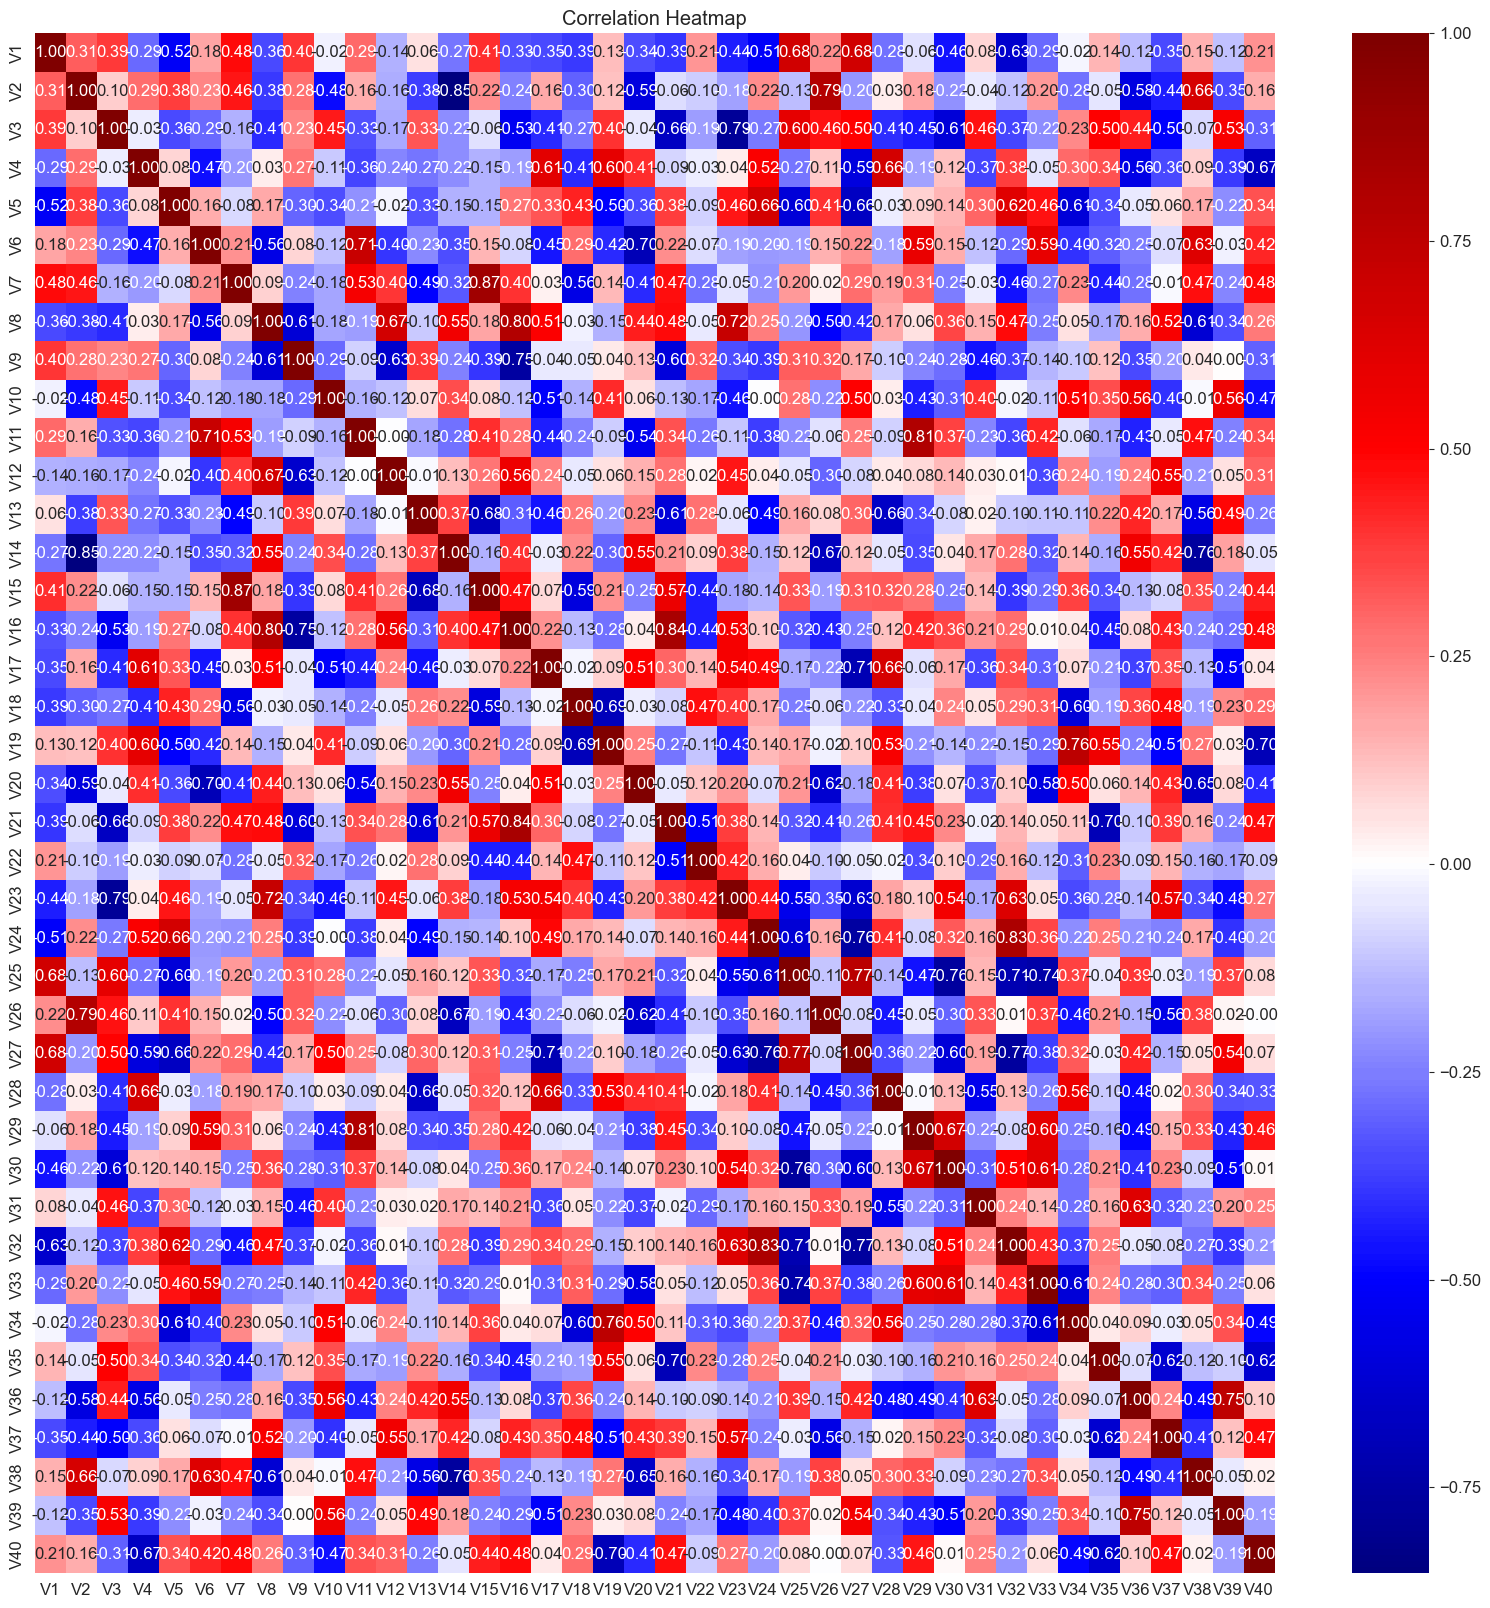

In [20]:
# Plot the correlation matrix
plt.figure(figsize=(20,20))
sns.heatmap(corr_matrix, annot=True, cmap="seismic", center=0, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

#### Observations:
- Here are some positevely correlated feature pairs.

| Feature 1 | Feature 2 | Correlation |
|-----------|-----------|-------------|
| V15       | V7        | 0.8679      |
| V36       | V39       | 0.7517      |
| V27       | V1        | 0.6838      |
| V26       | V2        | 0.7874      |
| V24       | V32       | 0.8251      |
| V23       | V8        | 0.7179      |
| V14       | V2        | -0.8535     |
| V31       | V36       | 0.6279      |
| V12       | V8        | 0.6740      |
| V38       | V2        | 0.6554      |
| V39       | V36       | 0.7517      |

- There are some negatively correlated feature pairs. 

| Feature 1 | Feature 2 | Correlation |
|-----------|-----------|-------------|
| V14       | V2        | -0.8535     |
| V20       | V6        | -0.6952     |
| V25       | V5        | -0.6025     |


# **5 - Data Preprocessing**

### Separate Features and Target

First step is to separate the Features from the Target in Train and Test dataset.

In [21]:
# Separate features and target variable for Train Dataset
X = df_train.drop("Target", axis=1)
y = df_train["Target"]
# Separate features and target variable for Test Dataset
X_test = df_test.drop("Target", axis=1)
y_test = df_test["Target"]

### Split Train and Validation

The second step is to create a validation dataset from the Train.csv data. The full dataset contains 25,000 samples, the Train data contains 20,000 datapoints and the Test data contains an aditional 5,000 datapoints. As the models will have to be tuned in order to optimize performance 25% of the train data will be used for validation. This will result in 15,000 samples for training, 5,000 for validation and 5,000 for testing. The split of train and validation will require a stratify strategy in order maintain the distribution of the target variable in the three datasets. 

In [22]:
# Split the Train Dataset into Train and Validation sets, using stratified sampling to maintain the distribution of the target variable
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=RS, stratify=y)

In [23]:
# Validate the size of each dataset
print(f"Train set shape: {X_train.shape}, Validation set shape: {X_val.shape}, Test set shape: {X_test.shape}")

Train set shape: (15000, 40), Validation set shape: (5000, 40), Test set shape: (5000, 40)


In [24]:
# Validate the distribution of the target variable in each dataset
print("Target variable distribution in Train, Validation, and Test sets:")
y_train.value_counts(normalize=True), y_val.value_counts(normalize=True), y_test.value_counts(normalize=True)

Target variable distribution in Train, Validation, and Test sets:


(Target
 0.0    0.944533
 1.0    0.055467
 Name: proportion, dtype: float64,
 Target
 0.0    0.9444
 1.0    0.0556
 Name: proportion, dtype: float64,
 Target
 0.0    0.9436
 1.0    0.0564
 Name: proportion, dtype: float64)

The three  datasets have almost the same class ditirbution, class 0 has a 0.944 proportion and class 1has a 0.055 propotion. 

### Missing Value Treatment

The third step will be to impute mising values. This is done after separating features and target variables, and most importantly after having the dataset splitted. This ensures that information from the validation or test sets does not influence the imputation process on the training set, thereby avoiding data leakage and preserving the integrity of our evaluation.

Given that the feature names are anonymized and provide no domain-specific context, complex imputation strategies are not applicable. Instead, a SimpleImputer is used for its transparency and reliability.

Exploratory Data Analysis revealed that the majority of features approximate a Gaussian distribution, though some exhibit right-tailed skewness. To account for this, the imputation strategy is set to use the median, as it is more robust to outliers and skewed data than the mean.

In [25]:
# Initialize the SimpleImputer to handle missing values, using the median strategy
imputer = SimpleImputer(strategy="median")
# Fit the imputer on the training data.
imputer.fit(X_train)
# Transform the training, validation, and test datasets to fill missing values
X_train = pd.DataFrame(imputer.transform(X_train), columns=X_train.columns)
X_val = pd.DataFrame(imputer.transform(X_val), columns=X_val.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

In [26]:
# Validate that there are no missing values in the datasets after imputation
print("Missing values after imputation:")
X_train.isnull().sum(), X_val.isnull().sum(), X_test.isnull().sum()

Missing values after imputation:


(V1     0
 V2     0
 V3     0
 V4     0
 V5     0
 V6     0
 V7     0
 V8     0
 V9     0
 V10    0
 V11    0
 V12    0
 V13    0
 V14    0
 V15    0
 V16    0
 V17    0
 V18    0
 V19    0
 V20    0
 V21    0
 V22    0
 V23    0
 V24    0
 V25    0
 V26    0
 V27    0
 V28    0
 V29    0
 V30    0
 V31    0
 V32    0
 V33    0
 V34    0
 V35    0
 V36    0
 V37    0
 V38    0
 V39    0
 V40    0
 dtype: int64,
 V1     0
 V2     0
 V3     0
 V4     0
 V5     0
 V6     0
 V7     0
 V8     0
 V9     0
 V10    0
 V11    0
 V12    0
 V13    0
 V14    0
 V15    0
 V16    0
 V17    0
 V18    0
 V19    0
 V20    0
 V21    0
 V22    0
 V23    0
 V24    0
 V25    0
 V26    0
 V27    0
 V28    0
 V29    0
 V30    0
 V31    0
 V32    0
 V33    0
 V34    0
 V35    0
 V36    0
 V37    0
 V38    0
 V39    0
 V40    0
 dtype: int64,
 V1     0
 V2     0
 V3     0
 V4     0
 V5     0
 V6     0
 V7     0
 V8     0
 V9     0
 V10    0
 V11    0
 V12    0
 V13    0
 V14    0
 V15    0
 V16    0
 V17    0


After the imputing method, there are no missing values in the three datasets.

### Convert Target to Numpy Arrays

The Neural Network will benefit with the target variable as numpy arrays. TensorFlow compatibility. 

In [27]:
# Convert the target variables to numpy arrays for compatibility with TensorFlow
y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()

# **6 - Model Building**

#### Utility Functions

In [28]:
def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    #fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name], color="darkorange") #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name], color="steelblue") #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    plt.legend(['Train', 'Validation'], loc="best") #Defining the legend, loc controls the position of the legend.

    

In [29]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(
    model, predictors, target, threshold=0.5, average='binary'
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors) > threshold
    # pred_temp = model.predict(predictors) > threshold
    # # rounding off the above values to get classes
    # pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average=average)  # to compute Recall
    precision = precision_score(target, pred, average=average)  # to compute Precision
    f1 = f1_score(target, pred, average=average)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,}, index = [0]
    )

    return df_perf

In [30]:
def model_logger(results_df, hidden_layers, neurons, activation_fn, epochs, batch_size,
                 optimizer, learning_rate, weight_init, regularization, history, elapsed_time, 
                 class_weight_strategy="imbalanced", callbacks_used="-"):
    """
    Appends a new row to the results DataFrame with hyperparameters and recall-based metrics.
    """

    if type(class_weight_strategy) is not str:
        formatted_weights = {k: round(v, 2) for k, v in class_weight_strategy.items()}
        class_weight_strategy = str(formatted_weights)

    row = {
        "# hidden layers": hidden_layers,
        "# neurons - hidden layer": neurons,
        "activation function - hidden layer": activation_fn,
        "# epochs": epochs,
        "batch size": batch_size,
        "optimizer": optimizer,
        "learning rate, momentum": learning_rate,
        "class weight strategy": class_weight_strategy,
        "weight initializer": weight_init,
        "regularization": regularization,
        "callbacks used": callbacks_used,
        "train loss": history.history["loss"][-1],
        "validation loss": history.history["val_loss"][-1],
        f"train recall": history.history.get("Recall", [None])[-1],
        f"validation recall": history.history.get("val_Recall", [None])[-1],
        "time (secs)": round(elapsed_time, 2)
    }

    return pd.concat([results_df, pd.DataFrame([row])], ignore_index=True)

In [31]:
def plot_confussion_matrix(model, predictors, target, title):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    # Predict the target values using the provided model and predictors
    y_pred = (model.predict(predictors).ravel() >= 0.5).astype(int)

    # Compute the confusion matrix comparing the true target values with the predicted values
    cm = confusion_matrix(target, y_pred)

    # Create labels for each cell in the confusion matrix with both count and percentage
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)    # reshaping to a matrix

    # Set the figure size for the plot
    #plt.figure(figsize=(6, 4))

    # Plot the confusion matrix as a heatmap with the labels
    sns.heatmap(cm, annot=labels, fmt="")

    # Add a label to the y-axis
    plt.ylabel("True label")

    # Add a label to the x-axis
    plt.xlabel("Predicted label")
    
    # Set the title of the plot
    plt.title(title, fontsize=16, fontweight='bold')

## Model Evaluation Criterion

The business requested a model that identifies failures in advance so that preventive actions—such as repairs—can be taken.
* A true positive (TP) indicates a correctly predicted failure, leading to a manageable repair.
* A false negative (FN) represents a failure that the model fails to detect—resulting in a full turbine breakdown, which is significantly more expensive to fix (replacement).
* A false positive (FP) results in a false alarm and triggers an inspection, which is less costly than either repair or replacement.

False negatives are the most costly outcome. Therefore, the model must be optimized to minimize false negatives, even if that leads to more false positives (inspections). This aligns directly with maximizing Recall. 

The model will be trained and evaluated to detect as many true failures as possible. Therefore Recall will be the metric used to evaluate the models.

## Initial Model Building (Model 0)

The base model will have a simple architecture and provide a baseline to optimize the model. 
The model architecture will start with:
* One hidden layer with 32 Neurons and ReLU activation.
* SGD will,be used as optimizer with Binary Cross-Entropy and Recall as metric. 
* The output layer will have one neuron and sigmoid activation. 

In the hidden layer 32 neurons was chosen in order to allow the network to begin abstracting interactions without an immediate increase in parameters. If the 
model underfitts then more neurons will be used in the next models.

As this is a binary classification model, the output layer will benefit from having one sinle neuron with sigmoid activation. Having more neurons will actually 
harm the model with redundancy and an increase in computation. 

The base model will start using SGD as optimizer in later models ADAM will be used and compared. Binary cross entropy is the natural loss for binary classification.


#### Set random seed
In order to have reproducibility the random seeds will be set before modeling. 

In [32]:
# Fix random seed for reproducibility
random.seed(RS)
np.random.seed(RS)
tf.random.set_seed(RS)

#### Set batch and epochs

* Batch Size is set to 128, as it is a power of 2. It will provide smother gradient estimates than smaller batches like 32 or 64. 
* Epoch is set to 75. Seems that this number of epochs will allow the model to learn. 

In [33]:
# Set batch size and number of epochs
batch_size = 128
epochs = 75

#### Model Logging

This dataframe will be used to save the model characteristics and Recall and Loss results. 

In [34]:
# Initialize the results DataFrame once
columns = [
    "# hidden layers", "# neurons - hidden layer", "activation function - hidden layer",
    "# epochs", "batch size", "optimizer","learning rate, momentum", "class weight strategy", "weight initializer", 
    "regularization", "callbacks used","train loss", "validation loss", "train recall", "validation recall", "time (secs)"
]

results = pd.DataFrame(columns=columns)
# Convert column dtypes if needed:
results = results.astype({
    "# hidden layers": "Int64",
    "# neurons - hidden layer": "object",
    "activation function - hidden layer": "object",
    "# epochs": "Int64",
    "batch size": "Int64",
    "optimizer": "object",
    "learning rate, momentum": "object",
    "class weight strategy": "object",
    "weight initializer": "object",
    "regularization": "object",
    "callbacks used": "object",
    "train loss": "float64",
    "validation loss": "float64",
    "train recall": "float64",
    "validation recall": "float64",
    "time (secs)": "float64"
})

In [35]:
# Clear any previous Keras session to avoid clutter
tf.keras.backend.clear_session()

In [36]:
# Define the model architecture
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(32, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

In [37]:
# Show the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345 (5.25 KB)

 Trainable params: 1,345 (5.25 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Define the optimizer
optimizer = tf.keras.optimizers.SGD()
# Compile the model with the optimizer, loss function, and metrics
model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["Recall"])

In [39]:
# Model Fitting
start = time.time()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
)
end = time.time()

Epoch 1/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.1064 - loss: 0.4634 - val_Recall: 0.3094 - val_loss: 0.1509
Epoch 2/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - Recall: 0.3026 - loss: 0.1377 - val_Recall: 0.4748 - val_loss: 0.1237
Epoch 3/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - Recall: 0.4257 - loss: 0.1129 - val_Recall: 0.5360 - val_loss: 0.1102
Epoch 4/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - Recall: 0.5115 - loss: 0.0995 - val_Recall: 0.5791 - val_loss: 0.1019
Epoch 5/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - Recall: 0.5772 - loss: 0.0910 - val_Recall: 0.6331 - val_loss: 0.0963
Epoch 6/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - Recall: 0.6135 - loss: 0.0852 - val_Recall: 0.6691 - val_loss: 0.0924
Epoch 7/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - Recall: 0.6551 - loss: 0.0809 - val_Recall: 0.6835 - val_loss: 0.0896
Epoch 8/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.6773 - loss: 0.0777 - val_Recall: 0.6906 - val_loss: 0.0874
Epoch 9/

In [40]:
print(f"Training time: {end - start:.2f} seconds")

Training time: 17.08 seconds


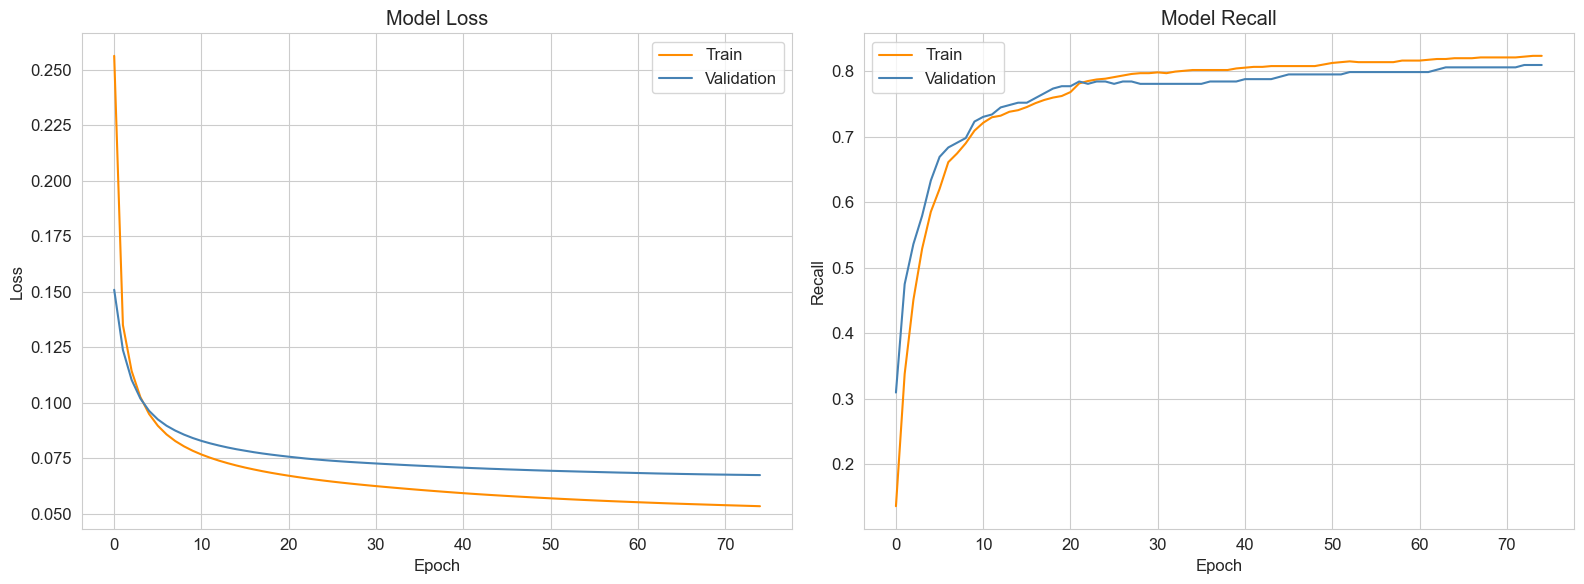

In [41]:
# Plot Loss and Recall
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot(history, "loss")
plt.sca(ax2)
plot(history, "Recall")
plt.tight_layout()
plt.show()

#### Observations:
* For the Model Loss, both curves (train and validation) deacrease steadily. Validation loss is above the training loss which suggest that the model has generalization. 
* Recall improves after epoch 20 scoring above 0.75 in Recall. Validation is very close to training scores. 

In [42]:
# Log the model
results = model_logger(results, hidden_layers=1, neurons=32, activation_fn="relu",
                        epochs=epochs, batch_size=batch_size, optimizer="SGD", learning_rate=[0.001, "-"], class_weight_strategy="imbalanced",
                        weight_init="xavier",
                        regularization="-",history=history, elapsed_time=end - start)
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",class weight strategy,weight initializer,regularization,callbacks used,train loss,validation loss,train recall,validation recall,time (secs)
0,1,32,relu,75,128,SGD,"[0.001, -]",imbalanced,xavier,-,-,0.053337,0.067357,0.823317,0.809353,17.08


In [43]:
# Evaluate the model on the train set
model_train_perf = model_performance_classification(model, X_train, y_train)
model_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 715us/step


,Accuracy,Recall,Precision,F1 Score
0,0.989133,0.825721,0.974468,0.893949


In [44]:
# Evaluate the model on the validation set
model_val_perf = model_performance_classification(model,X_val,y_val)
model_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 813us/step


,Accuracy,Recall,Precision,F1 Score
0,0.9884,0.809353,0.978261,0.885827


In [45]:
# Classification Report for Train Data
y_train_pred = model.predict(X_train)
print("Classification Report - Train data Model_0",end="\n\n")
cr_train_model_0 = classification_report(y_train,y_train_pred>0.5)
print(cr_train_model_0)

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 507us/step
Classification Report - Train data Model_0

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     14168
         1.0       0.97      0.83      0.89       832

    accuracy                           0.99     15000
   macro avg       0.98      0.91      0.94     15000
weighted avg       0.99      0.99      0.99     15000



In [46]:
# Classification Report for Validation Data
y_val_pred = model.predict(X_val)
print("Classification Report - Validation data Model_0",end="\n\n")
cr_val_model_0 = classification_report(y_val,y_val_pred>0.5)
print(cr_val_model_0)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step
Classification Report - Validation data Model_0

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      4722
         1.0       0.98      0.81      0.89       278

    accuracy                           0.99      5000
   macro avg       0.98      0.90      0.94      5000
weighted avg       0.99      0.99      0.99      5000



469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 495us/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 605us/step


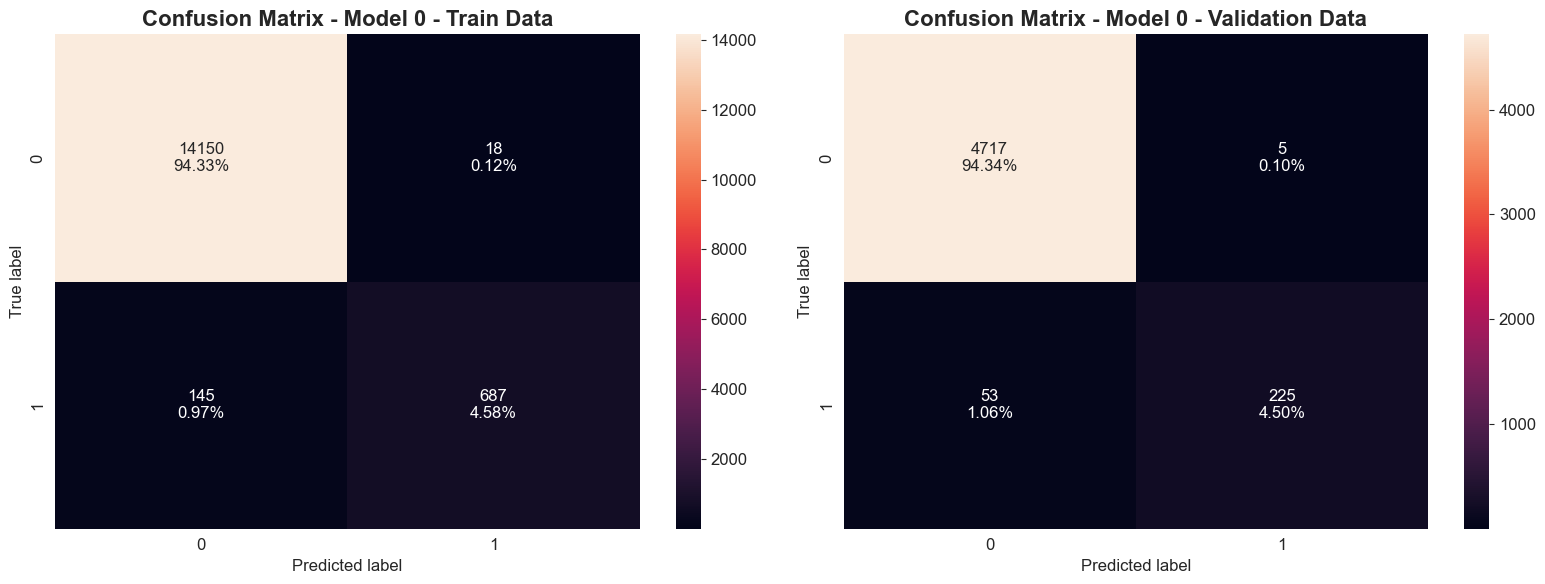

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot_confussion_matrix(model, X_train, y_train, "Confusion Matrix - Model 0 - Train Data")
plt.sca(ax2)
plot_confussion_matrix(model, X_val, y_val, "Confusion Matrix - Model 0 - Validation Data")
plt.tight_layout()
plt.show()


Observations:
- The baseline model has an 0.82 Recall Score in training and 0.80 in validation. 
- The classification report indicates that the model has 0.83 Recall Score for Class 1 in training and 0.81 in validation. 
- The confusion matrix shows that the model can be improved predicting False Negatives. 
- These is a good baseline model and from here the model will be tuned. 

# **Model Performance Improvement**

## Model 1

Model 1 will have a more complex architecture than the base model. The idea will be to optimize the model and to be able to predit False Negatives (failures) better. 
* Two hidden layer with 64 and 32 Neurons and ReLU activation.
* SGD with a smaller learning rate of 0.0001 and momentum of 0.9 will be used as optimizer with Binary Cross-Entropy and Recall as metric. 
* The output layer will have one neuron and sigmoid activation. 

In [48]:
# Clear any previous Keras session to avoid clutter
tf.keras.backend.clear_session()

In [49]:
# Model 1: Adding more complexity with additional layers and neurons
model_1 = Sequential()
model_1.add(Input(shape=(X_train.shape[1],)))
model_1.add(Dense(64, activation="relu"))
model_1.add(Dense(32, activation="relu"))
model_1.add(Dense(1, activation="sigmoid"))

In [50]:
# Model summary
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# Set the learning rate and momentum
learning_rate = 0.0001
momentum = 0.9

In [52]:
# Define the optimizer with momentum and learning rate
optimizer = tf.keras.optimizers.SGD(momentum=momentum, learning_rate=learning_rate)
# Compile the model with the optimizer, loss function, and metrics
model_1.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["Recall"])

In [53]:
# Fit the model
start = time.time()
history_1 = model_1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
)
end = time.time()

Epoch 1/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.7927 - loss: 1.1524 - val_Recall: 0.3849 - val_loss: 0.2476
Epoch 2/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.3720 - loss: 0.2328 - val_Recall: 0.2950 - val_loss: 0.1900
Epoch 3/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.2799 - loss: 0.1895 - val_Recall: 0.2842 - val_loss: 0.1728
Epoch 4/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.2704 - loss: 0.1739 - val_Recall: 0.2842 - val_loss: 0.1636
Epoch 5/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.2720 - loss: 0.1647 - val_Recall: 0.2914 - val_loss: 0.1572
Epoch 6/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.2875 - loss: 0.1580 - val_Recall: 0.3094 - val_loss: 0.1522
Epoch 7/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.3033 - loss: 0.1526 - val_Recall: 0.3237 - val_loss: 0.1480
Epoch 8/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.3194 - loss: 0.1480 - val_Recall: 0.3309 - val_loss: 0.1444
Epoch 9/

In [54]:
print(f"Training time: {end - start:.2f} seconds")

Training time: 17.14 seconds


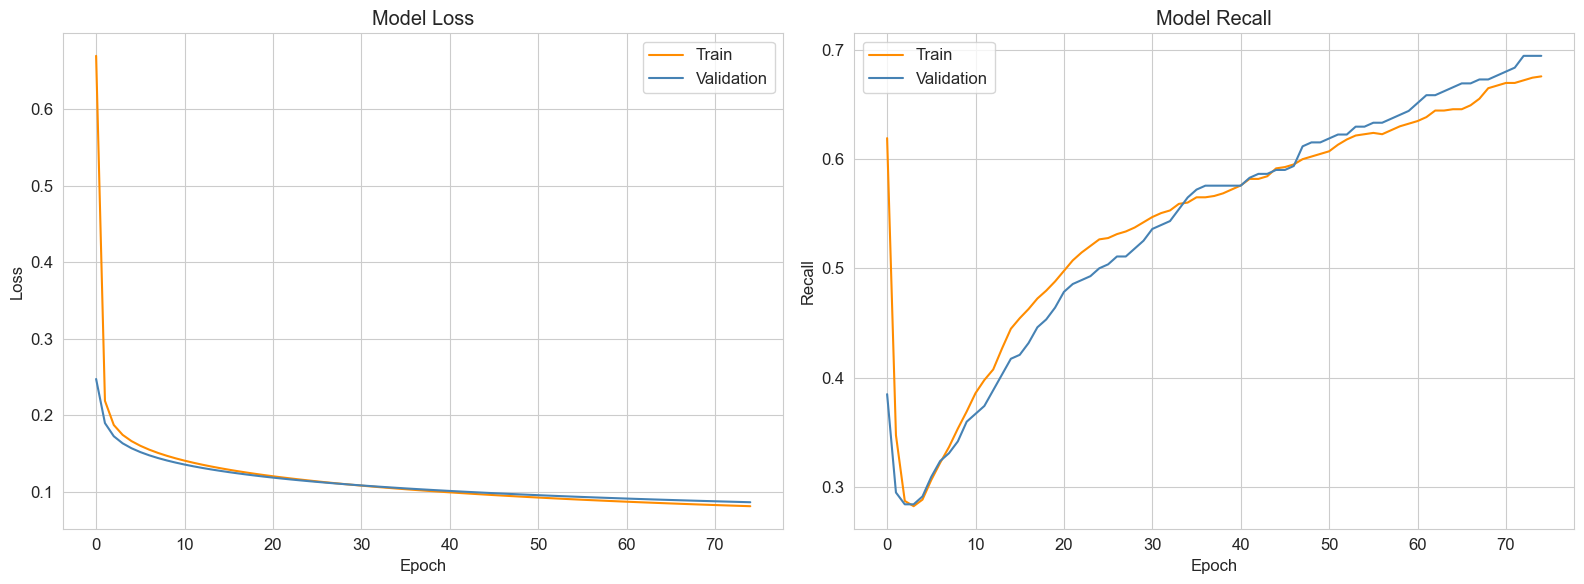

In [55]:
# Plot Loss and Recall for Model 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot(history_1, "loss")
plt.sca(ax2)
plot(history_1, "Recall")
plt.tight_layout()
plt.show()

#### Observations:
* Both training and validation loss decrease and the gap between training and validation is small. 
* The recall scores there is a sharp dip and then it recovers. But scores are much lower than the base model. 

In [56]:
results = model_logger(results, hidden_layers=2, neurons=[64, 32], activation_fn=["relu", "relu"],
                        epochs=epochs, batch_size=batch_size, optimizer="SGD", learning_rate=[learning_rate, momentum], 
                        weight_init=["xavier", "xavier"], regularization="-", history=history_1, elapsed_time=end - start)
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",class weight strategy,weight initializer,regularization,callbacks used,train loss,validation loss,train recall,validation recall,time (secs)
0,1,32,relu,75,128,SGD,"[0.001, -]",imbalanced,xavier,-,-,0.053337,0.067357,0.823317,0.809353,17.08
1,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.0001, 0.9]",imbalanced,"[xavier, xavier]",-,-,0.081540,0.086714,0.675481,0.694245,17.14


In [57]:
# Evaluate the model on the train set for Model 1
model_1_train_perf = model_performance_classification(model_1, X_train, y_train)
model_1_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 521us/step


,Accuracy,Recall,Precision,F1 Score
0,0.980267,0.676683,0.954237,0.791842


In [58]:
# Evaluate the model on the validation set for Model 1
model_1_val_perf = model_performance_classification(model_1, X_val, y_val)
model_1_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 527us/step


,Accuracy,Recall,Precision,F1 Score
0,0.9814,0.694245,0.960199,0.805846


In [59]:
# Classification Report for Train Data - Model 1
y_train_pred_1 = model_1.predict(X_train)
print("Classification Report - Train - Model 1",end="\n\n")
cr_train_model_1 = classification_report(y_train,y_train_pred_1>0.5)
print(cr_train_model_1)

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 469us/step
Classification Report - Train - Model 1

              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99     14168
         1.0       0.95      0.68      0.79       832

    accuracy                           0.98     15000
   macro avg       0.97      0.84      0.89     15000
weighted avg       0.98      0.98      0.98     15000



In [60]:
# Classification Report for Validation Data - Model 1
y_val_pred_1 = model_1.predict(X_val)
print("Classification Report - Validation - Model 1",end="\n\n")
cr_val_model_1 = classification_report(y_val,y_val_pred_1>0.5)
print(cr_val_model_1)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step
Classification Report - Validation - Model 1

              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      4722
         1.0       0.96      0.69      0.81       278

    accuracy                           0.98      5000
   macro avg       0.97      0.85      0.90      5000
weighted avg       0.98      0.98      0.98      5000



469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 471us/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 527us/step


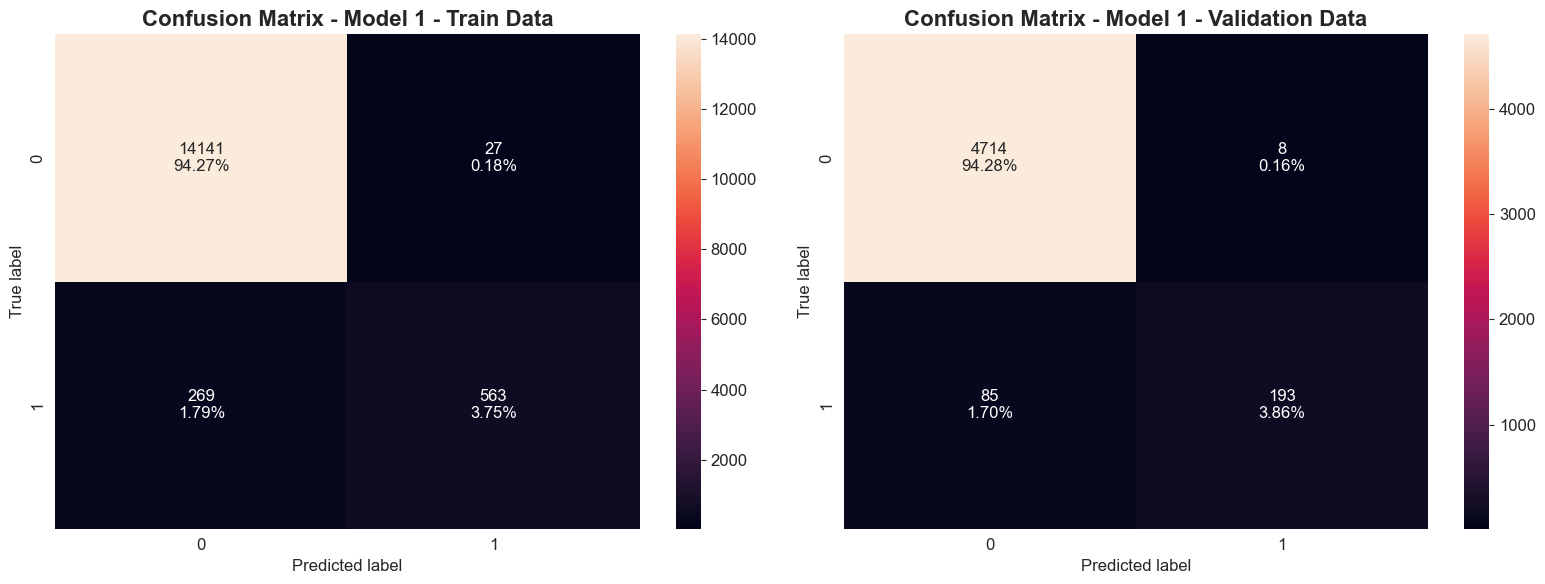

In [61]:
# Plot Confusion Matrices for Model 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot_confussion_matrix(model_1, X_train, y_train, "Confusion Matrix - Model 1 - Train Data")
plt.sca(ax2)
plot_confussion_matrix(model_1, X_val, y_val, "Confusion Matrix - Model 1 - Validation Data")
plt.tight_layout()
plt.show()

#### Observation:
* Model 1 presented lower recall scores than the base model. There are more False negatives in the confusion matrices. 
* Probably the momentum of 0.9 is to high. 
* Next model will use a lower mementum and then compare. 


## Model 2

Model 2 will have the same architecture as Model 1. This model will test a lower momentum for the SGD optimizer. 

In [62]:
# Clear any previous Keras session to avoid clutter
tf.keras.backend.clear_session()

In [63]:
# Model 2: Same architecture as Model 1.
model_2 = Sequential()
model_2.add(Input(shape=(X_train.shape[1],)))
model_2.add(Dense(64, activation="relu"))
model_2.add(Dense(32, activation="relu"))
model_2.add(Dense(1, activation="sigmoid"))

In [64]:
# Model summary
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
# Set the learning rate and momentum for Model 2
learning_rate = 0.0001
momentum = 0.4

In [66]:
# Define the optimizer with momentum and learning rate for Model 2
optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=momentum)
# Compile the model with the optimizer, loss function, and metrics for Model 2
model_2.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["Recall"])

In [67]:
# Fit the model for Model 2
start = time.time()
history_2 = model_2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
)
end = time.time()

Epoch 1/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.1281 - loss: 0.3942 - val_Recall: 0.1223 - val_loss: 0.3567
Epoch 2/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.1023 - loss: 0.3403 - val_Recall: 0.1007 - val_loss: 0.3209
Epoch 3/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.0880 - loss: 0.3097 - val_Recall: 0.0863 - val_loss: 0.2990
Epoch 4/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.0725 - loss: 0.2905 - val_Recall: 0.0863 - val_loss: 0.2842
Epoch 5/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.0635 - loss: 0.2773 - val_Recall: 0.0863 - val_loss: 0.2734
Epoch 6/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.0626 - loss: 0.2675 - val_Recall: 0.0827 - val_loss: 0.2649
Epoch 7/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.0612 - loss: 0.2597 - val_Recall: 0.0791 - val_loss: 0.2580
Epoch 8/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.0598 - loss: 0.2532 - val_Recall: 0.0791 - val_loss: 0.2521
Epoch 9/

In [68]:
print(f"Training time: {end - start:.2f} seconds")

Training time: 15.93 seconds


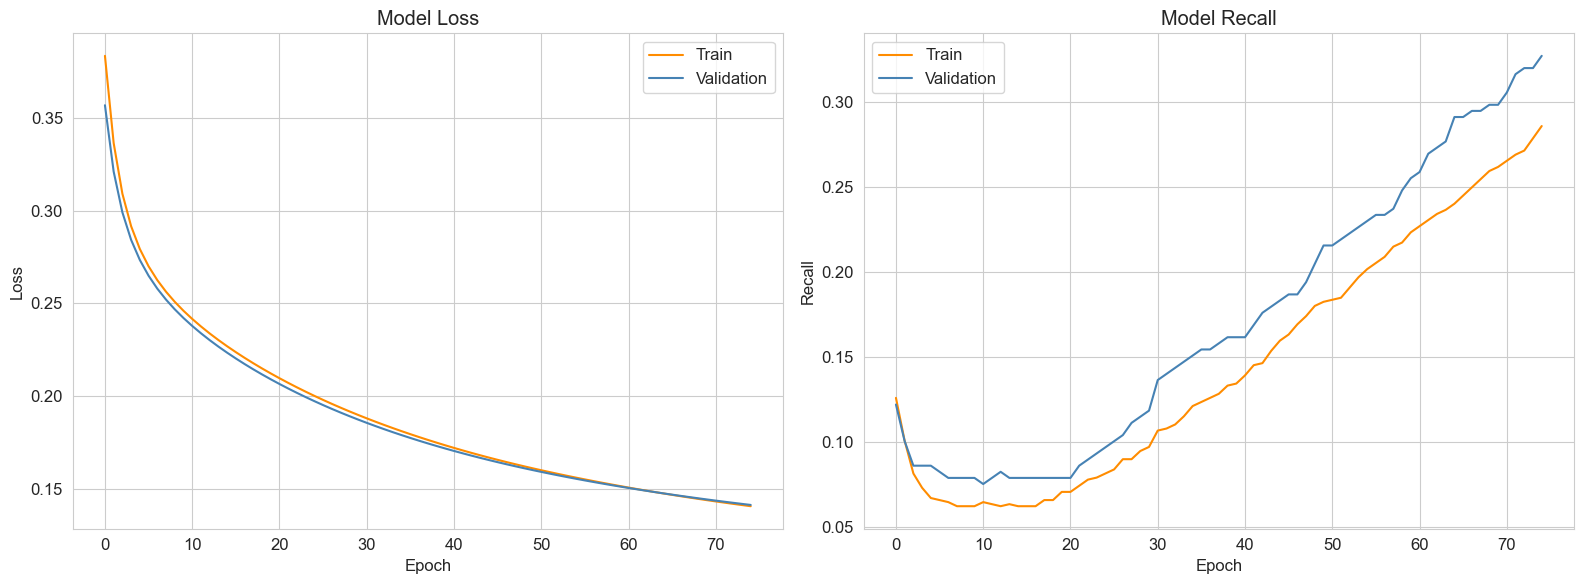

In [69]:
# Plot Loss and Recall for Model 2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot(history_2, "loss")
plt.sca(ax2)
plot(history_2, "Recall")
plt.tight_layout()
plt.show()

#### Observation:
* The loss decreases more gradually compared to Model 1. The lower momentum is not helping the model. The downward trayectory is very slight, it is not as steep as with the base model or model 1. 
* Recall scores are much worse than in model 1. The model gets stuck between 0.30 and 0.35

In [70]:
results = model_logger(results, hidden_layers=2, neurons=[64, 32], activation_fn=["relu", "relu"],
                        epochs=epochs, batch_size=batch_size, optimizer="SGD", learning_rate=[learning_rate, momentum], 
                        weight_init=["xavier", "xavier"], regularization="-", history=history_2, elapsed_time=end - start)
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",class weight strategy,weight initializer,regularization,callbacks used,train loss,validation loss,train recall,validation recall,time (secs)
0,1,32,relu,75,128,SGD,"[0.001, -]",imbalanced,xavier,-,-,0.053337,0.067357,0.823317,0.809353,17.08
1,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.0001, 0.9]",imbalanced,"[xavier, xavier]",-,-,0.081540,0.086714,0.675481,0.694245,17.14
2,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.0001, 0.4]",imbalanced,"[xavier, xavier]",-,-,0.140907,0.141586,0.286058,0.327338,15.93


In [71]:
# Evaluate the model on the train set for Model 2
model_2_train_perf = model_performance_classification(model_2, X_train, y_train)
model_2_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step


,Accuracy,Recall,Precision,F1 Score
0,0.958333,0.28726,0.881919,0.433364


In [72]:
# Evaluate the model on the validation set for Model 2
model_2_val_perf = model_performance_classification(model_2, X_val, y_val)
model_2_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 545us/step


,Accuracy,Recall,Precision,F1 Score
0,0.96,0.327338,0.875,0.47644


In [73]:
# Classification Report for Train Data - Model 2
y_train_pred_2 = model_2.predict(X_train)
print("Classification Report - Train - Model 2",end="\n\n")
cr_train_model_2 = classification_report(y_train,y_train_pred_1>0.5)
print(cr_train_model_2)

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 470us/step
Classification Report - Train - Model 2

              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99     14168
         1.0       0.95      0.68      0.79       832

    accuracy                           0.98     15000
   macro avg       0.97      0.84      0.89     15000
weighted avg       0.98      0.98      0.98     15000



In [74]:
# Classification Report for Validation Data - Model 2
y_val_pred_2 = model_2.predict(X_val)
print("Classification Report - Validation - Model 2",end="\n\n")
cr_val_model_2 = classification_report(y_val,y_val_pred_1>0.5)
print(cr_val_model_2)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step
Classification Report - Validation - Model 2

              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      4722
         1.0       0.96      0.69      0.81       278

    accuracy                           0.98      5000
   macro avg       0.97      0.85      0.90      5000
weighted avg       0.98      0.98      0.98      5000



469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 474us/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step


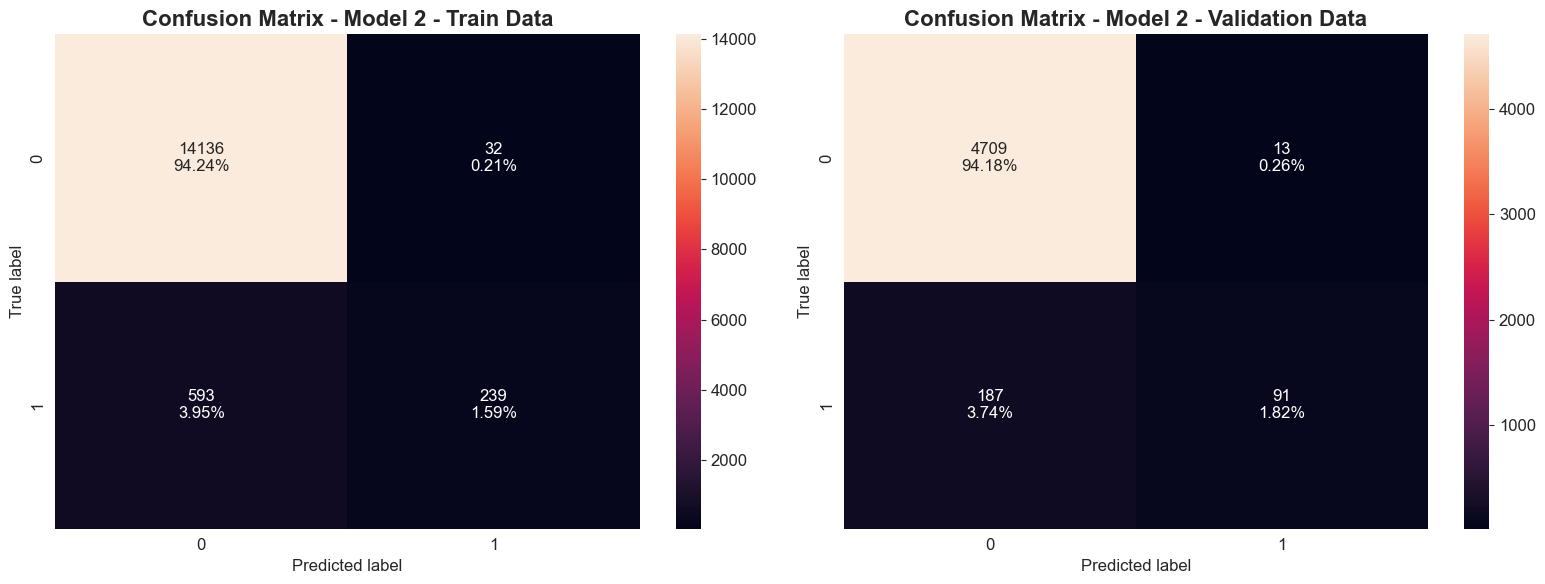

In [75]:
# Plot Confusion Matrices for Model 2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot_confussion_matrix(model_2, X_train, y_train, "Confusion Matrix - Model 2 - Train Data")
plt.sca(ax2)
plot_confussion_matrix(model_2, X_val, y_val, "Confusion Matrix - Model 2 - Validation Data")
plt.tight_layout()
plt.show()

#### Observation:
- Model 2 is performing worst than model 1. Recall scores are 0.28 for training and 0.32 for validation. 
- The confusion matrix shows that there is an increase in false negatives. 
- Next model will try to increase the learning rate with momentum. In order to determine if it was the momentum or the decrease in learning rate. 

## Model 3

This model will keep the same architecture as Model 1 and Model 2. SGD will continue to be the optimizer and this model will increase the learning rate to 0.001 and momentum of 0.9, the idea is to see if an increase in learning rate can help to get back to the results obtaines in the base model. 

In [76]:
# Clear any previous Keras session to avoid clutter
tf.keras.backend.clear_session()

In [77]:
# Model 3: Keeping the architecture same as Model 2 and Model 1. 
model_3 = Sequential()
model_3.add(Input(shape=(X_train.shape[1],)))
model_3.add(Dense(64, activation="relu"))
model_3.add(Dense(32, activation="relu"))
model_3.add(Dense(1, activation="sigmoid"))

In [78]:
# Model summary
model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
# Set the learning rate and momentum for Model 3
learning_rate = 0.001
momentum = 0.9

In [80]:
# Define the optimizer with momentum and learning rate for Model 3
optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=momentum)
# Compile the model with the optimizer, loss function, and metrics for Model 3
model_3.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["Recall"])

In [81]:
# Fit the model for Model 3
start = time.time()
history_3 = model_3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
)
end = time.time()

Epoch 1/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.1157 - loss: 0.3743 - val_Recall: 0.3022 - val_loss: 0.1505
Epoch 2/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.3447 - loss: 0.1308 - val_Recall: 0.4568 - val_loss: 0.1265
Epoch 3/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.4837 - loss: 0.1095 - val_Recall: 0.5432 - val_loss: 0.1136
Epoch 4/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.5481 - loss: 0.0973 - val_Recall: 0.5719 - val_loss: 0.1051
Epoch 5/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.6082 - loss: 0.0891 - val_Recall: 0.6367 - val_loss: 0.0990
Epoch 6/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.6498 - loss: 0.0832 - val_Recall: 0.6727 - val_loss: 0.0943
Epoch 7/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.6781 - loss: 0.0785 - val_Recall: 0.6978 - val_loss: 0.0904
Epoch 8/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.6960 - loss: 0.0747 - val_Recall: 0.7158 - val_loss: 0.0872
Epoch 9/

In [82]:
print(f"Training time: {end - start:.2f} seconds")

Training time: 16.13 seconds


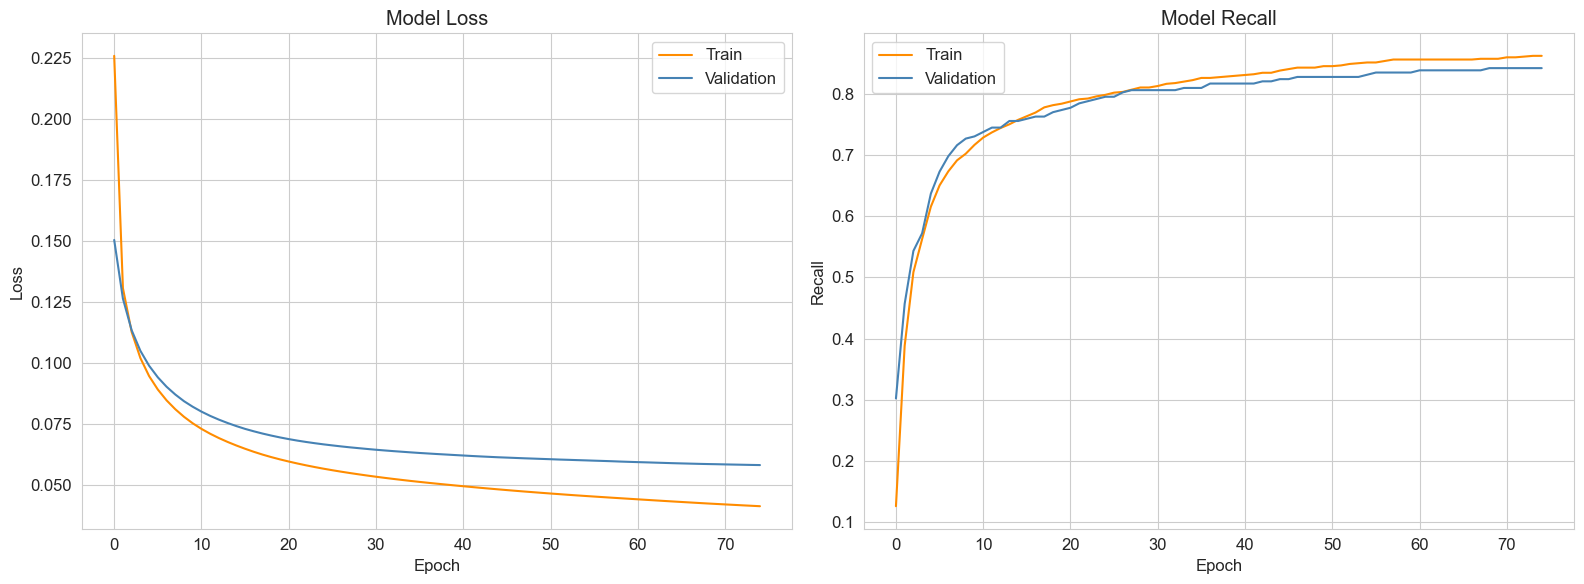

In [83]:
# Plot Loss and Recall for Model 3
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot(history_3, "loss")
plt.sca(ax2)
plot(history_3, "Recall")
plt.tight_layout()
plt.show()

#### Observations:
* The loss drops much faster than in Models 1 and 2. 
* Validation loss is above traing loss and it has widen. Looks like overfitting. 
* Recall increases significantly and much faster than in previous models. 


In [84]:
# Log the model 3
results = model_logger(results, hidden_layers=2, neurons=[64, 32], activation_fn=["relu", "relu"],
                        epochs=epochs, batch_size=batch_size, optimizer="SGD", learning_rate=[learning_rate, momentum], 
                        weight_init=["xavier", "xavier"], regularization="-", history=history_3, elapsed_time=end - start)
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",class weight strategy,weight initializer,regularization,callbacks used,train loss,validation loss,train recall,validation recall,time (secs)
0,1,32,relu,75,128,SGD,"[0.001, -]",imbalanced,xavier,-,-,0.053337,0.067357,0.823317,0.809353,17.08
1,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.0001, 0.9]",imbalanced,"[xavier, xavier]",-,-,0.081540,0.086714,0.675481,0.694245,17.14
2,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.0001, 0.4]",imbalanced,"[xavier, xavier]",-,-,0.140907,0.141586,0.286058,0.327338,15.93
3,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.001, 0.9]",imbalanced,"[xavier, xavier]",-,-,0.041506,0.058346,0.861779,0.841727,16.13


In [85]:
# Evaluate the model on the train set for Model 3
model_3_train_perf = model_performance_classification(model_3, X_train, y_train)
model_3_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/step


,Accuracy,Recall,Precision,F1 Score
0,0.9916,0.862981,0.983562,0.919334


In [86]:
# Evaluate the model on the validation set for Model 3
model_3_val_perf = model_performance_classification(model_3, X_val, y_val)
model_3_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 556us/step


,Accuracy,Recall,Precision,F1 Score
0,0.9904,0.841727,0.983193,0.906977


In [87]:
# Classification Report for Train Data - Model 3
y_train_pred_3 = model_3.predict(X_train)
print("Classification Report - Train - Model 3",end="\n\n")
cr_train_model_3 = classification_report(y_train,y_train_pred_3>0.5)
print(cr_train_model_3)

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 479us/step
Classification Report - Train - Model 3

              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     14168
         1.0       0.98      0.86      0.92       832

    accuracy                           0.99     15000
   macro avg       0.99      0.93      0.96     15000
weighted avg       0.99      0.99      0.99     15000



In [88]:
# Classification Report for Validation Data - Model 3
y_val_pred_3 = model_3.predict(X_val)
print("Classification Report - Validation - Model 3",end="\n\n")
cr_val_model_3 = classification_report(y_val,y_val_pred_3>0.5)
print(cr_val_model_3)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 518us/step
Classification Report - Validation - Model 3

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      4722
         1.0       0.98      0.84      0.91       278

    accuracy                           0.99      5000
   macro avg       0.99      0.92      0.95      5000
weighted avg       0.99      0.99      0.99      5000



469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 467us/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step


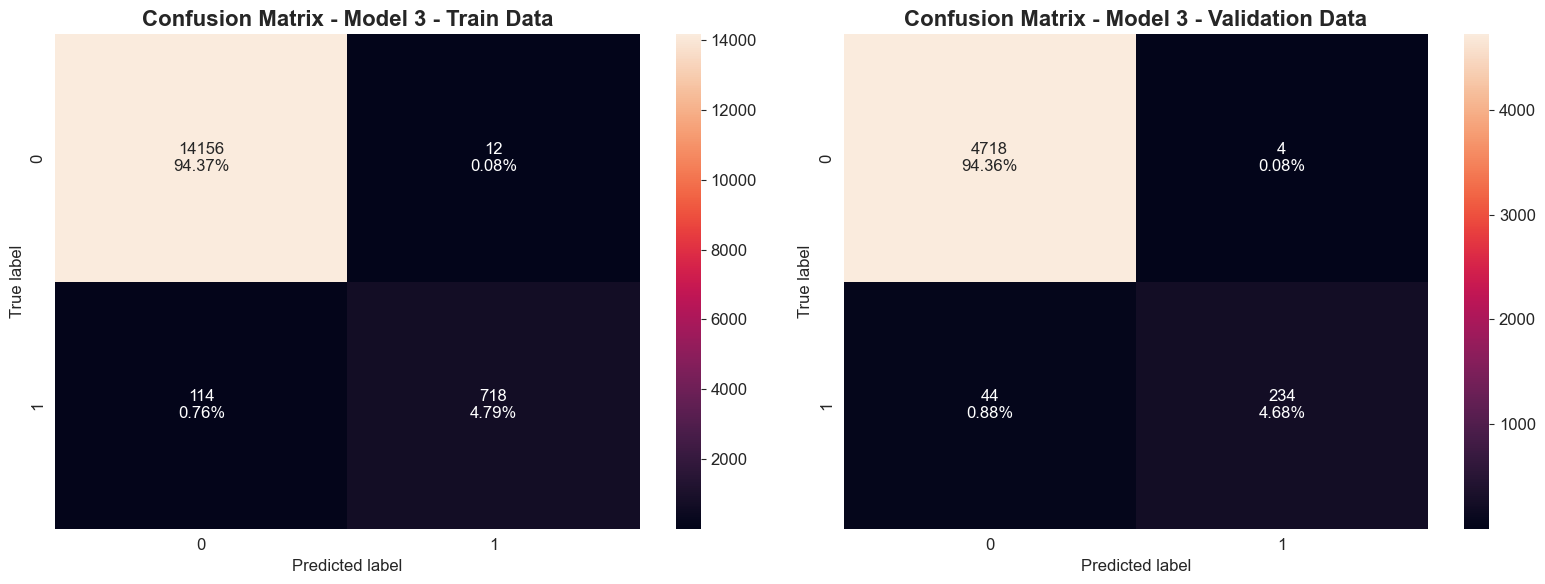

In [89]:
# Plot Confusion Matrices for Model 3
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot_confussion_matrix(model_3, X_train, y_train, "Confusion Matrix - Model 3 - Train Data")
plt.sca(ax2)
plot_confussion_matrix(model_3, X_val, y_val, "Confusion Matrix - Model 3 - Validation Data")
plt.tight_layout()
plt.show()

#### Observation:
- This model has improved a lot in Recall Scores. 
- It has much better scores than the Base Model, Model 1 and Model 2. 
- On the training data it scored 0.86 and the validation data scores 0.84 
- There is a clear reduction in False Negatives. Comparing againt the previous models. There seems to be some overfitting. 
- In the next model ADAM will be used as optimizer, looking for improvements. 
- A Learning Rate of 0.001 seems to achieve better Recall Scores. So we will keep this Learning Rate. 

## Model 4

This model will use the same architectures as model 1, model 2, and model 3. ADAM will be used as optimizer. ADAM will use a Learning Rate of 0.001 as this Learning Rate was the better one for SGD. 


In [90]:
# Clear any previous Keras session to avoid clutter
tf.keras.backend.clear_session()

In [91]:
# Model 4: Keeping the architecture same as Model 1, Model 2, and Model 3.
model_4 = Sequential()
model_4.add(Input(shape=(X_train.shape[1],)))
model_4.add(Dense(64, activation="relu"))
model_4.add(Dense(32, activation="relu"))
model_4.add(Dense(1, activation="sigmoid"))

In [92]:
# Model summary
model_4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [93]:
# Set the learning rate for Model 4
learning_rate = 0.001
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
model_4.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["Recall"])

In [94]:
# Fit the model for Model 4
start = time.time()
history_4 = model_4.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
)
end = time.time()

Epoch 1/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.3240 - loss: 0.2607 - val_Recall: 0.6799 - val_loss: 0.0855
Epoch 2/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.7425 - loss: 0.0708 - val_Recall: 0.7842 - val_loss: 0.0691
Epoch 3/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8145 - loss: 0.0562 - val_Recall: 0.8094 - val_loss: 0.0626
Epoch 4/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8415 - loss: 0.0495 - val_Recall: 0.8201 - val_loss: 0.0596
Epoch 5/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8466 - loss: 0.0457 - val_Recall: 0.8201 - val_loss: 0.0579
Epoch 6/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8617 - loss: 0.0428 - val_Recall: 0.8237 - val_loss: 0.0569
Epoch 7/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8757 - loss: 0.0405 - val_Recall: 0.8345 - val_loss: 0.0561
Epoch 8/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8730 - loss: 0.0388 - val_Recall: 0.8417 - val_loss: 0.0557
Epoch 9/

In [95]:
print(f"Training time: {end - start:.2f} seconds")

Training time: 16.14 seconds


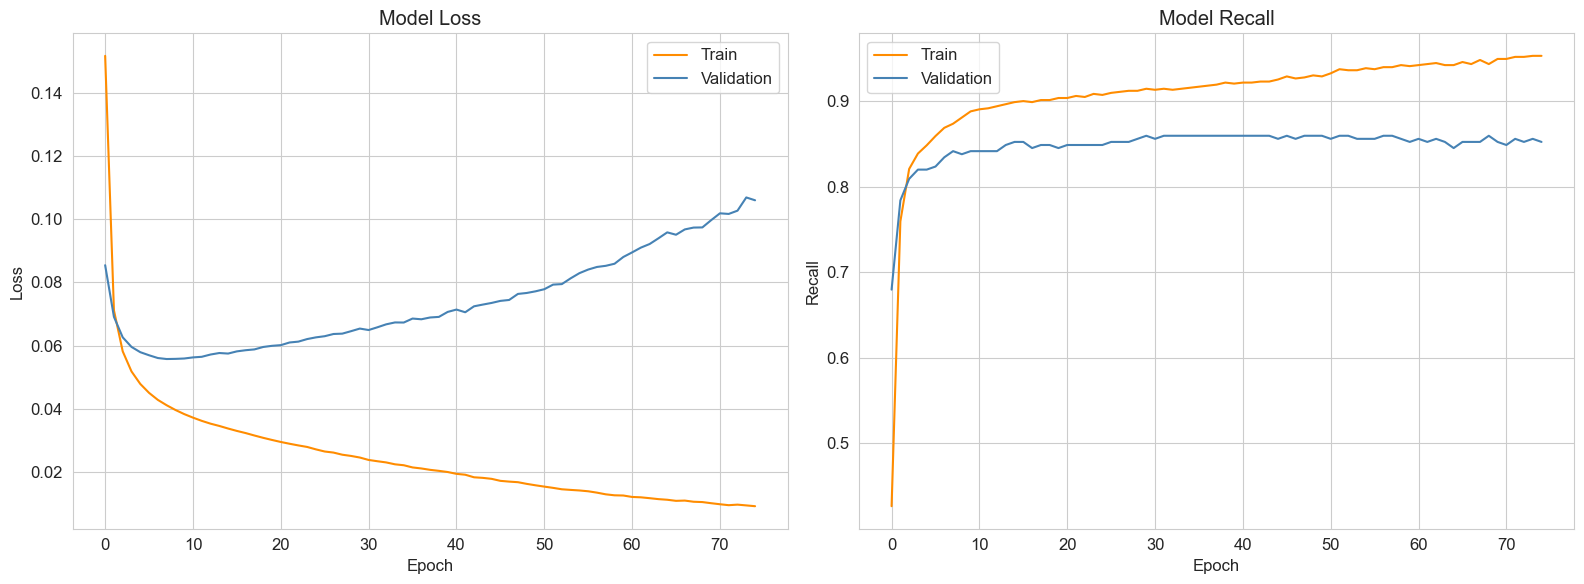

In [96]:
# Plot Loss and Recall for Model 4
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot(history_4, "loss")
plt.sca(ax2)
plot(history_4, "Recall")
plt.tight_layout()
plt.show()

#### Observation:
* The training loss decreases sharply and continues to decline.
* The validation loss decreases and after epoch 10 it starts to increase. Looks like overfitting. 
* This model has Recall scores in training reach above 90 in the final epochs. Validation peaks around 0.85 
* The model looks like it is overfitting and generalization is now worse. 

In [97]:
# log the model 4
results = model_logger(results, hidden_layers=2, neurons=[64, 32], activation_fn=["relu", "relu"],
                        epochs=epochs, batch_size=batch_size, optimizer="adam", learning_rate=[learning_rate, "-"], 
                        weight_init=["xavier", "xavier"], regularization="-", history=history_4, elapsed_time=end - start)
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",class weight strategy,weight initializer,regularization,callbacks used,train loss,validation loss,train recall,validation recall,time (secs)
0,1,32,relu,75,128,SGD,"[0.001, -]",imbalanced,xavier,-,-,0.053337,0.067357,0.823317,0.809353,17.08
1,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.0001, 0.9]",imbalanced,"[xavier, xavier]",-,-,0.081540,0.086714,0.675481,0.694245,17.14
2,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.0001, 0.4]",imbalanced,"[xavier, xavier]",-,-,0.140907,0.141586,0.286058,0.327338,15.93
3,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.001, 0.9]",imbalanced,"[xavier, xavier]",-,-,0.041506,0.058346,0.861779,0.841727,16.13
4,2,"[64, 32]","[relu, relu]",75,128,adam,"[0.001, -]",imbalanced,"[xavier, xavier]",-,-,0.009103,0.106040,0.953125,0.852518,16.14


In [98]:
# Evaluate the model on the train set for Model 4
model_4_train_perf = model_performance_classification(model_4, X_train, y_train)
model_4_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step


,Accuracy,Recall,Precision,F1 Score
0,0.995267,0.914663,1.0,0.95543


In [99]:
# Evaluate the model on the validation set for Model 4
model_4_val_perf = model_performance_classification(model_4, X_val, y_val)
model_4_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 521us/step


,Accuracy,Recall,Precision,F1 Score
0,0.9906,0.852518,0.975309,0.909789


In [100]:
# Classification Report for Train Data - Model 4
y_train_pred_4 = model_4.predict(X_train)
print("Classification Report - Train - Model 4",end="\n\n")
cr_train_model_4 = classification_report(y_train,y_train_pred_4>0.5)
print(cr_train_model_4)

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 460us/step
Classification Report - Train - Model 4

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     14168
         1.0       1.00      0.91      0.96       832

    accuracy                           1.00     15000
   macro avg       1.00      0.96      0.98     15000
weighted avg       1.00      1.00      1.00     15000



In [101]:
# Classification Report for Validation Data - Model 4
y_val_pred_4 = model_4.predict(X_val)
print("Classification Report - Validation - Model 4",end="\n\n")
cr_val_model_4 = classification_report(y_val,y_val_pred_4>0.5)
print(cr_val_model_4)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 532us/step
Classification Report - Validation - Model 4

              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00      4722
         1.0       0.98      0.85      0.91       278

    accuracy                           0.99      5000
   macro avg       0.98      0.93      0.95      5000
weighted avg       0.99      0.99      0.99      5000



469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 458us/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step


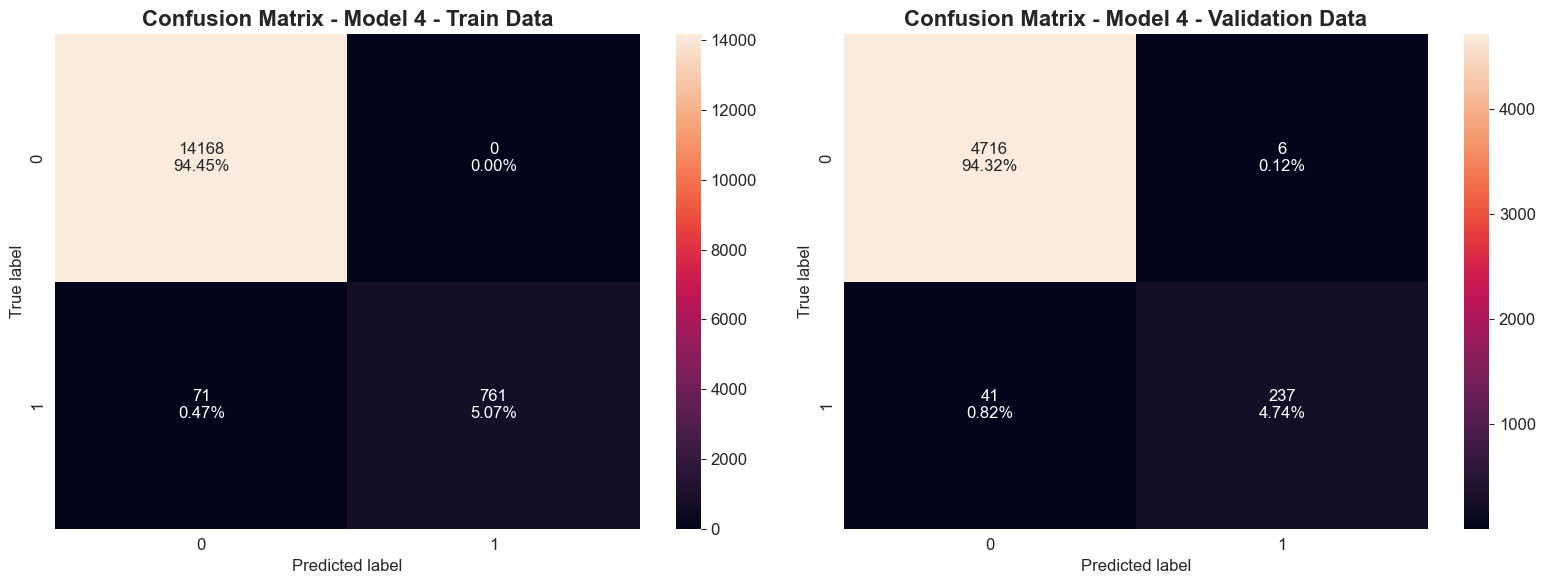

In [102]:
# Plot Confusion Matrices for Model 4
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot_confussion_matrix(model_4, X_train, y_train, "Confusion Matrix - Model 4 - Train Data")
plt.sca(ax2)
plot_confussion_matrix(model_4, X_val, y_val, "Confusion Matrix - Model 4 - Validation Data")
plt.tight_layout()
plt.show()

#### Observation:
- The model is performing better in Recall Scores. Training Recall Scores are now around 0.91, but for validation they are around 0.85. 
- The model has a decrese in False Negatives with the training set, but the validation set there is no real improvement compared to model 3. 
- Next model will decrease the learning rate. 

## Model 5

Model 5 will use the same architecture, it will also use ADAM as optimizer. The learning rate is now 0.0001 and will compare against the results of model 4. 

In [103]:
# Clear any previous Keras session to avoid clutter
tf.keras.backend.clear_session()

In [104]:
# Model 5: Keeping the architecture same as Model 1, Model 2, Model 3, and Model 4.
model_5 = Sequential()
model_5.add(Input(shape=(X_train.shape[1],)))
model_5.add(Dense(64, activation="relu"))
model_5.add(Dense(32, activation="relu"))
model_5.add(Dense(1, activation="sigmoid"))

In [105]:
# Model summary
model_5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [106]:
# Set the learning rate for Model 5
learning_rate = 0.0001
# Define the optimizer with Adam for Model 5
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
# Compile the model with the optimizer, loss function, and metrics for Model 5
model_5.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["Recall"])

In [107]:
# Fit the model for Model 5
start = time.time()
history_5 = model_5.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
)
end = time.time()

Epoch 1/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.1599 - loss: 0.5335 - val_Recall: 0.0647 - val_loss: 0.2069
Epoch 2/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.0539 - loss: 0.1870 - val_Recall: 0.1619 - val_loss: 0.1556
Epoch 3/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.1897 - loss: 0.1418 - val_Recall: 0.3489 - val_loss: 0.1308
Epoch 4/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.3932 - loss: 0.1186 - val_Recall: 0.4748 - val_loss: 0.1170
Epoch 5/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - Recall: 0.5002 - loss: 0.1047 - val_Recall: 0.5540 - val_loss: 0.1077
Epoch 6/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.5595 - loss: 0.0952 - val_Recall: 0.6187 - val_loss: 0.1008
Epoch 7/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.6136 - loss: 0.0880 - val_Recall: 0.6439 - val_loss: 0.0953
Epoch 8/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.6553 - loss: 0.0823 - val_Recall: 0.6763 - val_loss: 0.0907
Epoch 9/

In [108]:
print(f"Training time: {end - start:.2f} seconds")

Training time: 16.55 seconds


In [109]:
# log the model 5
results = model_logger(results, hidden_layers=2, neurons=[64, 32], activation_fn=["relu", "relu"],
                        epochs=epochs, batch_size=batch_size, optimizer="adam", learning_rate=[learning_rate, "-"], 
                        weight_init=["xavier", "xavier"], regularization="-", history=history_5, elapsed_time=end - start)
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",class weight strategy,weight initializer,regularization,callbacks used,train loss,validation loss,train recall,validation recall,time (secs)
0,1,32,relu,75,128,SGD,"[0.001, -]",imbalanced,xavier,-,-,0.053337,0.067357,0.823317,0.809353,17.08
1,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.0001, 0.9]",imbalanced,"[xavier, xavier]",-,-,0.081540,0.086714,0.675481,0.694245,17.14
2,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.0001, 0.4]",imbalanced,"[xavier, xavier]",-,-,0.140907,0.141586,0.286058,0.327338,15.93
3,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.001, 0.9]",imbalanced,"[xavier, xavier]",-,-,0.041506,0.058346,0.861779,0.841727,16.13
4,2,"[64, 32]","[relu, relu]",75,128,adam,"[0.001, -]",imbalanced,"[xavier, xavier]",-,-,0.009103,0.106040,0.953125,0.852518,16.14
5,2,"[64, 32]","[relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[xavier, xavier]",-,-,0.033216,0.052694,0.897837,0.856115,16.55


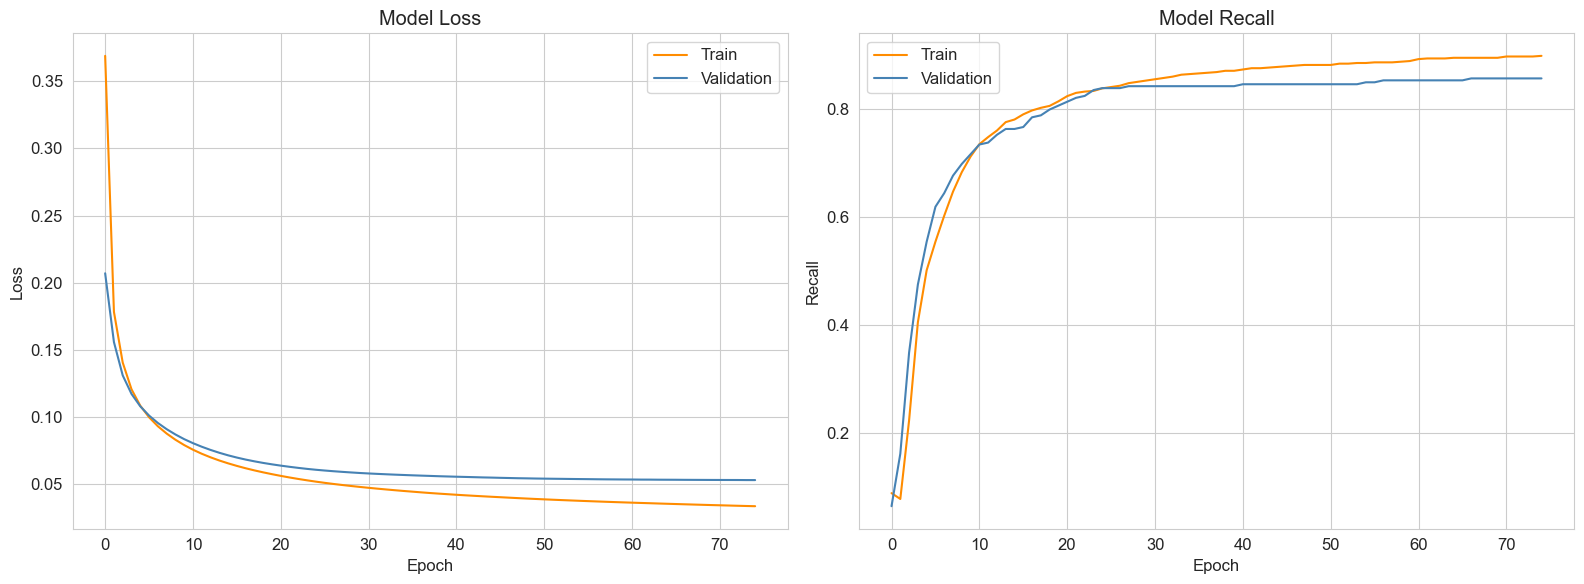

In [110]:
# Plot Loss and Recall for Model 5
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot(history_5, "loss")
plt.sca(ax2)
plot(history_5, "Recall")
plt.tight_layout()
plt.show()

#### Observation: 
- Both training and validation loss have a good decrease. 
- Final loss is around 0.05 meaning that the model is converging very good. 
- There seems that the overfitting is reduced, as Recall Scores seem to be more closely.
- Recall Scores are above 0.80 but not achieving scores of 0.90

In [111]:
# Evaluate the model on the train set for Model 5
model_5_train_perf = model_performance_classification(model_5, X_train, y_train)
model_5_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step


,Accuracy,Recall,Precision,F1 Score
0,0.994,0.90024,0.990741,0.943325


In [112]:
# Evaluate the model on the validation set for Model 5
model_5_val_perf = model_performance_classification(model_5, X_val, y_val)
model_5_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 563us/step


,Accuracy,Recall,Precision,F1 Score
0,0.9908,0.856115,0.97541,0.911877


In [113]:
# Classification Report for Train Data - Model 5
y_train_pred_5 = model_5.predict(X_train)
print("Classification Report - Train - Model 5",end="\n\n")
cr_train_model_5 = classification_report(y_train,y_train_pred_5>0.5)
print(cr_train_model_5)

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 579us/step
Classification Report - Train - Model 5

              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     14168
         1.0       0.99      0.90      0.94       832

    accuracy                           0.99     15000
   macro avg       0.99      0.95      0.97     15000
weighted avg       0.99      0.99      0.99     15000



In [114]:
# Classification Report for Validation Data - Model 5
y_val_pred_5 = model_5.predict(X_val)
print("Classification Report - Validation - Model 5",end="\n\n")
cr_val_model_5 = classification_report(y_val,y_val_pred_5>0.5)
print(cr_val_model_5)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 552us/step
Classification Report - Validation - Model 5

              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00      4722
         1.0       0.98      0.86      0.91       278

    accuracy                           0.99      5000
   macro avg       0.98      0.93      0.95      5000
weighted avg       0.99      0.99      0.99      5000



469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 530us/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step


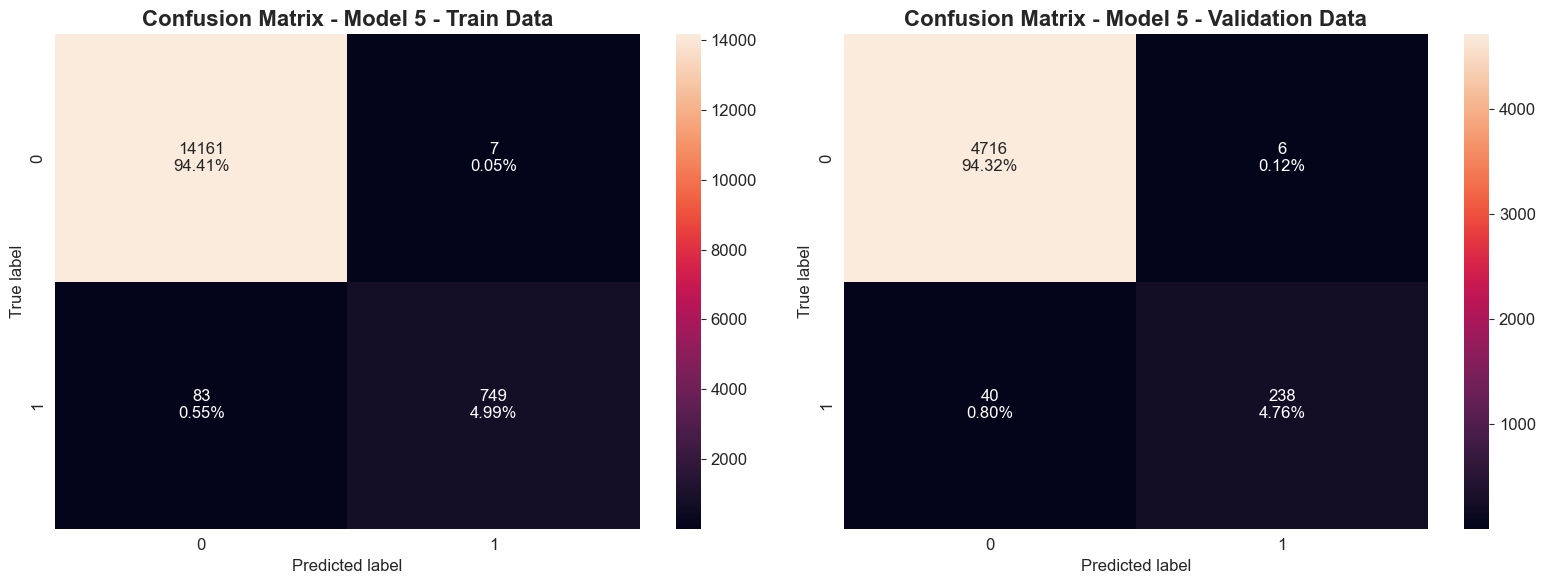

In [115]:
# Plot Confusion Matrices for Model 5
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot_confussion_matrix(model_5, X_train, y_train, "Confusion Matrix - Model 5 - Train Data")
plt.sca(ax2)
plot_confussion_matrix(model_5, X_val, y_val, "Confusion Matrix - Model 5 - Validation Data")
plt.tight_layout()
plt.show()

#### Observation:
* Model 5 is generalizing much better than Model 5. 
* Nevertheless there is no improvement in Recall Scores. 
* The lower Learning Rate help the model generalize better. So the learning rate will be kept at 0.0001
* It seems that there will be no further improvement in Recall with this architecture. Next model will experiment with a new hidden layer and dropout as regularization technique. 

## Model 6

Model 6 will have a more complex architecture than the the previous models. The idea will be to optimize the model and to be able to predit False Negatives (failures) better. 
* Three hidden layer with 128, 64 and 32 Neurons and ReLU activation. Add more capacity to learn feature interactions.
* In order to avoid overfitting 2 Dropout layers will be added. Ome affter the first hidden layer and the second dropout before the output layer.  
* ADAM with a learning rate of 0.0001 will be used as optimizer with Binary Cross-Entropy and Recall as metric. 
* The output layer will have one neuron and sigmoid activation. 

In [116]:
# Clear any previous Keras session to avoid clutter
tf.keras.backend.clear_session()

In [117]:
# Model 6: Adding more complexity with additional layers and dropout for regularization
model_6 = Sequential()
model_6.add(Input(shape=(X_train.shape[1],)))
model_6.add(Dense(128, activation="relu"))
model_6.add(Dropout(0.4))
model_6.add(Dense(64, activation="relu"))
model_6.add(Dense(32, activation="relu"))
model_6.add(Dropout(0.3))
model_6.add(Dense(1, activation="sigmoid"))

In [118]:
# Model summary
model_6.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,617 (61.00 KB)

 Trainable params: 15,617 (61.00 KB)

 Non-trainable params: 0 (0.00 B)

In [119]:
# Define the optimizer with Adam for Model 6
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
# Compile the model with the optimizer, loss function, and metrics for Model 6
model_6.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["Recall"])

In [120]:
# Fit the model for Model 6
start = time.time()
history_6 = model_6.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
)
end = time.time()

Epoch 1/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.1297 - loss: 0.4743 - val_Recall: 0.0000e+00 - val_loss: 0.1911
Epoch 2/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.0256 - loss: 0.2204 - val_Recall: 0.0108 - val_loss: 0.1546
Epoch 3/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.0787 - loss: 0.1880 - val_Recall: 0.1691 - val_loss: 0.1349
Epoch 4/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.1855 - loss: 0.1618 - val_Recall: 0.3381 - val_loss: 0.1229
Epoch 5/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.2495 - loss: 0.1467 - val_Recall: 0.4712 - val_loss: 0.1132
Epoch 6/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.3595 - loss: 0.1345 - val_Recall: 0.5324 - val_loss: 0.1063
Epoch 7/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.3935 - loss: 0.1301 - val_Recall: 0.5971 - val_loss: 0.1003
Epoch 8/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.5220 - loss: 0.1155 - val_Recall: 0.6439 - val_loss: 0.0956
Epoc

In [121]:
print(f"Training time: {end - start:.2f} seconds")

Training time: 19.54 seconds


In [122]:
# Plot Loss and Recall for Model 6
results = model_logger(results, hidden_layers=3, neurons=[128, 64, 32], activation_fn=["relu", "relu", "relu"],
                        epochs=epochs, batch_size=batch_size, optimizer="adam", learning_rate=[learning_rate, "-"], 
                        weight_init=["xavier", "xavier", "xavier"], regularization=["Dropout (0.4)", "Dropout (0.3)"], 
                        history=history_6, elapsed_time=end - start)
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",class weight strategy,weight initializer,regularization,callbacks used,train loss,validation loss,train recall,validation recall,time (secs)
0,1,32,relu,75,128,SGD,"[0.001, -]",imbalanced,xavier,-,-,0.053337,0.067357,0.823317,0.809353,17.08
1,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.0001, 0.9]",imbalanced,"[xavier, xavier]",-,-,0.081540,0.086714,0.675481,0.694245,17.14
2,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.0001, 0.4]",imbalanced,"[xavier, xavier]",-,-,0.140907,0.141586,0.286058,0.327338,15.93
3,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.001, 0.9]",imbalanced,"[xavier, xavier]",-,-,0.041506,0.058346,0.861779,0.841727,16.13
4,2,"[64, 32]","[relu, relu]",75,128,adam,"[0.001, -]",imbalanced,"[xavier, xavier]",-,-,0.009103,0.106040,0.953125,0.852518,16.14
5,2,"[64, 32]","[relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[xavier, xavier]",-,-,0.033216,0.052694,0.897837,0.856115,16.55
6,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[xavier, xavier, xavier]","[Dropout (0.4), Dropout (0.3)]",-,0.046867,0.052945,0.867788,0.863309,19.54


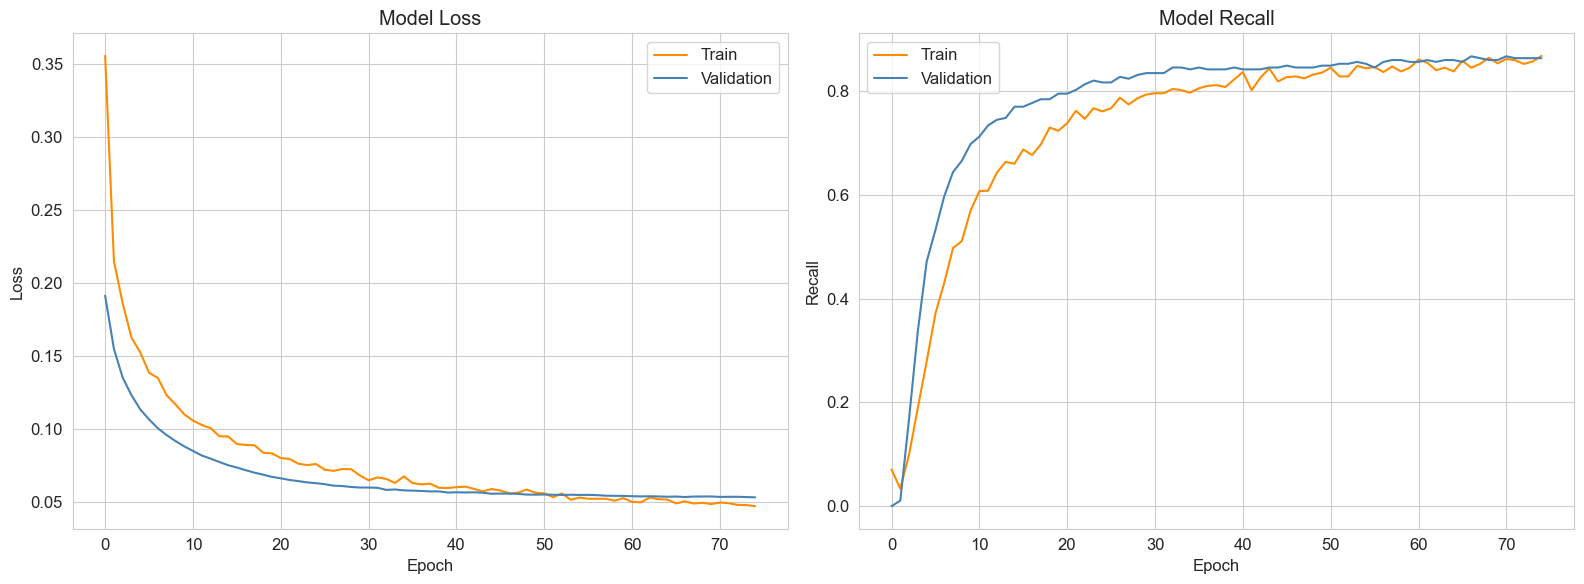

In [123]:
# Plot Loss and Recall for Model 6
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot(history_6, "loss")
plt.sca(ax2)
plot(history_6, "Recall")
plt.tight_layout()
plt.show()

#### Observations: 
* Training loss drops smoothly but Validation decline is slower and a little bit more flat. 
* There are no spikes in the loss plots. 
* There seems to be a good recall scores. Validation Recall Scores seem to have a slight improvement than previous models. 
* It doesn't look like there is overfitting. 

In [124]:
# Evaluate the model on the train set for Model 6
model_6_train_perf = model_performance_classification(model_6, X_train, y_train)
model_6_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 596us/step


,Accuracy,Recall,Precision,F1 Score
0,0.993533,0.890625,0.991968,0.938569


In [125]:
# Evaluate the model on the validation set for Model 6
model_6_val_perf = model_performance_classification(model_6, X_val, y_val)
model_6_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 550us/step


,Accuracy,Recall,Precision,F1 Score
0,0.9914,0.863309,0.979592,0.917782


In [126]:
# Classification Report for Train Data - Model 6
y_train_pred_6 = model_6.predict(X_train)
print("Classification Report - Train - Model 6",end="\n\n")
cr_train_model_6 = classification_report(y_train,y_train_pred_6>0.5)
print(cr_train_model_6)

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 731us/step
Classification Report - Train - Model 6

              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     14168
         1.0       0.99      0.89      0.94       832

    accuracy                           0.99     15000
   macro avg       0.99      0.95      0.97     15000
weighted avg       0.99      0.99      0.99     15000



In [127]:
# Classification Report for Validation Data - Model 6
y_val_pred_6 = model_6.predict(X_val)
print("Classification Report - Validation - Model 6",end="\n\n")
cr_val_model_6 = classification_report(y_val,y_val_pred_6>0.5)
print(cr_val_model_6)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 767us/step
Classification Report - Validation - Model 6

              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00      4722
         1.0       0.98      0.86      0.92       278

    accuracy                           0.99      5000
   macro avg       0.99      0.93      0.96      5000
weighted avg       0.99      0.99      0.99      5000



469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 576us/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 658us/step


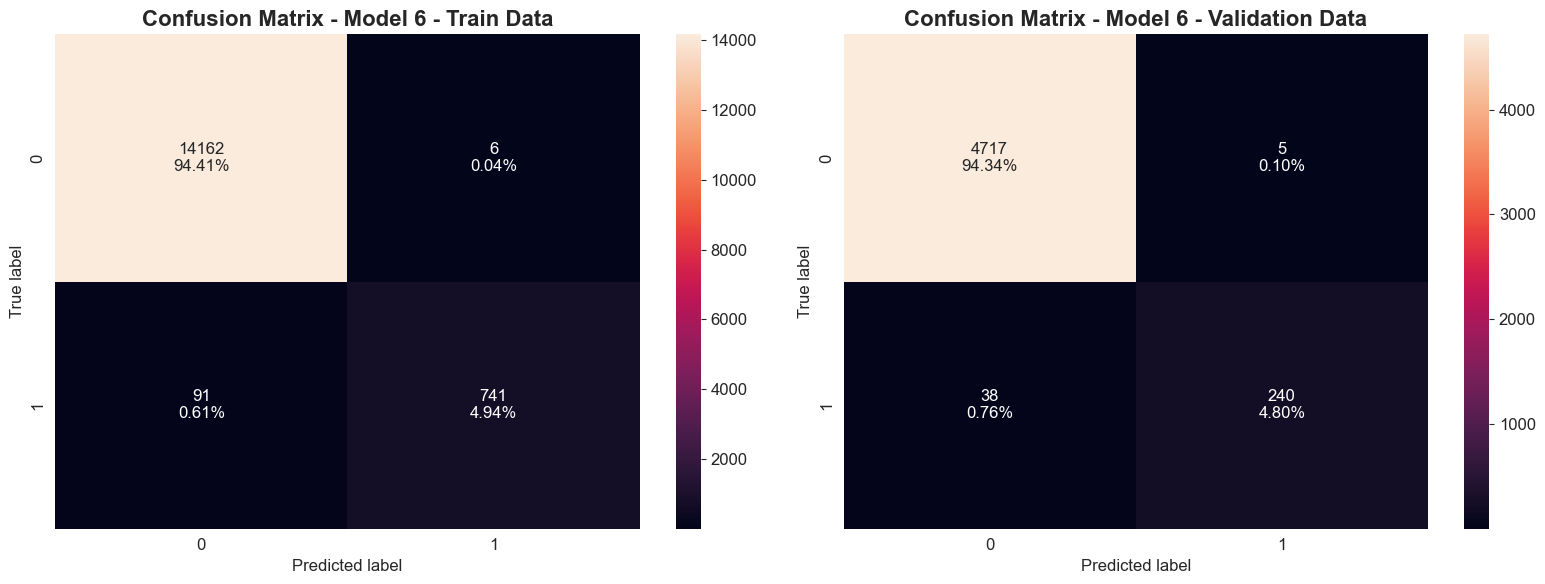

In [128]:
# Plot Confusion Matrices for Model 6
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot_confussion_matrix(model_6, X_train, y_train, "Confusion Matrix - Model 6 - Train Data")
plt.sca(ax2)
plot_confussion_matrix(model_6, X_val, y_val, "Confusion Matrix - Model 6 - Validation Data")
plt.tight_layout()
plt.show()

#### Observtion:
- The new hidden layer allows the model to learn feature interactions and the early dropout prevents overfitting. 
- The validation recall scores have improved. The model predictes less False Negatives. 
- Looks like the new architecture will allow to improve recall scores. 
- Next model will introduce batch normalization. 

## Model 7

Model 7 will add Batch Normalization before the Dropout layers. The idea is to accelerate convergance and stabilize learning. 

In [129]:
# Clear any previous Keras session to avoid clutter
tf.keras.backend.clear_session()

In [130]:
# Model 7: Adding more complexity with additional layers, dropout, and batch normalization
model_7 = Sequential()
model_7.add(Input(shape=(X_train.shape[1],)))
model_7.add(Dense(128, activation="relu"))
model_7.add(BatchNormalization())
model_7.add(Dropout(0.4))
model_7.add(Dense(64, activation="relu"))
model_7.add(Dense(32, activation="relu"))
model_7.add(BatchNormalization())
model_7.add(Dropout(0.3))
model_7.add(Dense(1, activation="sigmoid"))

In [131]:
# Model summary
model_7.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,257 (63.50 KB)

 Trainable params: 15,937 (62.25 KB)

 Non-trainable params: 320 (1.25 KB)

In [132]:
# Define the optimizer with Adam for Model 7
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
# Compile the model with the optimizer, loss function, and metrics for Model 7
model_7.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["Recall"])

In [133]:
# Fit the model for Model 7
start = time.time()
history_7 = model_7.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
)
end = time.time()

Epoch 1/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.7391 - loss: 0.8770 - val_Recall: 0.8453 - val_loss: 0.6371
Epoch 2/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.7723 - loss: 0.7797 - val_Recall: 0.8309 - val_loss: 0.5419
Epoch 3/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8088 - loss: 0.6934 - val_Recall: 0.8273 - val_loss: 0.4893
Epoch 4/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.7938 - loss: 0.6285 - val_Recall: 0.8381 - val_loss: 0.4461
Epoch 5/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8484 - loss: 0.5866 - val_Recall: 0.8417 - val_loss: 0.4087
Epoch 6/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8078 - loss: 0.5339 - val_Recall: 0.8453 - val_loss: 0.3795
Epoch 7/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8090 - loss: 0.4933 - val_Recall: 0.8453 - val_loss: 0.3454
Epoch 8/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8187 - loss: 0.4648 - val_Recall: 0.8489 - val_loss: 0.3216
Epoch 9/

In [134]:
print(f"Training time: {end - start:.2f} seconds")

Training time: 22.75 seconds


In [135]:
# log the model 7
results = model_logger(results, hidden_layers=3, neurons=[128, 64, 32], activation_fn=["relu", "relu", "relu"],
                        epochs=epochs, batch_size=batch_size, optimizer="adam", learning_rate=[learning_rate, "-"], 
                        weight_init=["xavier", "xavier", "xavier"], regularization=["BatchNorm", "Dropout (0.4)", "BatchNorm","Dropout (0.3)"], 
                        history=history_7, elapsed_time=end - start)
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",class weight strategy,weight initializer,regularization,callbacks used,train loss,validation loss,train recall,validation recall,time (secs)
0,1,32,relu,75,128,SGD,"[0.001, -]",imbalanced,xavier,-,-,0.053337,0.067357,0.823317,0.809353,17.08
1,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.0001, 0.9]",imbalanced,"[xavier, xavier]",-,-,0.081540,0.086714,0.675481,0.694245,17.14
2,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.0001, 0.4]",imbalanced,"[xavier, xavier]",-,-,0.140907,0.141586,0.286058,0.327338,15.93
3,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.001, 0.9]",imbalanced,"[xavier, xavier]",-,-,0.041506,0.058346,0.861779,0.841727,16.13
4,2,"[64, 32]","[relu, relu]",75,128,adam,"[0.001, -]",imbalanced,"[xavier, xavier]",-,-,0.009103,0.106040,0.953125,0.852518,16.14
5,2,"[64, 32]","[relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[xavier, xavier]",-,-,0.033216,0.052694,0.897837,0.856115,16.55
6,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[xavier, xavier, xavier]","[Dropout (0.4), Dropout (0.3)]",-,0.046867,0.052945,0.867788,0.863309,19.54
7,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[xavier, xavier, xavier]","[BatchNorm, Dropout (0.4), BatchNorm, Dropout ...",-,0.050546,0.057770,0.824519,0.852518,22.75


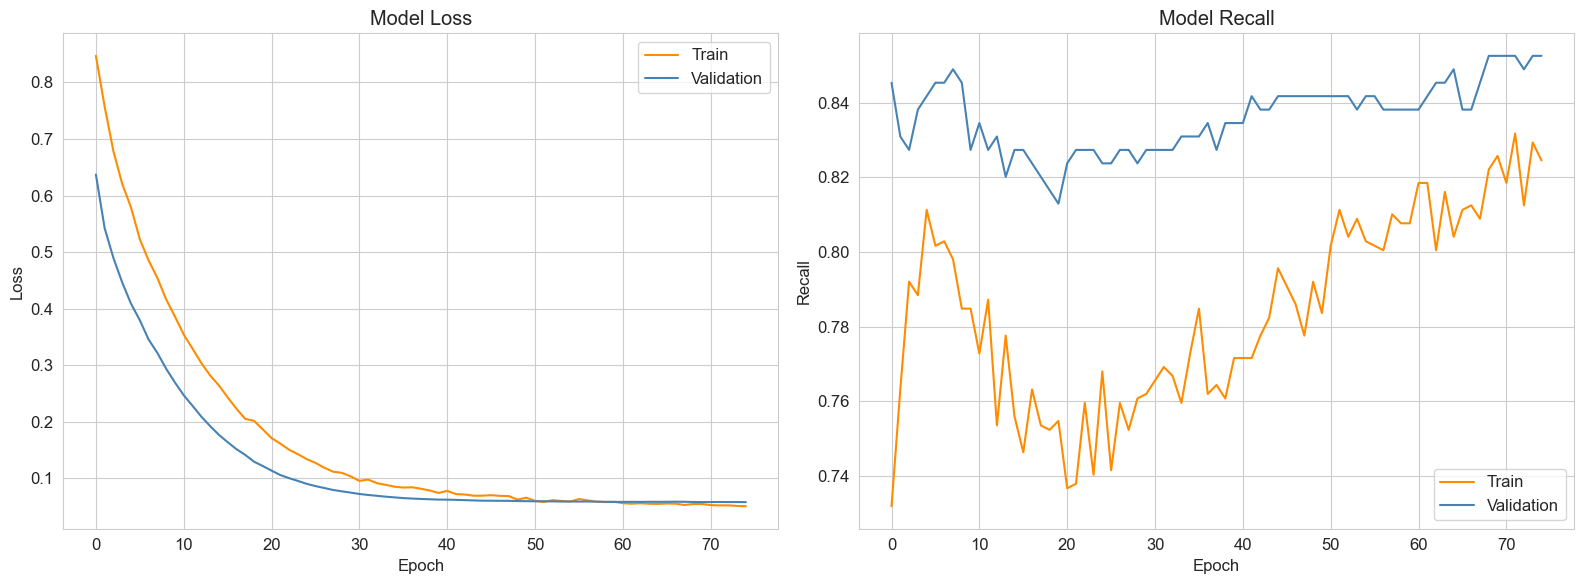

In [136]:
# Plot Loss and Recall for Model 7
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot(history_7, "loss")
plt.sca(ax2)
plot(history_7, "Recall")
plt.tight_layout()
plt.show()

#### Observations:
- There is more stability in the loss for training and validation. This means a smother convergance. 
- Validation loss now tracks Training loss very closely. 
- Recall scores fluctuate more in validation. 
- Recall scores keep improving in the final epochs. 

In [137]:
# Evaluate the model on the train set for Model 7
model_7_train_perf = model_performance_classification(model_7, X_train, y_train)
model_7_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 785us/step


,Accuracy,Recall,Precision,F1 Score
0,0.992267,0.867788,0.991758,0.925641


In [138]:
# Evaluate the model on the validation set for Model 7
model_7_val_perf = model_performance_classification(model_7, X_val, y_val)
model_7_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 662us/step


,Accuracy,Recall,Precision,F1 Score
0,0.9906,0.852518,0.975309,0.909789


In [139]:
# Classification Report for Train Data - Model 7
y_train_pred_7 = model_7.predict(X_train)
print("Classification Report - Train - Model 7",end="\n\n")
cr_train_model_7 = classification_report(y_train,y_train_pred_7>0.5)
print(cr_train_model_7)

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step
Classification Report - Train - Model 7

              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     14168
         1.0       0.99      0.87      0.93       832

    accuracy                           0.99     15000
   macro avg       0.99      0.93      0.96     15000
weighted avg       0.99      0.99      0.99     15000



In [140]:
# Classification Report for Validation Data - Model 7
y_val_pred_7 = model_7.predict(X_val)
print("Classification Report - Validation - Model 7",end="\n\n")
cr_val_model_7 = classification_report(y_val,y_val_pred_7>0.5)
print(cr_val_model_7)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 570us/step
Classification Report - Validation - Model 7

              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00      4722
         1.0       0.98      0.85      0.91       278

    accuracy                           0.99      5000
   macro avg       0.98      0.93      0.95      5000
weighted avg       0.99      0.99      0.99      5000



469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 570us/step


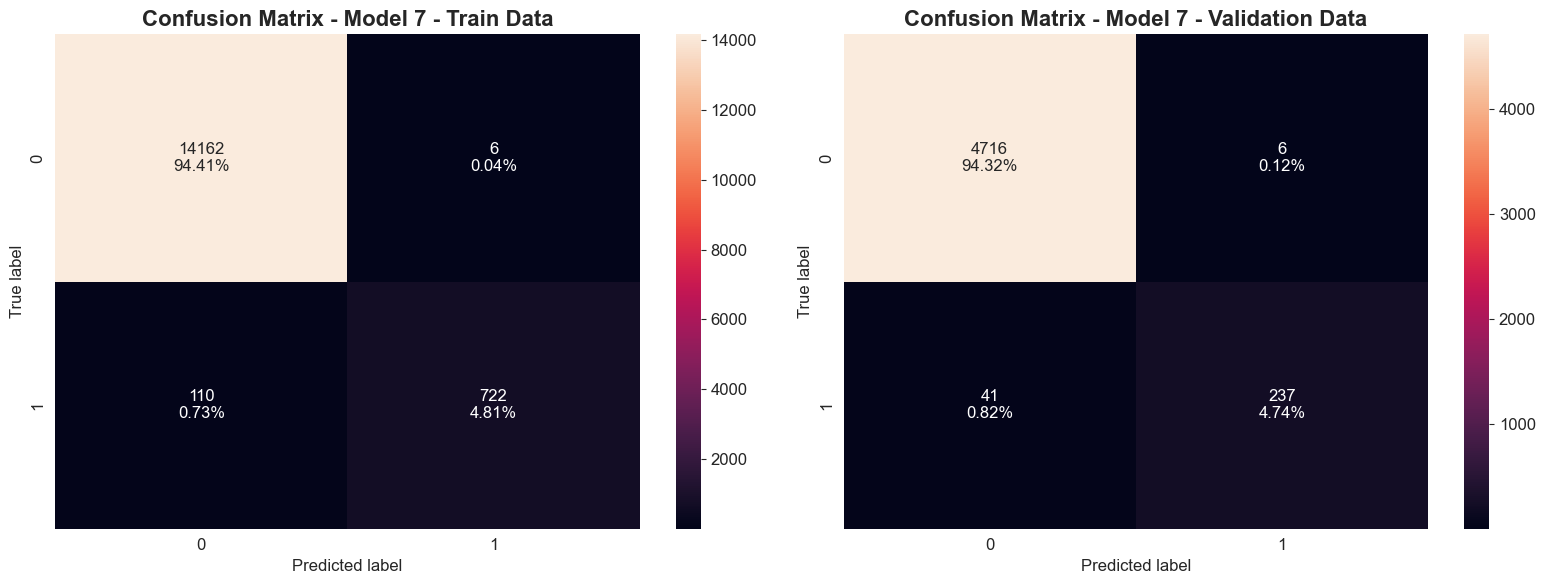

In [141]:
# Plot Confusion Matrices for Model 7
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot_confussion_matrix(model_7, X_train, y_train, "Confusion Matrix - Model 7 - Train Data")
plt.sca(ax2)
plot_confussion_matrix(model_7, X_val, y_val, "Confusion Matrix - Model 7 - Validation Data")
plt.tight_layout()
plt.show()

#### Observation:
- Model 7 didn't improve Recall scores. Model 6 has better Recall.
- There is no decrease in false negatives, there is a very slight increase. 
- Batch normalization will be kept as there in no meaningful decrease in performance and other optimization techniques can benefit from the Batch Normalization. 
- Next model will use He Weight Initializer for the hidden layers, Xavier will be kept for the output layer. 

## Model 8

Model 8 will use HE Weight Initalization for the hidden layers. He works very well with ReLU activation as it helps to avoid vanishing/exploding gradients during training. 
As there is no significant decrease in performance Batch normalization will be kept. 

In [142]:
# Clear any previous Keras session to avoid clutter
tf.keras.backend.clear_session()

In [143]:
# Model 8: Adding more complexity with additional layers, dropout, batch normalization, and He normal initialization
model_8 = Sequential()
model_8.add(Input(shape=(X_train.shape[1],)))
model_8.add(Dense(128, activation="relu", kernel_initializer="he_normal"))
model_8.add(BatchNormalization())
model_8.add(Dropout(0.4))
model_8.add(Dense(64, activation="relu", kernel_initializer="he_normal"))
model_8.add(Dense(32, activation="relu", kernel_initializer="he_normal"))
model_8.add(BatchNormalization())
model_8.add(Dropout(0.3))
model_8.add(Dense(1, activation="sigmoid"))

In [144]:
# Model summary
model_8.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,257 (63.50 KB)

 Trainable params: 15,937 (62.25 KB)

 Non-trainable params: 320 (1.25 KB)

In [145]:
# Define the optimizer with Adam for Model 8
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
# Compile the model with the optimizer, loss function, and metrics for Model 8
model_8.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["Recall"])

In [146]:
# Fit the model for Model 8
start = time.time()
history_8 = model_8.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
)
end = time.time()

Epoch 1/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - Recall: 0.5383 - loss: 0.8591 - val_Recall: 0.8309 - val_loss: 0.6796
Epoch 2/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.6797 - loss: 0.7564 - val_Recall: 0.8309 - val_loss: 0.5855
Epoch 3/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Recall: 0.7263 - loss: 0.6957 - val_Recall: 0.8417 - val_loss: 0.5476
Epoch 4/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.7197 - loss: 0.6464 - val_Recall: 0.8345 - val_loss: 0.5177
Epoch 5/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.7510 - loss: 0.6106 - val_Recall: 0.8273 - val_loss: 0.4897
Epoch 6/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.7594 - loss: 0.5750 - val_Recall: 0.8237 - val_loss: 0.4520
Epoch 7/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.7187 - loss: 0.5403 - val_Recall: 0.8165 - val_loss: 0.4196
Epoch 8/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.7292 - loss: 0.5039 - val_Recall: 0.8129 - val_loss: 0.3924
Epoch 9/

In [147]:
print(f"Training time: {end - start:.2f} seconds")

Training time: 22.68 seconds


In [148]:
# log the model 8
results = model_logger(results, hidden_layers=3, neurons=[128, 64, 32], activation_fn=["relu", "relu", "relu"],
                        epochs=epochs, batch_size=batch_size, optimizer="adam", learning_rate=[learning_rate, "-"], 
                        weight_init=["he", "he", "he"], regularization=["BatchNorm", "Dropout (0.4)", "BatchNorm","Dropout (0.3)"], 
                        history=history_8, elapsed_time=end - start)
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",class weight strategy,weight initializer,regularization,callbacks used,train loss,validation loss,train recall,validation recall,time (secs)
0,1,32,relu,75,128,SGD,"[0.001, -]",imbalanced,xavier,-,-,0.053337,0.067357,0.823317,0.809353,17.08
1,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.0001, 0.9]",imbalanced,"[xavier, xavier]",-,-,0.081540,0.086714,0.675481,0.694245,17.14
2,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.0001, 0.4]",imbalanced,"[xavier, xavier]",-,-,0.140907,0.141586,0.286058,0.327338,15.93
3,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.001, 0.9]",imbalanced,"[xavier, xavier]",-,-,0.041506,0.058346,0.861779,0.841727,16.13
4,2,"[64, 32]","[relu, relu]",75,128,adam,"[0.001, -]",imbalanced,"[xavier, xavier]",-,-,0.009103,0.106040,0.953125,0.852518,16.14
5,2,"[64, 32]","[relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[xavier, xavier]",-,-,0.033216,0.052694,0.897837,0.856115,16.55
6,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[xavier, xavier, xavier]","[Dropout (0.4), Dropout (0.3)]",-,0.046867,0.052945,0.867788,0.863309,19.54
7,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[xavier, xavier, xavier]","[BatchNorm, Dropout (0.4), BatchNorm, Dropout ...",-,0.050546,0.057770,0.824519,0.852518,22.75
8,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[he, he, he]","[BatchNorm, Dropout (0.4), BatchNorm, Dropout ...",-,0.057768,0.053996,0.796875,0.848921,22.68


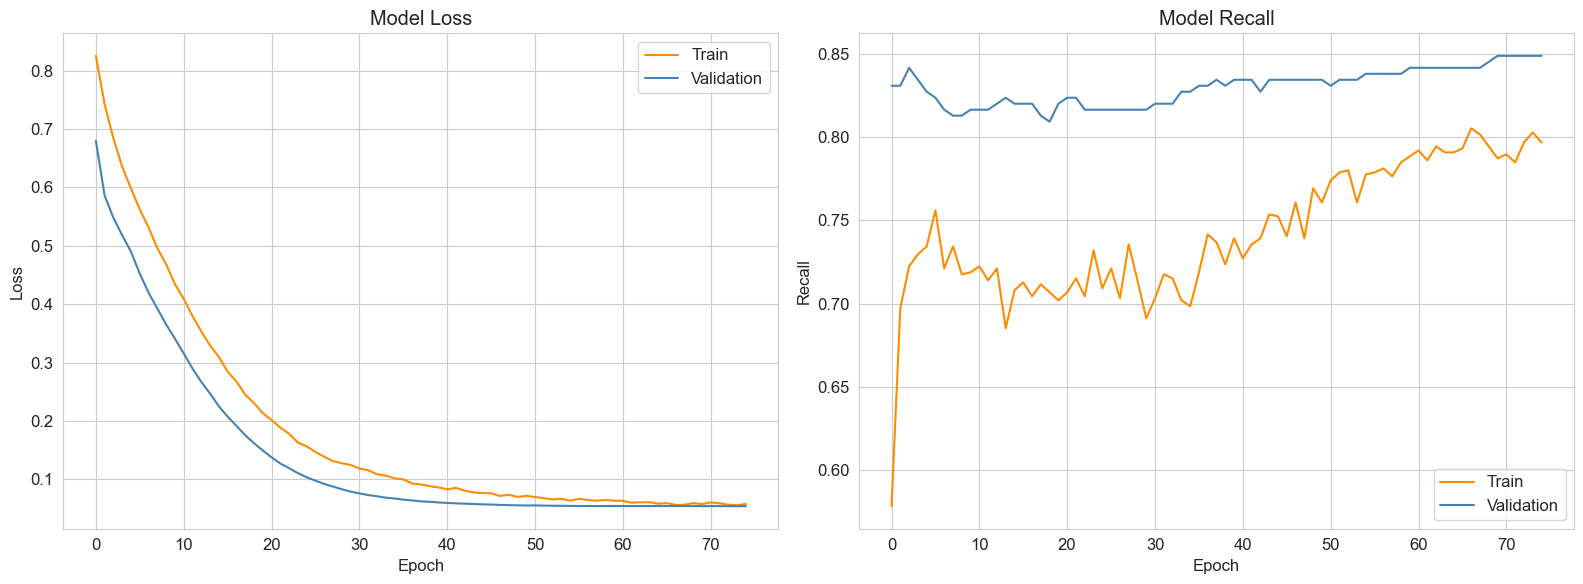

In [149]:
# Plot Loss and Recall for Model 8
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot(history_8, "loss")
plt.sca(ax2)
plot(history_8, "Recall")
plt.tight_layout()
plt.show()

#### Observation:
- The loss plots remain steady and they decrese smoothly. 
- The validation recall started high in the first epochs and started to increase. 
- Validation Recall is above training Recall. 
- The model is generalizing much better with validation data. 

In [150]:
# Evaluate the model on the train set for Model 8
model_8_train_perf = model_performance_classification(model_8, X_train, y_train)
model_8_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 631us/step


,Accuracy,Recall,Precision,F1 Score
0,0.9918,0.861779,0.988966,0.921002


In [151]:
# Evaluate the model on the validation set for Model 8
model_8_val_perf = model_performance_classification(model_8, X_val, y_val)
model_8_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step


,Accuracy,Recall,Precision,F1 Score
0,0.991,0.848921,0.987448,0.912959


In [152]:
# Classification Report for Train Data - Model 8
y_train_pred_8 = model_8.predict(X_train)
print("Classification Report - Train - Model 8",end="\n\n")
cr_train_model_8 = classification_report(y_train,y_train_pred_8>0.5)
print(cr_train_model_8)

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 508us/step
Classification Report - Train - Model 8

              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     14168
         1.0       0.99      0.86      0.92       832

    accuracy                           0.99     15000
   macro avg       0.99      0.93      0.96     15000
weighted avg       0.99      0.99      0.99     15000



In [153]:
# Classification Report for Validation Data - Model 8
y_val_pred_8 = model_8.predict(X_val)
print("Classification Report - Validation - Model 8",end="\n\n")
cr_val_model_8 = classification_report(y_val,y_val_pred_8>0.5)
print(cr_val_model_8)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step
Classification Report - Validation - Model 8

              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00      4722
         1.0       0.99      0.85      0.91       278

    accuracy                           0.99      5000
   macro avg       0.99      0.92      0.95      5000
weighted avg       0.99      0.99      0.99      5000



469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 505us/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 560us/step


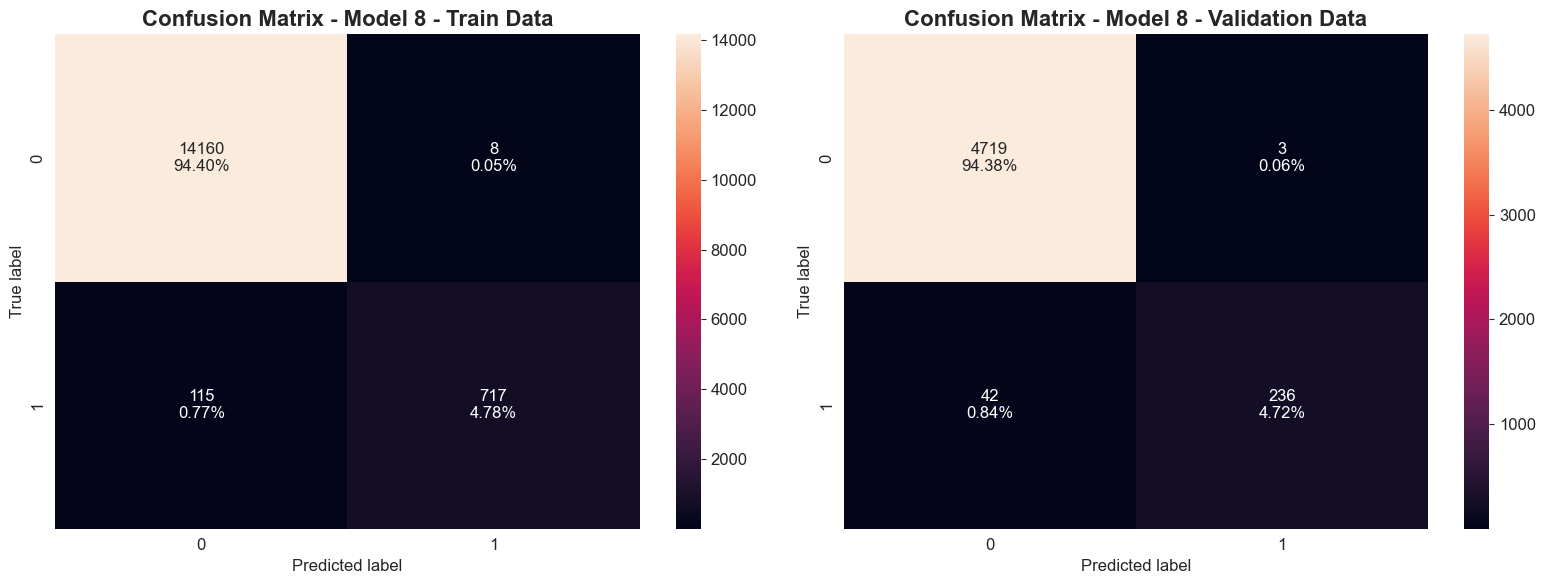

In [154]:
# Plot Confusion Matrices for Model 8
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot_confussion_matrix(model_8, X_train, y_train, "Confusion Matrix - Model 8 - Train Data")
plt.sca(ax2)
plot_confussion_matrix(model_8, X_val, y_val, "Confusion Matrix - Model 8 - Validation Data")
plt.tight_layout()
plt.show()

#### Observation:
* The model is generalizing much better. 
* Nevertherless there is no improvement in recall and the false negatives are the same as previous models. 
* Next model will used a balanced class weight, in order to help the model reduce the number of false negatives. 


## Model 9

Model 9 will use the same architecture as Model 8. Model 9 will use a blanced class weight. In order for the model to reduce False Negatives and have a better Recall. As the dataset is imbalanced this will help with the performance of the model. 
False Negatives are penalized more. 

In [155]:
# Clear any previous Keras session to avoid clutter
tf.keras.backend.clear_session()

In [156]:
# Compute class weights for imbalanced class
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))
print("Class weights:", class_weights)

Class weights: {0: 0.5293619424054207, 1: 9.014423076923077}


Class 0 will have a weight of 0.5293 and Class 1 will have a weight of 9.0144, this will provide a blance.

In [157]:
# Model 9: Adding more complexity with additional layers, dropout, batch normalization, and He normal initialization
model_9 = Sequential()
model_9.add(Input(shape=(X_train.shape[1],)))
model_9.add(Dense(128, activation="relu", kernel_initializer="he_normal"))
model_9.add(BatchNormalization())
model_9.add(Dropout(0.4))
model_9.add(Dense(64, activation="relu", kernel_initializer="he_normal"))
model_9.add(Dense(32, activation="relu", kernel_initializer="he_normal"))
model_9.add(BatchNormalization())
model_9.add(Dropout(0.3))
model_9.add(Dense(1, activation="sigmoid"))

In [158]:
# Define the optimizer with Adam for Model 9
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
# Compile the model with the optimizer, loss function, and metrics for Model 9
model_9.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["Recall"])

In [159]:
# Fit the model for Model 9 with class weights
start = time.time()
history_9 = model_9.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weights
)
end = time.time()

Epoch 1/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.5931 - loss: 0.9441 - val_Recall: 0.6871 - val_loss: 0.5795
Epoch 2/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.7270 - loss: 0.7361 - val_Recall: 0.8489 - val_loss: 0.6732
Epoch 3/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8094 - loss: 0.6355 - val_Recall: 0.8741 - val_loss: 0.6634
Epoch 4/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8698 - loss: 0.5631 - val_Recall: 0.8849 - val_loss: 0.6232
Epoch 5/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8560 - loss: 0.5526 - val_Recall: 0.8957 - val_loss: 0.5680
Epoch 6/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8854 - loss: 0.4833 - val_Recall: 0.8957 - val_loss: 0.5188
Epoch 7/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8893 - loss: 0.4661 - val_Recall: 0.8957 - val_loss: 0.4877
Epoch 8/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.9081 - loss: 0.4440 - val_Recall: 0.8921 - val_loss: 0.4521
Epoch 9/

In [160]:
print(f"Training time: {end - start:.2f} seconds")

Training time: 21.95 seconds


In [161]:
# Plot Loss and Recall for Model 9
results = model_logger(results, hidden_layers=3, neurons=[128, 64, 32], activation_fn=["relu", "relu", "relu"],
                        epochs=epochs, batch_size=batch_size, optimizer="adam", learning_rate=[learning_rate, "-"], 
                        weight_init=["he", "he", "he"], regularization=["BatchNorm", "Dropout (0.4)", "BatchNorm","Dropout (0.3)"], 
                        history=history_9, elapsed_time=end - start, class_weight_strategy=class_weights)
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",class weight strategy,weight initializer,regularization,callbacks used,train loss,validation loss,train recall,validation recall,time (secs)
0,1,32,relu,75,128,SGD,"[0.001, -]",imbalanced,xavier,-,-,0.053337,0.067357,0.823317,0.809353,17.08
1,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.0001, 0.9]",imbalanced,"[xavier, xavier]",-,-,0.081540,0.086714,0.675481,0.694245,17.14
2,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.0001, 0.4]",imbalanced,"[xavier, xavier]",-,-,0.140907,0.141586,0.286058,0.327338,15.93
3,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.001, 0.9]",imbalanced,"[xavier, xavier]",-,-,0.041506,0.058346,0.861779,0.841727,16.13
4,2,"[64, 32]","[relu, relu]",75,128,adam,"[0.001, -]",imbalanced,"[xavier, xavier]",-,-,0.009103,0.106040,0.953125,0.852518,16.14
5,2,"[64, 32]","[relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[xavier, xavier]",-,-,0.033216,0.052694,0.897837,0.856115,16.55
6,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[xavier, xavier, xavier]","[Dropout (0.4), Dropout (0.3)]",-,0.046867,0.052945,0.867788,0.863309,19.54
7,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[xavier, xavier, xavier]","[BatchNorm, Dropout (0.4), BatchNorm, Dropout ...",-,0.050546,0.057770,0.824519,0.852518,22.75
8,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[he, he, he]","[BatchNorm, Dropout (0.4), BatchNorm, Dropout ...",-,0.057768,0.053996,0.796875,0.848921,22.68
9,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]","{0: 0.53, 1: 9.01}","[he, he, he]","[BatchNorm, Dropout (0.4), BatchNorm, Dropout ...",-,0.202344,0.101938,0.906250,0.884892,21.95


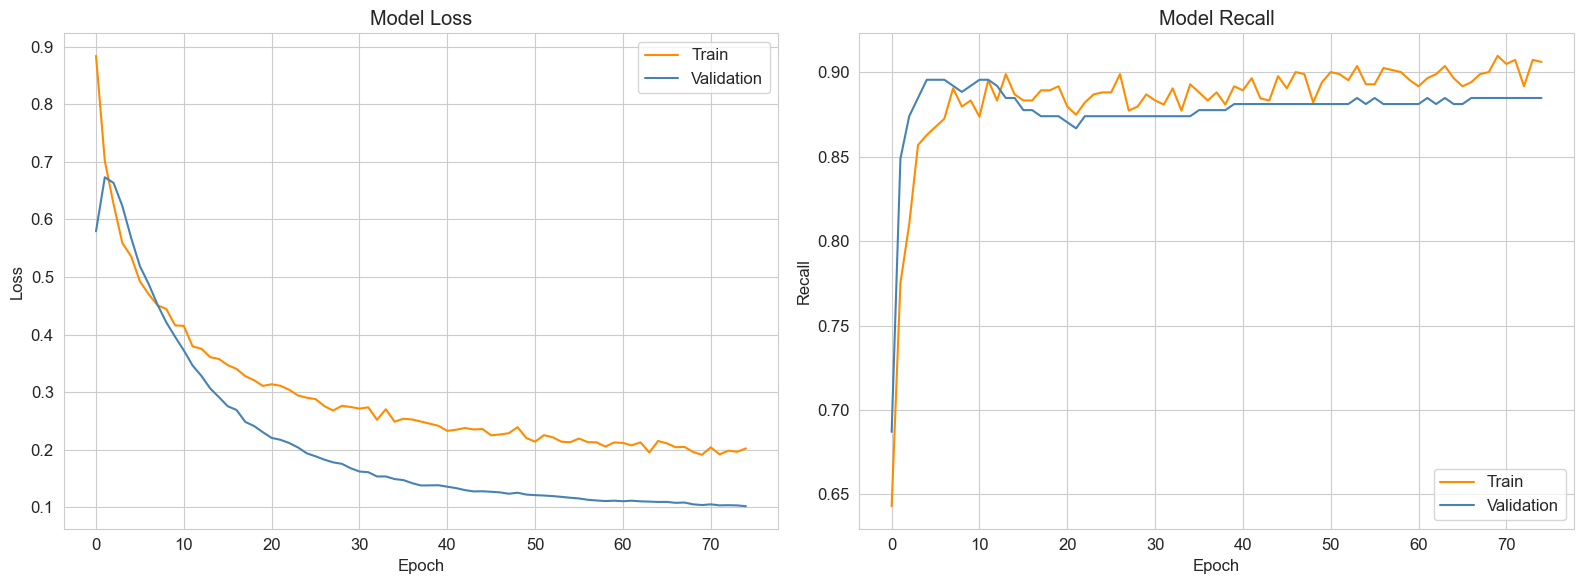

In [162]:
# Plot Loss and Recall for Model 9
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot(history_9, "loss")
plt.sca(ax2)
plot(history_9, "Recall")
plt.tight_layout()
plt.show()

#### Observation:
* Training and Validation loss continue to follow a downward trend. 
* Class Weight didn't introduced inestability in the loss plots. 
* Recall Scores are now above 90 in the validation. There seeems to be a better Recall. 
* There is no overfitting or a collapse. There is a boost in recall and it mantains generalization. 

In [163]:
# Evaluate the model on the train set for Model 9
model_9_train_perf = model_performance_classification(model_9, X_train, y_train)
model_9_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 621us/step


,Accuracy,Recall,Precision,F1 Score
0,0.9868,0.909856,0.860227,0.884346


In [164]:
# Evaluate the model on the validation set for Model 9
model_9_val_perf = model_performance_classification(model_9, X_val, y_val)
model_9_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 561us/step


,Accuracy,Recall,Precision,F1 Score
0,0.985,0.884892,0.851211,0.867725


In [165]:
# Classification Report for Train Data - Model 9
y_train_pred_9 = model_9.predict(X_train)
print("Classification Report - Train - Model 9",end="\n\n")
cr_train_model_9 = classification_report(y_train,y_train_pred_9>0.5)
print(cr_train_model_9)

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 515us/step
Classification Report - Train - Model 9

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     14168
         1.0       0.86      0.91      0.88       832

    accuracy                           0.99     15000
   macro avg       0.93      0.95      0.94     15000
weighted avg       0.99      0.99      0.99     15000



In [166]:
# Classification Report for Validation Data - Model 9
y_val_pred_9 = model_9.predict(X_val)
print("Classification Report - Validation - Model 9",end="\n\n")
cr_val_model_9 = classification_report(y_val,y_val_pred_9>0.5)
print(cr_val_model_9)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 565us/step
Classification Report - Validation - Model 9

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      4722
         1.0       0.85      0.88      0.87       278

    accuracy                           0.98      5000
   macro avg       0.92      0.94      0.93      5000
weighted avg       0.99      0.98      0.99      5000



469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 512us/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 560us/step


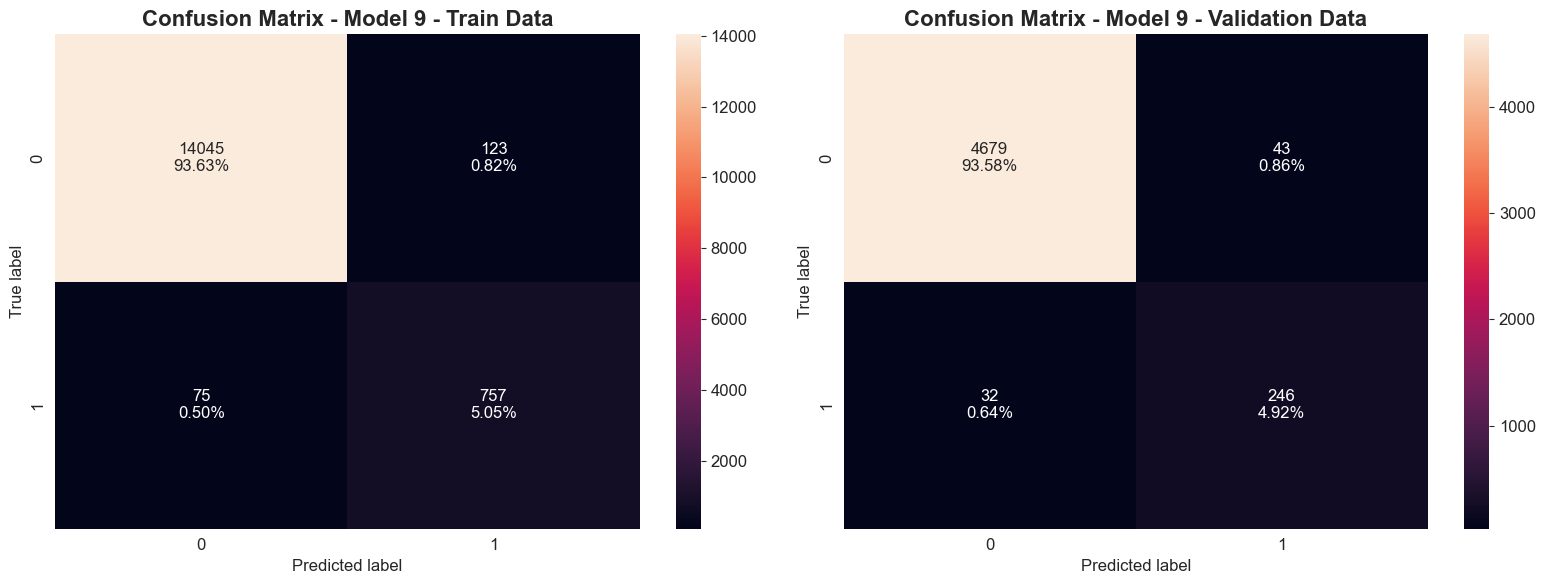

In [167]:
# Plot Confusion Matrices for Model 9
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot_confussion_matrix(model_9, X_train, y_train, "Confusion Matrix - Model 9 - Train Data")
plt.sca(ax2)
plot_confussion_matrix(model_9, X_val, y_val, "Confusion Matrix - Model 9 - Validation Data")
plt.tight_layout()
plt.show()

#### Observation:
* Model 9 has improved Recall Scores both in validation and training. 
* There is a clear reduction in False Negatives. There is a slight increase in False Positives. 
* The model is very good at predicting Real Failures.
* Next model will amplify the class weights and improve recall. 

## Model 10

Model 10 will amplify the weight in class 1 by times 2. In order to further penalize false negatives. Improving Recall Scores. 

In [168]:
# Clear any previous Keras session to avoid clutter
tf.keras.backend.clear_session()

In [169]:
# Amplify the weight of the minority class
class_weights[1] *= 2
print("Updated class weights:", class_weights)


Updated class weights: {0: 0.5293619424054207, 1: 18.028846153846153}


Class 0 keeps a weight of 0.5293 and Class 1 is amplified to 18.0288

In [170]:
# Model 10: Adding more complexity with additional layers, dropout, batch normalization, and He normal initialization
model_10 = Sequential()
model_10.add(Input(shape=(X_train.shape[1],)))
model_10.add(Dense(128, activation="relu", kernel_initializer="he_normal"))
model_10.add(BatchNormalization())
model_10.add(Dropout(0.4))
model_10.add(Dense(64, activation="relu", kernel_initializer="he_normal"))
model_10.add(Dense(32, activation="relu", kernel_initializer="he_normal"))
model_10.add(BatchNormalization())
model_10.add(Dropout(0.3))
model_10.add(Dense(1, activation="sigmoid"))

In [171]:
# Define the optimizer with Adam for Model 10
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
# Compile the model with the optimizer, loss function, and metrics for Model 10
model_10.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["Recall"])

In [172]:
# Fit the model for Model 10 with updated class weights
start = time.time()
history_10 = model_10.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weights
)
end = time.time()

Epoch 1/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.5224 - loss: 1.5294 - val_Recall: 0.7554 - val_loss: 0.6585
Epoch 2/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.7349 - loss: 0.9844 - val_Recall: 0.8813 - val_loss: 0.7047
Epoch 3/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8504 - loss: 0.8075 - val_Recall: 0.8993 - val_loss: 0.7122
Epoch 4/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8712 - loss: 0.7373 - val_Recall: 0.9137 - val_loss: 0.7016
Epoch 5/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8944 - loss: 0.7011 - val_Recall: 0.9137 - val_loss: 0.6794
Epoch 6/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8875 - loss: 0.6966 - val_Recall: 0.9137 - val_loss: 0.6609
Epoch 7/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.9231 - loss: 0.6286 - val_Recall: 0.9173 - val_loss: 0.6324
Epoch 8/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.9048 - loss: 0.6422 - val_Recall: 0.9173 - val_loss: 0.6162
Epoch 9/

In [173]:
print(f"Training time: {end - start:.2f} seconds")

Training time: 21.73 seconds


In [174]:
# Log the model 10
results = model_logger(results, hidden_layers=3, neurons=[128, 64, 32], activation_fn=["relu", "relu", "relu"],
                        epochs=epochs, batch_size=batch_size, optimizer="adam", learning_rate=[learning_rate, "-"], 
                        weight_init=["he", "he", "he"], regularization=["BatchNorm", "Dropout (0.4)", "BatchNorm","Dropout (0.3)"], 
                        history=history_10, elapsed_time=end - start, class_weight_strategy=class_weights)
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",class weight strategy,weight initializer,regularization,callbacks used,train loss,validation loss,train recall,validation recall,time (secs)
0,1,32,relu,75,128,SGD,"[0.001, -]",imbalanced,xavier,-,-,0.053337,0.067357,0.823317,0.809353,17.08
1,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.0001, 0.9]",imbalanced,"[xavier, xavier]",-,-,0.081540,0.086714,0.675481,0.694245,17.14
2,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.0001, 0.4]",imbalanced,"[xavier, xavier]",-,-,0.140907,0.141586,0.286058,0.327338,15.93
3,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.001, 0.9]",imbalanced,"[xavier, xavier]",-,-,0.041506,0.058346,0.861779,0.841727,16.13
4,2,"[64, 32]","[relu, relu]",75,128,adam,"[0.001, -]",imbalanced,"[xavier, xavier]",-,-,0.009103,0.106040,0.953125,0.852518,16.14
5,2,"[64, 32]","[relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[xavier, xavier]",-,-,0.033216,0.052694,0.897837,0.856115,16.55
6,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[xavier, xavier, xavier]","[Dropout (0.4), Dropout (0.3)]",-,0.046867,0.052945,0.867788,0.863309,19.54
7,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[xavier, xavier, xavier]","[BatchNorm, Dropout (0.4), BatchNorm, Dropout ...",-,0.050546,0.057770,0.824519,0.852518,22.75
8,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[he, he, he]","[BatchNorm, Dropout (0.4), BatchNorm, Dropout ...",-,0.057768,0.053996,0.796875,0.848921,22.68
9,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]","{0: 0.53, 1: 9.01}","[he, he, he]","[BatchNorm, Dropout (0.4), BatchNorm, Dropout ...",-,0.202344,0.101938,0.906250,0.884892,21.95


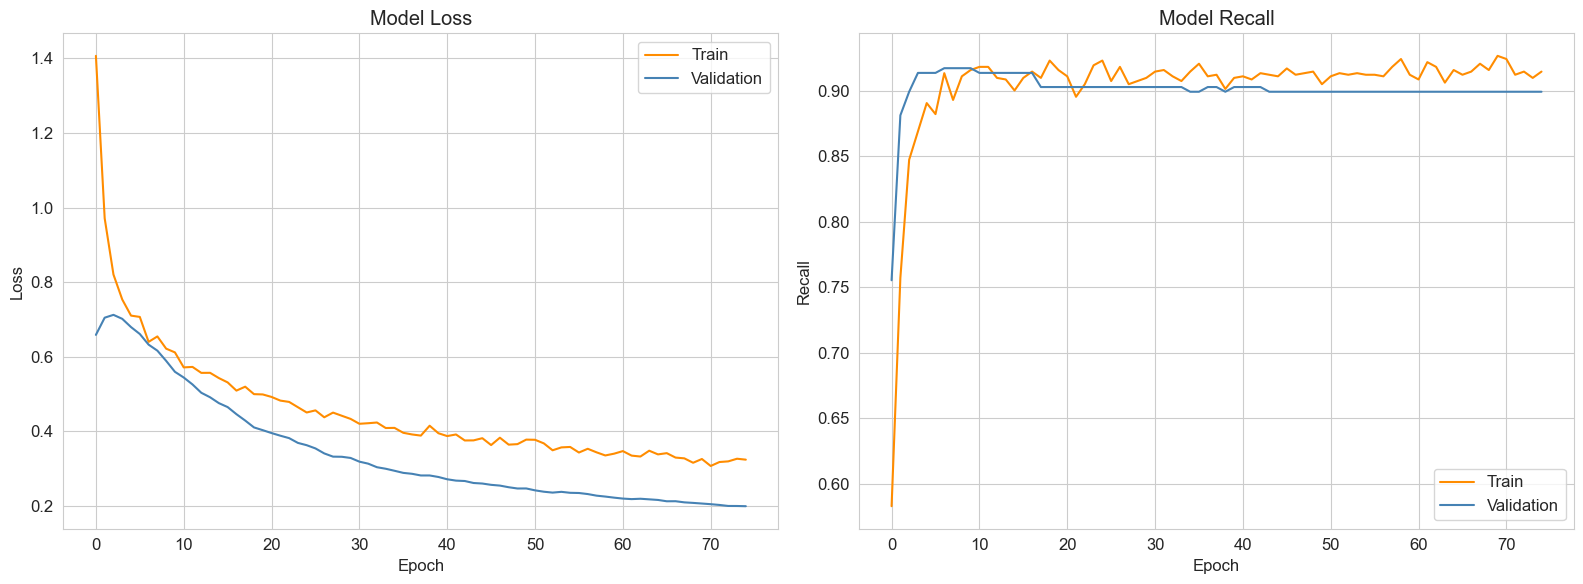

In [175]:
# Plot Loss and Recall for Model 10
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot(history_10, "loss")
plt.sca(ax2)
plot(history_10, "Recall")
plt.tight_layout()
plt.show()

#### Observation:
* Training and Validation loss continue to decline smoothly. Loss converges around 0.2 and 0.3 because of the effect of the penalty on False Negatives. 
* Train and validation loss have a divergence which might indicate a slight overfit. 
* There is no inestability in the loss plots. 
* For recall validation is above .90 and near 0.93 which is the highest recall seen from all the models. 

In [176]:
# Evaluate the model on the train set for Model 10
model_10_train_perf = model_performance_classification(model_10, X_train, y_train)
model_10_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 630us/step


,Accuracy,Recall,Precision,F1 Score
0,0.963667,0.921875,0.615076,0.737855


In [177]:
# Evaluate the model on the validation set for Model 10
model_10_val_perf = model_performance_classification(model_10, X_val, y_val)
model_10_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 555us/step


,Accuracy,Recall,Precision,F1 Score
0,0.9612,0.899281,0.600962,0.720461


In [178]:
# Classification Report for Train Data - Model 10
y_train_pred_10 = model_10.predict(X_train)
print("Classification Report - Train - Model 10",end="\n\n")
cr_train_model_10 = classification_report(y_train,y_train_pred_10>0.5)
print(cr_train_model_10)

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 510us/step
Classification Report - Train - Model 10

              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98     14168
         1.0       0.62      0.92      0.74       832

    accuracy                           0.96     15000
   macro avg       0.81      0.94      0.86     15000
weighted avg       0.97      0.96      0.97     15000



In [179]:
# Classification Report for Validation Data - Model 10
y_val_pred_10 = model_10.predict(X_val)
print("Classification Report - Validation - Model 10",end="\n\n")
cr_val_model_10 = classification_report(y_val,y_val_pred_10>0.5)
print(cr_val_model_10)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step
Classification Report - Validation - Model 10

              precision    recall  f1-score   support

         0.0       0.99      0.96      0.98      4722
         1.0       0.60      0.90      0.72       278

    accuracy                           0.96      5000
   macro avg       0.80      0.93      0.85      5000
weighted avg       0.97      0.96      0.96      5000



469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 510us/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 556us/step


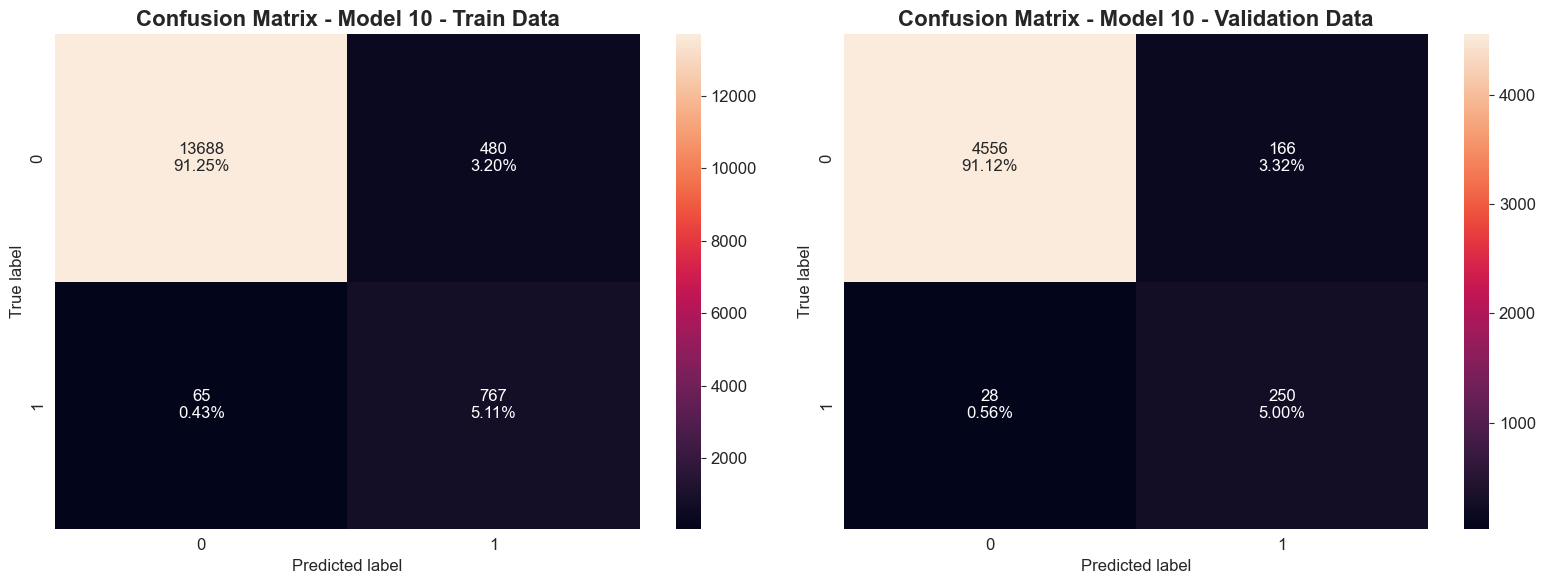

In [180]:
# Plot Confusion Matrices for Model 10
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot_confussion_matrix(model_10, X_train, y_train, "Confusion Matrix - Model 10 - Train Data")
plt.sca(ax2)
plot_confussion_matrix(model_10, X_val, y_val, "Confusion Matrix - Model 10 - Validation Data")
plt.tight_layout()
plt.show()

#### Observation:
* Model 10 has achieved the best recall in the validation set. 
* This model has reduced the number of False Negatives. It has increased the number of False Positives. 
* The amplified class weight will be kept as it help reducing false negatives. 
* Next model will introduce Early Stopping, halting training when there is no improvement. 

## Model 11

Model 11 introduces Early Stopping, as the amplified class weights introduced a slight overfit. Early Stopping will help prevent overfitting and reduce the computation time. 
The early stopping will have a patience of 10 epochs. 

In [181]:
# clear any previous Keras session to avoid clutter
tf.keras.backend.clear_session()

In [182]:
# Early Stopping Callback
early_stop = EarlyStopping(
    monitor="val_Recall",
    mode="max",
    patience=10,            
    restore_best_weights=True
)

In [183]:
# Model 11: Adding more complexity with additional layers, dropout, batch normalization, and He normal initialization
model_11 = Sequential()
model_11.add(Input(shape=(X_train.shape[1],)))
model_11.add(Dense(128, activation="relu", kernel_initializer="he_normal"))
model_11.add(BatchNormalization())
model_11.add(Dropout(0.4))
model_11.add(Dense(64, activation="relu", kernel_initializer="he_normal"))
model_11.add(Dense(32, activation="relu", kernel_initializer="he_normal"))
model_11.add(BatchNormalization())
model_11.add(Dropout(0.3))
model_11.add(Dense(1, activation="sigmoid"))

In [184]:
# Define the optimizer with Adam for Model 11
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
# Compile the model with the optimizer, loss function, and metrics for Model 11
model_11.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["Recall"])

In [185]:
# Fit the model for Model 11 with the amplified class weights and early stopping
start = time.time()
history_11 = model_11.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weights,
    callbacks=[early_stop]
)
end = time.time()

Epoch 1/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.6697 - loss: 1.1849 - val_Recall: 0.8165 - val_loss: 0.5552
Epoch 2/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.7992 - loss: 0.8217 - val_Recall: 0.8921 - val_loss: 0.6821
Epoch 3/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8645 - loss: 0.7494 - val_Recall: 0.9029 - val_loss: 0.7095
Epoch 4/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.9015 - loss: 0.6602 - val_Recall: 0.9101 - val_loss: 0.7046
Epoch 5/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.9072 - loss: 0.6657 - val_Recall: 0.9101 - val_loss: 0.6874
Epoch 6/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.9112 - loss: 0.6347 - val_Recall: 0.9137 - val_loss: 0.6650
Epoch 7/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.9202 - loss: 0.5942 - val_Recall: 0.9173 - val_loss: 0.6356
Epoch 8/75
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.9305 - loss: 0.5792 - val_Recall: 0.9209 - val_loss: 0.6171
Epoch 9/

In [186]:
print(f"Training time: {end - start:.2f} seconds")

Training time: 6.98 seconds


In [187]:
# Log the model 11
results = model_logger(results, hidden_layers=3, neurons=[128, 64, 32], activation_fn=["relu", "relu", "relu"],
                        epochs=epochs, batch_size=batch_size, optimizer="adam", learning_rate=[learning_rate, "-"], 
                        weight_init=["he", "he", "he"], regularization=["BatchNorm", "Dropout (0.4)", "BatchNorm","Dropout (0.3)"], 
                        history=history_11, elapsed_time=end - start, class_weight_strategy=class_weights, callbacks_used=["EarlyStopping"])
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",class weight strategy,weight initializer,regularization,callbacks used,train loss,validation loss,train recall,validation recall,time (secs)
0,1,32,relu,75,128,SGD,"[0.001, -]",imbalanced,xavier,-,-,0.053337,0.067357,0.823317,0.809353,17.08
1,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.0001, 0.9]",imbalanced,"[xavier, xavier]",-,-,0.081540,0.086714,0.675481,0.694245,17.14
2,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.0001, 0.4]",imbalanced,"[xavier, xavier]",-,-,0.140907,0.141586,0.286058,0.327338,15.93
3,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.001, 0.9]",imbalanced,"[xavier, xavier]",-,-,0.041506,0.058346,0.861779,0.841727,16.13
4,2,"[64, 32]","[relu, relu]",75,128,adam,"[0.001, -]",imbalanced,"[xavier, xavier]",-,-,0.009103,0.106040,0.953125,0.852518,16.14
5,2,"[64, 32]","[relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[xavier, xavier]",-,-,0.033216,0.052694,0.897837,0.856115,16.55
6,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[xavier, xavier, xavier]","[Dropout (0.4), Dropout (0.3)]",-,0.046867,0.052945,0.867788,0.863309,19.54
7,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[xavier, xavier, xavier]","[BatchNorm, Dropout (0.4), BatchNorm, Dropout ...",-,0.050546,0.057770,0.824519,0.852518,22.75
8,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[he, he, he]","[BatchNorm, Dropout (0.4), BatchNorm, Dropout ...",-,0.057768,0.053996,0.796875,0.848921,22.68
9,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]","{0: 0.53, 1: 9.01}","[he, he, he]","[BatchNorm, Dropout (0.4), BatchNorm, Dropout ...",-,0.202344,0.101938,0.906250,0.884892,21.95


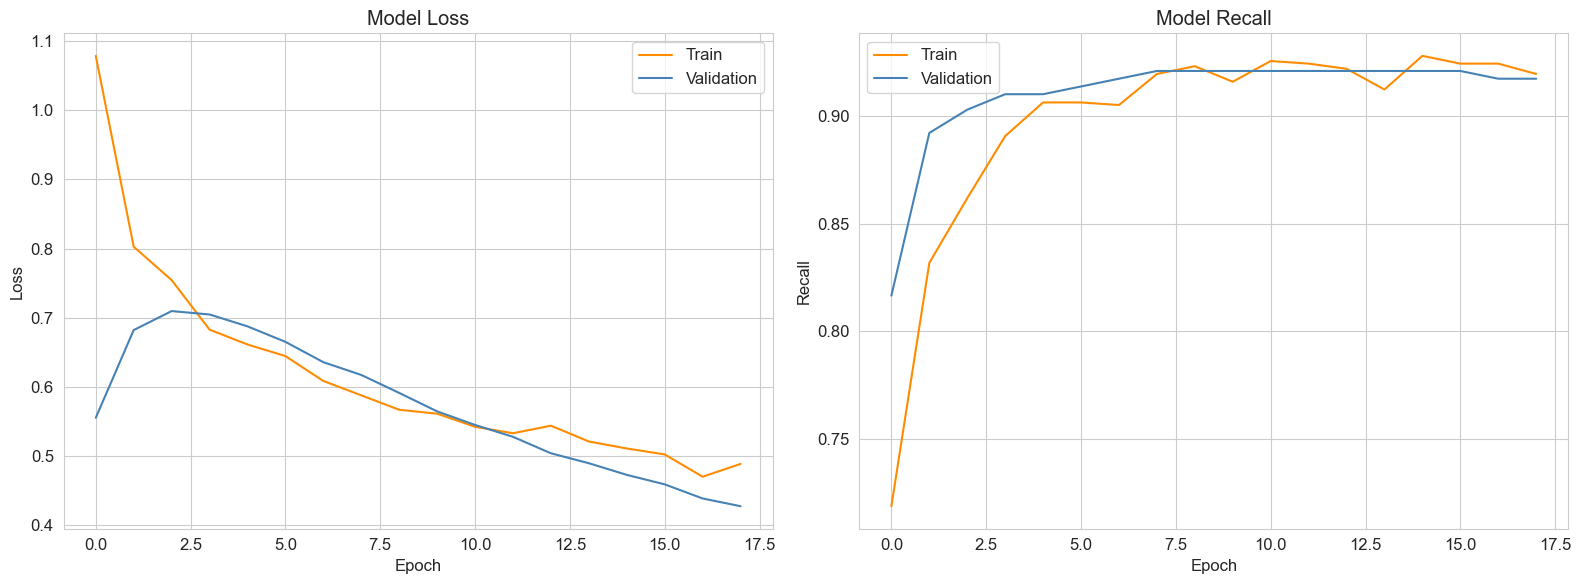

In [188]:
# Plot Loss and Recall for Model 11
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot(history_11, "loss")
plt.sca(ax2)
plot(history_11, "Recall")
plt.tight_layout()
plt.show()

#### Observation:
* Training and validation keep their descend. 
* Training halts at epoch 17. 
* There is early convergance right before overfitting. 
* Recall scores for validation climb above 0.91 

In [189]:
# Evaluate the model on the train set for Model 11
model_11_train_perf = model_performance_classification(model_11, X_train, y_train)
model_11_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 648us/step


,Accuracy,Recall,Precision,F1 Score
0,0.7132,0.93149,0.154382,0.264867


In [190]:
# Evaluate the model on the validation set for Model 11
model_11_val_perf = model_performance_classification(model_11, X_val, y_val)
model_11_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step


,Accuracy,Recall,Precision,F1 Score
0,0.7076,0.920863,0.150943,0.259372


In [191]:
# Classification Report for Train Data - Model 11
y_train_pred_11 = model_11.predict(X_train)
print("Classification Report - Train - Model 11",end="\n\n")
cr_train_model_11 = classification_report(y_train,y_train_pred_11>0.5)
print(cr_train_model_11)

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 509us/step
Classification Report - Train - Model 11

              precision    recall  f1-score   support

         0.0       0.99      0.70      0.82     14168
         1.0       0.15      0.93      0.26       832

    accuracy                           0.71     15000
   macro avg       0.57      0.82      0.54     15000
weighted avg       0.95      0.71      0.79     15000



In [192]:
# Classification Report for Validation Data - Model 11
y_val_pred_11 = model_11.predict(X_val)
print("Classification Report - Validation - Model 11",end="\n\n")
cr_val_model_11 = classification_report(y_val,y_val_pred_11>0.5)
print(cr_val_model_11)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 573us/step
Classification Report - Validation - Model 11

              precision    recall  f1-score   support

         0.0       0.99      0.70      0.82      4722
         1.0       0.15      0.92      0.26       278

    accuracy                           0.71      5000
   macro avg       0.57      0.81      0.54      5000
weighted avg       0.95      0.71      0.79      5000



469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 556us/step


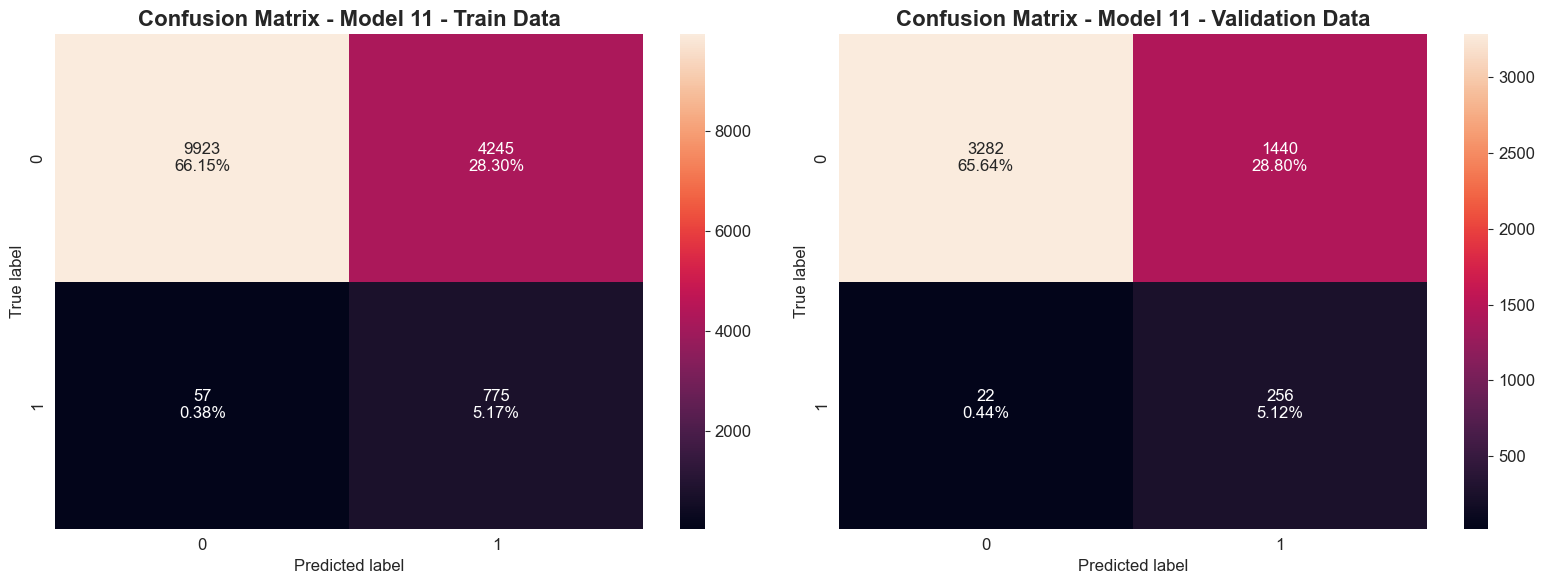

In [193]:
# Plot Confusion Matrices for Model 11
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot_confussion_matrix(model_11, X_train, y_train, "Confusion Matrix - Model 11 - Train Data")
plt.sca(ax2)
plot_confussion_matrix(model_11, X_val, y_val, "Confusion Matrix - Model 11 - Validation Data")
plt.tight_layout()
plt.show()

#### Observation:
* Model 11 is the model with the best recall score. 
* This is the best model with a reduce False Negatives only 0.44% of False Negatives
* There is a significant increase in False Positives with 28.80% of False Positives. 

## Model 12

This model will use a lower batch size of 64 and 200 epochs. Using the same architecture, callbacks, weight classes as Model 11.
As the model has Early Callback the moment the model converges it will halt. Might not need to get to the 200 epochs. A reduced batch size will lead to more frequent weight updates per epoch.   

In [194]:
# Clear any previous Keras session to avoid clutter
tf.keras.backend.clear_session()

In [195]:
# Set the number of epochs and batch size for training
epochs = 200
batch_size = 64

In [196]:
# Model 12: Adding more complexity with additional layers, dropout, batch normalization, and He normal initialization
model_12 = Sequential()
model_12.add(Input(shape=(X_train.shape[1],)))
model_12.add(Dense(128, activation="relu", kernel_initializer="he_normal"))
model_12.add(BatchNormalization())
model_12.add(Dropout(0.4))
model_12.add(Dense(64, activation="relu", kernel_initializer="he_normal"))
model_12.add(Dense(32, activation="relu", kernel_initializer="he_normal"))
model_12.add(BatchNormalization())
model_12.add(Dropout(0.3))
model_12.add(Dense(1, activation="sigmoid"))

In [197]:
# Model summary
model_12.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,257 (63.50 KB)

 Trainable params: 15,937 (62.25 KB)

 Non-trainable params: 320 (1.25 KB)

In [198]:
# Define the optimizer with Adam for Model 12
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
# Compile the model with the optimizer, loss function, and metrics for Model 12
model_12.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["Recall"])

In [199]:
# Fit the model for Model 12 with the amplified class weights and early stopping
start = time.time()
history_12 = model_12.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weights,
    callbacks=[early_stop]
)
end = time.time()

Epoch 1/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - Recall: 0.5775 - loss: 1.2966 - val_Recall: 0.8525 - val_loss: 0.6981
Epoch 2/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8006 - loss: 0.8519 - val_Recall: 0.8849 - val_loss: 0.6657
Epoch 3/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8844 - loss: 0.7434 - val_Recall: 0.8957 - val_loss: 0.6485
Epoch 4/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.9212 - loss: 0.6683 - val_Recall: 0.9101 - val_loss: 0.6128
Epoch 5/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.9009 - loss: 0.6356 - val_Recall: 0.9101 - val_loss: 0.5891
Epoch 6/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.9167 - loss: 0.6026 - val_Recall: 0.9101 - val_loss: 0.5598
Epoch 7/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.9140 - loss: 0.5924 - val_Recall: 0.9065 - val_loss: 0.5227
Epoch 8/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.9175 - loss: 0.5560 - val_Recall: 0.9065 - val_loss: 0.4930


In [200]:
print(f"Training time: {end - start:.2f} seconds")

Training time: 8.11 seconds


In [201]:
# Log the model 12
results = model_logger(results, hidden_layers=3, neurons=[128, 64, 32], activation_fn=["relu", "relu", "relu"],
                        epochs=epochs, batch_size=batch_size, optimizer="adam", learning_rate=[learning_rate, "-"], 
                        weight_init=["he", "he", "he"], regularization=["BatchNorm", "Dropout (0.4)", "BatchNorm","Dropout (0.3)"], 
                        history=history_12, elapsed_time=end - start, class_weight_strategy=class_weights, callbacks_used=["EarlyStopping"])
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",class weight strategy,weight initializer,regularization,callbacks used,train loss,validation loss,train recall,validation recall,time (secs)
0,1,32,relu,75,128,SGD,"[0.001, -]",imbalanced,xavier,-,-,0.053337,0.067357,0.823317,0.809353,17.08
1,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.0001, 0.9]",imbalanced,"[xavier, xavier]",-,-,0.081540,0.086714,0.675481,0.694245,17.14
2,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.0001, 0.4]",imbalanced,"[xavier, xavier]",-,-,0.140907,0.141586,0.286058,0.327338,15.93
3,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.001, 0.9]",imbalanced,"[xavier, xavier]",-,-,0.041506,0.058346,0.861779,0.841727,16.13
4,2,"[64, 32]","[relu, relu]",75,128,adam,"[0.001, -]",imbalanced,"[xavier, xavier]",-,-,0.009103,0.106040,0.953125,0.852518,16.14
5,2,"[64, 32]","[relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[xavier, xavier]",-,-,0.033216,0.052694,0.897837,0.856115,16.55
6,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[xavier, xavier, xavier]","[Dropout (0.4), Dropout (0.3)]",-,0.046867,0.052945,0.867788,0.863309,19.54
7,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[xavier, xavier, xavier]","[BatchNorm, Dropout (0.4), BatchNorm, Dropout ...",-,0.050546,0.057770,0.824519,0.852518,22.75
8,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[he, he, he]","[BatchNorm, Dropout (0.4), BatchNorm, Dropout ...",-,0.057768,0.053996,0.796875,0.848921,22.68
9,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]","{0: 0.53, 1: 9.01}","[he, he, he]","[BatchNorm, Dropout (0.4), BatchNorm, Dropout ...",-,0.202344,0.101938,0.906250,0.884892,21.95


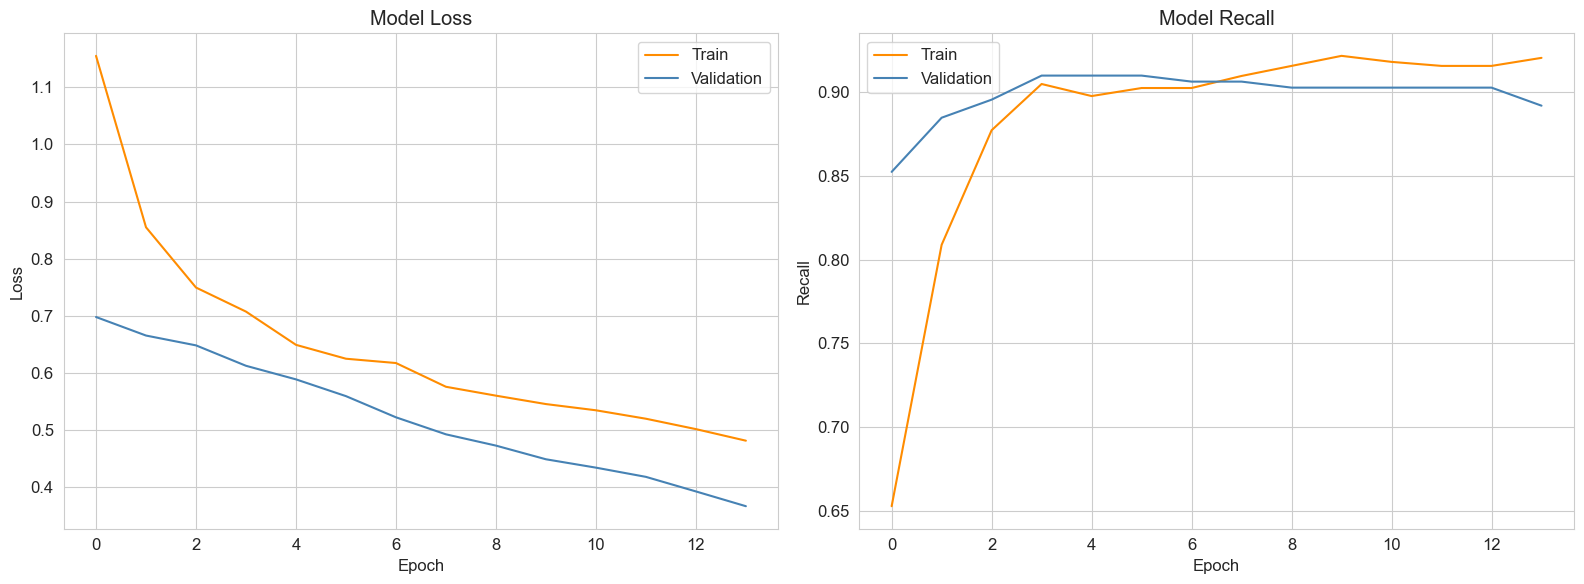

In [202]:
# Plot Loss and Recall for Model 12
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot(history_12, "loss")
plt.sca(ax2)
plot(history_12, "Recall")
plt.tight_layout()
plt.show()

#### Observation:
* Loss plots are very similar to model 11.
* Recall didn't improve, scores are lower than model 11. 

In [203]:
# Evaluate the model on the train set for Model 12
model_12_train_perf = model_performance_classification(model_12, X_train, y_train, threshold=0.5, average="binary")
model_12_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 630us/step


,Accuracy,Recall,Precision,F1 Score
0,0.736067,0.919471,0.164269,0.278739


In [204]:
# Evaluate the model on the validation set for Model 12
model_12_val_perf = model_performance_classification(model_12, X_val, y_val, threshold=0.5, average="binary")
model_12_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step


,Accuracy,Recall,Precision,F1 Score
0,0.7342,0.910072,0.162492,0.275749


In [205]:
# Classification Report for Train Data - Model 12
y_train_pred_12 = model_12.predict(X_train)
print("Classification Report - Train - Model 12",end="\n\n")
cr_train_model_12 = classification_report(y_train, y_train_pred_12 > 0.5)
print(cr_train_model_12)

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step
Classification Report - Train - Model 12

              precision    recall  f1-score   support

         0.0       0.99      0.73      0.84     14168
         1.0       0.16      0.92      0.28       832

    accuracy                           0.74     15000
   macro avg       0.58      0.82      0.56     15000
weighted avg       0.95      0.74      0.81     15000



In [206]:
# Classification Report for Validation Data - Model 12
y_val_pred_12 = model_12.predict(X_val)
print("Classification Report - Validation - Model 12",end="\n\n")
cr_val_model_12 = classification_report(y_val, y_val_pred_12 > 0.5)
print(cr_val_model_12)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step
Classification Report - Validation - Model 12

              precision    recall  f1-score   support

         0.0       0.99      0.72      0.84      4722
         1.0       0.16      0.91      0.28       278

    accuracy                           0.73      5000
   macro avg       0.58      0.82      0.56      5000
weighted avg       0.95      0.73      0.81      5000



469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 518us/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 562us/step


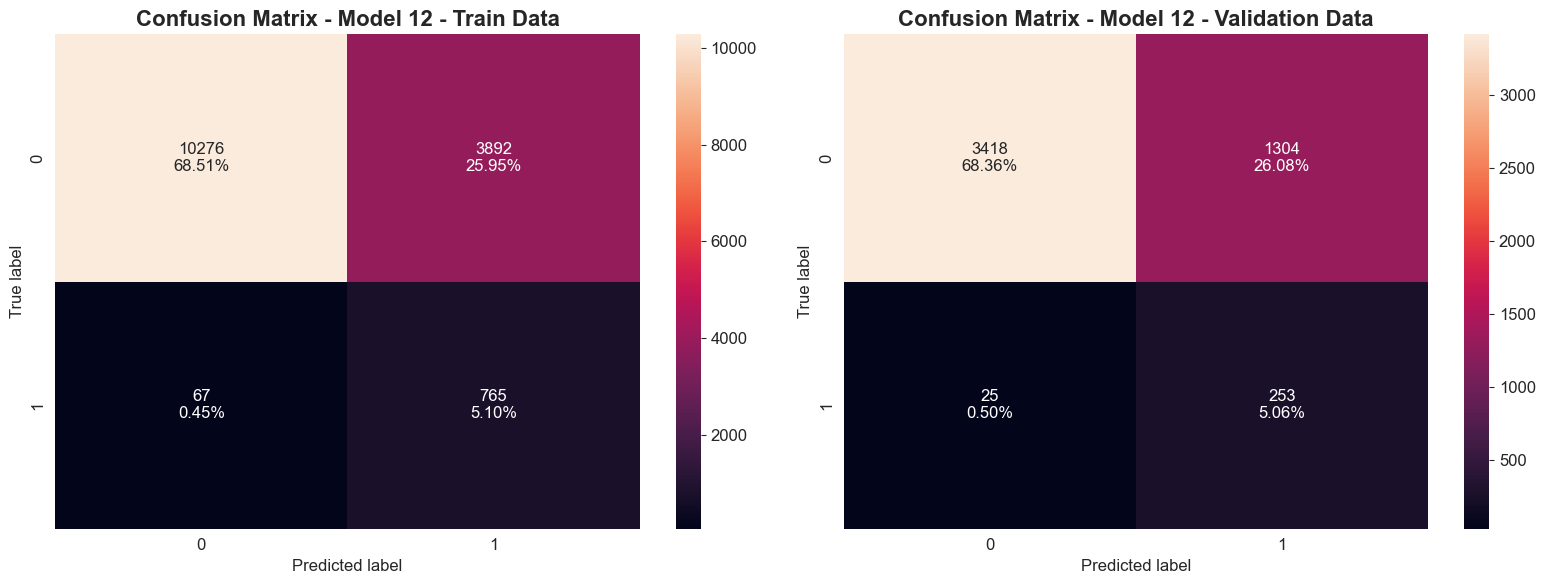

In [207]:
# Plot Confusion Matrices for Model 12
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot_confussion_matrix(model_12, X_train, y_train, "Confusion Matrix - Model 12 - Train Data")
plt.sca(ax2)
plot_confussion_matrix(model_12, X_val, y_val, "Confusion Matrix - Model 12 - Validation Data")
plt.tight_layout()
plt.show()

#### Observation:
There is no improvement in this model. So the change in batch size and epoch is not helping. 

# **Model Performance Comparison and Final Model Selection**

Now, in order to select the final model, we will compare the performances of all the models for the training and validation sets.

Print the model logger to remember each model.

In [208]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",class weight strategy,weight initializer,regularization,callbacks used,train loss,validation loss,train recall,validation recall,time (secs)
0,1,32,relu,75,128,SGD,"[0.001, -]",imbalanced,xavier,-,-,0.053337,0.067357,0.823317,0.809353,17.08
1,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.0001, 0.9]",imbalanced,"[xavier, xavier]",-,-,0.081540,0.086714,0.675481,0.694245,17.14
2,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.0001, 0.4]",imbalanced,"[xavier, xavier]",-,-,0.140907,0.141586,0.286058,0.327338,15.93
3,2,"[64, 32]","[relu, relu]",75,128,SGD,"[0.001, 0.9]",imbalanced,"[xavier, xavier]",-,-,0.041506,0.058346,0.861779,0.841727,16.13
4,2,"[64, 32]","[relu, relu]",75,128,adam,"[0.001, -]",imbalanced,"[xavier, xavier]",-,-,0.009103,0.106040,0.953125,0.852518,16.14
5,2,"[64, 32]","[relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[xavier, xavier]",-,-,0.033216,0.052694,0.897837,0.856115,16.55
6,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[xavier, xavier, xavier]","[Dropout (0.4), Dropout (0.3)]",-,0.046867,0.052945,0.867788,0.863309,19.54
7,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[xavier, xavier, xavier]","[BatchNorm, Dropout (0.4), BatchNorm, Dropout ...",-,0.050546,0.057770,0.824519,0.852518,22.75
8,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]",imbalanced,"[he, he, he]","[BatchNorm, Dropout (0.4), BatchNorm, Dropout ...",-,0.057768,0.053996,0.796875,0.848921,22.68
9,3,"[128, 64, 32]","[relu, relu, relu]",75,128,adam,"[0.0001, -]","{0: 0.53, 1: 9.01}","[he, he, he]","[BatchNorm, Dropout (0.4), BatchNorm, Dropout ...",-,0.202344,0.101938,0.906250,0.884892,21.95


In [209]:
model_train_comparison = pd.concat([
    model_train_perf.T,
    model_1_train_perf.T,
    model_2_train_perf.T,
    model_3_train_perf.T,
    model_4_train_perf.T,
    model_5_train_perf.T,
    model_6_train_perf.T,
    model_7_train_perf.T,
    model_8_train_perf.T,
    model_9_train_perf.T,
    model_10_train_perf.T,
    model_11_train_perf.T,
    model_12_train_perf.T
], axis=1)
model_train_comparison.columns = [
    "Baseline",
    "Model 1",
    "Model 2",
    "Model 3",
    "Model 4",
    "Model 5",
    "Model 6",
    "Model 7",
    "Model 8",
    "Model 9",
    "Model 10",
    "Model 11",
    "Model 12"
]

model_train_comparison

,Baseline,Model 1,Model 2,Model 3,Model 4,Model 5,Model 6,Model 7,Model 8,Model 9,Model 10,Model 11,Model 12
Accuracy,0.989133,0.980267,0.958333,0.991600,0.995267,0.994000,0.993533,0.992267,0.991800,0.986800,0.963667,0.713200,0.736067
Recall,0.825721,0.676683,0.287260,0.862981,0.914663,0.900240,0.890625,0.867788,0.861779,0.909856,0.921875,0.931490,0.919471
Precision,0.974468,0.954237,0.881919,0.983562,1.000000,0.990741,0.991968,0.991758,0.988966,0.860227,0.615076,0.154382,0.164269
F1 Score,0.893949,0.791842,0.433364,0.919334,0.955430,0.943325,0.938569,0.925641,0.921002,0.884346,0.737855,0.264867,0.278739


Model 11 is the model with the highest Recall Score, followed by Model 10. 

In [210]:
model_val_comparison = pd.concat([
    model_val_perf.T,
    model_1_val_perf.T,
    model_2_val_perf.T,
    model_3_val_perf.T,
    model_4_val_perf.T,
    model_5_val_perf.T,
    model_6_val_perf.T,
    model_7_val_perf.T,
    model_8_val_perf.T,
    model_9_val_perf.T,
    model_10_val_perf.T,
    model_11_val_perf.T,
    model_12_val_perf.T
], axis=1)
model_val_comparison.columns = [
    "Baseline",
    "Model 1",
    "Model 2",
    "Model 3",
    "Model 4",
    "Model 5",
    "Model 6",
    "Model 7",
    "Model 8",
    "Model 9",
    "Model 10",
    "Model 11",
    "Model 12"
]

model_val_comparison

,Baseline,Model 1,Model 2,Model 3,Model 4,Model 5,Model 6,Model 7,Model 8,Model 9,Model 10,Model 11,Model 12
Accuracy,0.988400,0.981400,0.960000,0.990400,0.990600,0.990800,0.991400,0.990600,0.991000,0.985000,0.961200,0.707600,0.734200
Recall,0.809353,0.694245,0.327338,0.841727,0.852518,0.856115,0.863309,0.852518,0.848921,0.884892,0.899281,0.920863,0.910072
Precision,0.978261,0.960199,0.875000,0.983193,0.975309,0.975410,0.979592,0.975309,0.987448,0.851211,0.600962,0.150943,0.162492
F1 Score,0.885827,0.805846,0.476440,0.906977,0.909789,0.911877,0.917782,0.909789,0.912959,0.867725,0.720461,0.259372,0.275749


Model 11 is the model with better Recall, followed by Model 12 and Model 10. 

### Model Selection
---
Model 11 is the best choice for achieving ReneWind's objective to minimize costly false negatives and maximizing recall. Best recall with a score of 0.92
Model 9 has a better balance (precision and recall). It has a good recall score of 0.88 and precision of 0.85

As the objective is to minimize Flase Negatives model 11 is the best model for this task. 


Now here is the performance for model 11 best recall and model 9 best balance. 

In [211]:
# Evaluate model 9 on the test set
model_9_test_perf = model_performance_classification(model_9, X_test, y_test, threshold=0.5, average="binary")
model_9_test_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 727us/step


,Accuracy,Recall,Precision,F1 Score
0,0.9826,0.861702,0.835052,0.848168


In [212]:
# Evaluate the best model on the test set
model_11_test_perf = model_performance_classification(model_11, X_test, y_test, threshold=0.5, average="binary")
model_11_test_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 761us/step


,Accuracy,Recall,Precision,F1 Score
0,0.7142,0.904255,0.153893,0.263022


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 562us/step


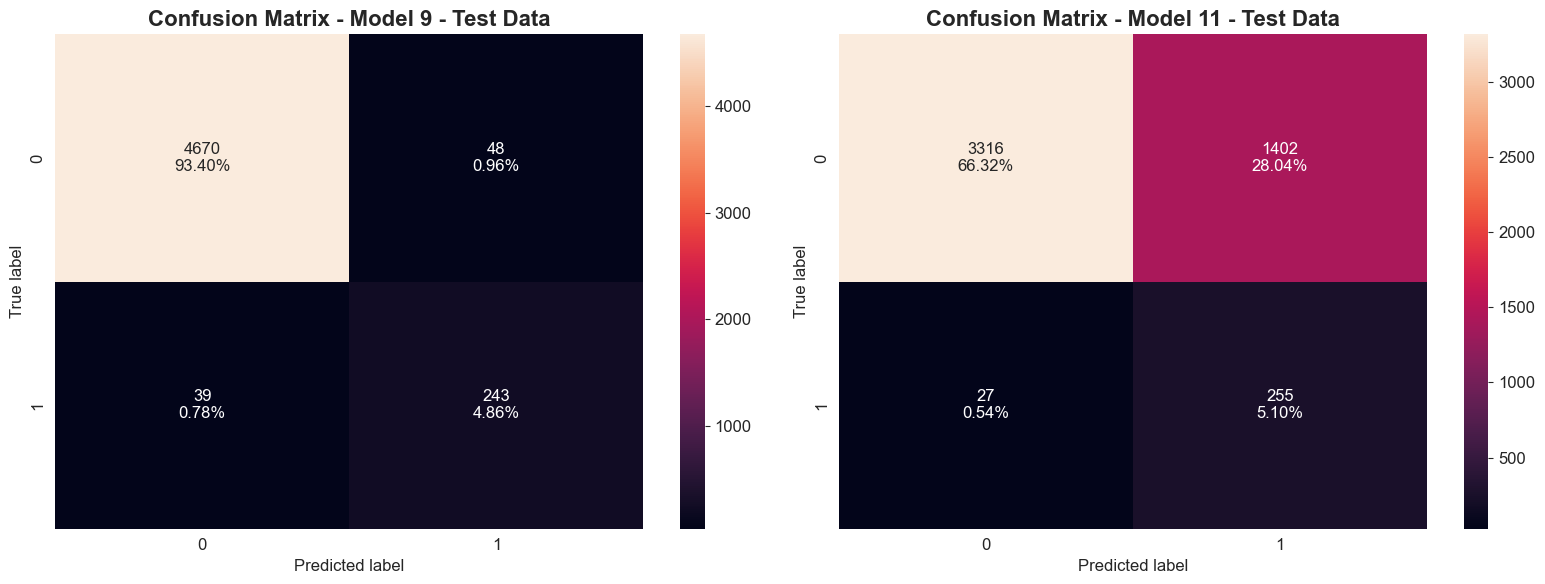

In [213]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot_confussion_matrix(model_9, X_test, y_test, "Confusion Matrix - Model 9 - Test Data")
plt.sca(ax2)
plot_confussion_matrix(model_11, X_test, y_test, "Confusion Matrix - Model 11 - Test Data")
plt.tight_layout()
plt.show()

#### Observation:
- Model 11 performs very good on the test set.
- It has a very low number of False Negatives 0.54%
- The number of Flase Positives is high 28.04%

# **Actionable Insights and Recommendations**

**The final model (Model 11)** demonstrates a high predictive performance for detecting failures:
* **Recall ≈ 0.92:** Captures 92% of failure events, significantly reducing the likelihood of catastrophic, unplanned turbine downtime.
* EarlyStopping guarantees training efficiency and model robustness.
* Deep, regularized architecture ensures the model generalizes well without memorizing noise.

This model reflects ReneWind’s operational constraints, where false negatives (missed failures) are far more costly than false positives (unnecessary inspections):
* Reduces replacement events, which are substantially more expensive than repairs.
* Enables preventive maintenance scheduling, improving uptime and worker safety.

The final model stands out: 
* Achieves the highest validated recall among all candidates without compromising generalization.
* Avoids overfitting through early exit at optimal epoch (17), saving compute and improving model reproducibility.

If inspection costs are high:
* **Model 9 offers a more balanced trade-off.** It successfully identifies approximately 86% of failure events while minimizing false alarms, resulting in fewer unnecessary inspections and improved operational efficiency.